# Generator: Rain-Attenuation

In [9]:
# imports:
import numpy as np, matplotlib.pyplot as plt
from dataclasses import dataclass
from enum import Enum
from typing import Callable, Optional, Tuple, List, Dict
from sklearn.model_selection import train_test_split


In [3]:
# @title ITU-R Tables
# ITU-R P.838-3 – Table 5 (k, α) coefficients           (March 2005 version)
# https://www.itu.int/dms_pubrec/itu-r/rec/p/r-rec-p.838-3-200503-i!!pdf-e.pdf
# Units:  frequency in GHz, k [dB km-1 (mm h-1)-α],  α dimensionless

ITU_P838_TABLE = {
    "horizontal": {
         1:  (2.59e-5, 0.9691),  1.5: (4.43e-5, 1.0185),  2:  (8.47e-5, 1.0664),
       2.5:  (1.321e-4, 1.1209),  3:  (1.390e-4, 1.2322),  3.5:(1.155e-4, 1.4189),
         4:  (1.071e-4, 1.6009),  4.5: (1.340e-4, 1.6948),  5:  (2.162e-4, 1.6969),
       5.5:  (3.909e-4, 1.6499),  6:  (7.056e-4, 1.5900),  7:  (1.915e-3, 1.4810),
         8:  (4.115e-3, 1.3905),  9:  (7.535e-3, 1.3155), 10: (1.217e-2, 1.2571),
        11:  (1.772e-2, 1.2140), 12: (2.386e-2, 1.1825), 13: (3.041e-2, 1.1586),
        14:  (3.738e-2, 1.1396), 15: (4.481e-2, 1.1233), 16: (5.282e-2, 1.1086),
        17:  (6.146e-2, 1.0949), 18: (7.078e-2, 1.0818), 19: (8.084e-2, 1.0691),
        20:  (9.164e-2, 1.0568), 21: (1.032e-1, 1.0447), 22: (1.155e-1, 1.0329),
        23:  (1.286e-1, 1.0214), 24: (1.425e-1, 1.0101), 25: (1.571e-1, 0.9991),
        26:  (1.724e-1, 0.9884), 27: (1.884e-1, 0.9780), 28: (2.051e-1, 0.9679),
        29:  (2.224e-1, 0.9580), 30: (2.403e-1, 0.9485), 31: (2.588e-1, 0.9392),
        32:  (2.778e-1, 0.9302), 33: (2.972e-1, 0.9214), 34: (3.171e-1, 0.9129),
        35:  (3.374e-1, 0.9047), 36: (3.580e-1, 0.8967), 37: (3.789e-1, 0.8890),
        38:  (4.001e-1, 0.8816), 39: (4.215e-1, 0.8743), 40: (4.431e-1, 0.8673),
        41:  (4.647e-1, 0.8605), 42: (4.865e-1, 0.8539), 43: (5.084e-1, 0.8476),
        44:  (5.302e-1, 0.8414), 45: (5.521e-1, 0.8355), 46: (5.738e-1, 0.8297),
        47:  (5.956e-1, 0.8241), 48: (6.172e-1, 0.8187), 49: (6.386e-1, 0.8134),
        50:  (6.600e-1, 0.8084), 51: (6.811e-1, 0.8034), 52: (7.020e-1, 0.7987),
        53:  (7.228e-1, 0.7941), 54: (7.433e-1, 0.7896), 55: (7.635e-1, 0.7853),
        56:  (7.835e-1, 0.7811), 57: (8.032e-1, 0.7771), 58: (8.226e-1, 0.7731),
        59:  (8.418e-1, 0.7693), 60: (8.606e-1, 0.7656), 61: (8.791e-1, 0.7621),
        62:  (8.974e-1, 0.7586), 63: (9.153e-1, 0.7552), 64: (9.328e-1, 0.7520),
        65:  (9.501e-1, 0.7488), 66: (9.670e-1, 0.7458), 67: (9.836e-1, 0.7428),
        68:  (9.999e-1, 0.7400), 69: (1.0159, 0.7372), 70: (1.0315, 0.7345),
        71: (1.0468, 0.7318), 72: (1.0618, 0.7293), 73: (1.0764, 0.7268),
        74: (1.0908, 0.7244), 75: (1.1048, 0.7221), 76: (1.1185, 0.7199),
        77: (1.1320, 0.7177), 78: (1.1451, 0.7156), 79: (1.1579, 0.7135),
        80: (1.1704, 0.7115), 81: (1.1827, 0.7096), 82: (1.1946, 0.7077),
        83: (1.2063, 0.7058), 84: (1.2177, 0.7040), 85: (1.2289, 0.7023),
        86: (1.2398, 0.7006), 87: (1.2504, 0.6990), 88: (1.2607, 0.6974),
        89: (1.2708, 0.6959), 90: (1.2807, 0.6944), 91: (1.2903, 0.6929),
        92: (1.2997, 0.6915), 93: (1.3089, 0.6901), 94: (1.3179, 0.6888),
        95: (1.3266, 0.6875), 96: (1.3351, 0.6862), 97: (1.3434, 0.6850),
        98: (1.3515, 0.6838), 99: (1.3594, 0.6826), 100:(1.3671, 0.6815),
       120:(1.4866, 0.6640), 150:(1.5823, 0.6494), 200:(1.6378, 0.6382),
       300:(1.6286, 0.6296), 400:(1.5860, 0.6262), 500:(1.5418, 0.6253),
       600:(1.5013, 0.6262), 700:(1.4654, 0.6284), 800:(1.4335, 0.6315),
       900:(1.4050, 0.6353), 1000:(1.3795, 0.6396)
    },
    "vertical": {
         1:  (3.08e-5, 0.8592),  1.5: (5.74e-5, 0.8957),  2:  (9.98e-5, 0.9490),
       2.5:  (1.464e-4, 1.0085),  3:  (1.942e-4, 1.0688),  3.5:(2.346e-4, 1.1387),
         4:  (2.461e-4, 1.2476),  4.5: (2.347e-4, 1.3987),  5:  (2.428e-4, 1.5317),
       5.5:  (3.115e-4, 1.5882),  6:  (4.878e-4, 1.5728),  7:  (1.425e-3, 1.4745),
         8:  (3.450e-3, 1.3797),  9:  (6.691e-3, 1.2895), 10: (1.129e-2, 1.2157),
        11:  (1.731e-2, 1.1617), 12: (2.455e-2, 1.1216), 13: (3.266e-2, 1.0901),
        14:  (4.126e-2, 1.0646), 15: (5.008e-2, 1.0440), 16: (5.899e-2, 1.0273),
        17:  (6.797e-2, 1.0137), 18: (7.708e-2, 1.0025), 19: (8.642e-2, 0.9930),
        20:  (9.611e-2, 0.9847), 21: (1.063e-1, 0.9771), 22: (1.170e-1, 0.9700),
        23:  (1.284e-1, 0.9630), 24: (1.404e-1, 0.9561), 25: (1.533e-1, 0.9491),
        26:  (1.669e-1, 0.9421), 27: (1.813e-1, 0.9349), 28: (1.964e-1, 0.9277),
        29:  (2.124e-1, 0.9203), 30: (2.291e-1, 0.9129), 31: (2.465e-1, 0.9055),
        32:  (2.646e-1, 0.8981), 33: (2.833e-1, 0.8907), 34: (3.026e-1, 0.8834),
        35:  (3.224e-1, 0.8761), 36: (3.427e-1, 0.8690), 37: (3.633e-1, 0.8621),
        38:  (3.844e-1, 0.8552), 39: (4.058e-1, 0.8486), 40: (4.274e-1, 0.8421),
        41:  (4.492e-1, 0.8357), 42: (4.712e-1, 0.8296), 43: (4.932e-1, 0.8236),
        44:  (5.153e-1, 0.8179), 45: (5.375e-1, 0.8123), 46: (5.596e-1, 0.8069),
        47:  (5.817e-1, 0.8017), 48: (6.037e-1, 0.7967), 49: (6.255e-1, 0.7918),
        50:  (6.472e-1, 0.7871), 51: (6.687e-1, 0.7826), 52: (6.901e-1, 0.7783),
        53:  (7.112e-1, 0.7741), 54: (7.321e-1, 0.7700), 55: (7.527e-1, 0.7661),
        56:  (7.730e-1, 0.7623), 57: (7.931e-1, 0.7587), 58: (8.129e-1, 0.7552),
        59:  (8.324e-1, 0.7518), 60: (8.515e-1, 0.7486), 61: (8.704e-1, 0.7454),
        62:  (8.889e-1, 0.7424), 63: (9.071e-1, 0.7395), 64: (9.250e-1, 0.7366),
        65:  (9.425e-1, 0.7339), 66: (9.598e-1, 0.7313), 67: (9.767e-1, 0.7287),
        68:  (9.932e-1, 0.7262), 69: (1.0094, 0.7238), 70: (1.0253, 0.7215),
        71: (1.0409, 0.7193), 72: (1.0561, 0.7171), 73: (1.0711, 0.7150),
        74: (1.0857, 0.7130), 75: (1.1000, 0.7110), 76: (1.1139, 0.7091),
        77: (1.1276, 0.7073), 78: (1.1410, 0.7055), 79: (1.1541, 0.7038),
        80: (1.1668, 0.7021), 81: (1.1793, 0.7004), 82: (1.1915, 0.6988),
        83: (1.2034, 0.6973), 84: (1.2151, 0.6958), 85: (1.2265, 0.6943),
        86: (1.2376, 0.6930), 87: (1.2484, 0.6915), 88: (1.2590, 0.6902),
        89: (1.2694, 0.6889), 90: (1.2795, 0.6876), 91: (1.2893, 0.6864),
        92: (1.2989, 0.6852), 93: (1.3083, 0.6840), 94: (1.3175, 0.6828),

    }
}


# --- paste the full ITU_P838_TABLE dict from the previous message here --------
# ITU_P838_TABLE = { "horizontal": { … }, "vertical": { … } }

def get_k_alpha(freq_ghz: float, pol: str = "vertical") -> Tuple[float, float]:
    """Get ITU-R coefficients with linear interpolation"""
    if pol not in ITU_P838_TABLE:
        raise ValueError(f"Polarization must be 'horizontal' or 'vertical', got '{pol}'")

    table = ITU_P838_TABLE[pol]
    freqs = sorted(table.keys())

    # Handle boundary cases
    if freq_ghz <= freqs[0]:
        return table[freqs[0]]
    if freq_ghz >= freqs[-1]:
        return table[freqs[-1]]

    # Linear interpolation in log space for k
    for i in range(len(freqs) - 1):
        f1, f2 = freqs[i], freqs[i + 1]
        if f1 <= freq_ghz <= f2:
            k1, alpha1 = table[f1]
            k2, alpha2 = table[f2]

            log_k = np.interp(freq_ghz, [f1, f2], [np.log(k1), np.log(k2)])
            alpha = np.interp(freq_ghz, [f1, f2], [alpha1, alpha2])

            return np.exp(log_k), alpha

    raise ValueError(f"Frequency {freq_ghz} GHz not found in table")

# Test the function
for freq in [5, 24, 28, 38, 60, 70]:
    k, alpha = get_k_alpha(freq, "vertical")
    print(f"{freq} GHz: k={k:.2e}, α={alpha:.3f}")


5 GHz: k=2.43e-04, α=1.532
24 GHz: k=1.40e-01, α=0.956
28 GHz: k=1.96e-01, α=0.928
38 GHz: k=3.84e-01, α=0.855
60 GHz: k=8.52e-01, α=0.749
70 GHz: k=1.03e+00, α=0.722


In [24]:
# @title Generator

# ========= RAIN GENERATOR (COMPLETE) =========
from dataclasses import replace
from typing import Callable

class NoiseType(Enum):
    NORMAL = "normal"
    LOGNORMAL = "lognormal"
    GAMMA = "gamma"
    UNIFORM = "uniform"

@dataclass
class RainParams:
    a_coeff: float
    b_exponent: float
    rain_range: Tuple[float, float] = (0.1, 30.0)

class RainAttenuationGenerator:
    def __init__(self, seed: Optional[int] = None):
        self.rng = np.random.default_rng(seed)

    def _noise(self, n: int, kind: NoiseType, sigma: float) -> np.ndarray:
        r = self.rng
        if kind is NoiseType.NORMAL:
            return r.normal(0, sigma, n)
        if kind is NoiseType.LOGNORMAL:
            return r.lognormal(0, sigma, n) - np.exp(sigma**2 / 2)
        if kind is NoiseType.GAMMA:
            shape = 2.0
            return r.gamma(shape, sigma / np.sqrt(shape), n) - sigma*np.sqrt(shape)
        if kind is NoiseType.UNIFORM:
            width = sigma * np.sqrt(12)
            return r.uniform(-width/2, width/2, n)
        raise ValueError("unknown noise type")

    def _rain_uniform(self, n: int, rp: RainParams) -> np.ndarray:
        lo, hi = rp.rain_range
        return self.rng.uniform(lo, hi, n)

    def _rain_gamma(self, n: int, shape=1.5, scale=4.0) -> np.ndarray:
        return np.clip(self.rng.gamma(shape, scale, n), 0.01, None)

    def generate_data(self, n_samples: int, rain_params: RainParams,
                     link_length_km: float = 1.0, noise_type: NoiseType = NoiseType.NORMAL,
                     sigma_db: float = 0.1, rain_sampler: Callable[[int], np.ndarray] = None,
                     test_size: float = 0.25, add_wet_antenna: bool = False,
                     wet_max_db: float = 1.5, baseline_atten_db: float = 0.0):

        # 1) Generate rain rates
        if rain_sampler is None:
            rain_rates = self._rain_uniform(n_samples, rain_params)
        else:
            rain_rates = rain_sampler(n_samples)

        # 2) Clean attenuation with baseline
        A_clean = (rain_params.a_coeff * rain_rates**rain_params.b_exponent * link_length_km) + baseline_atten_db

        if add_wet_antenna:
            wet = wet_max_db * (1 - np.exp(-rain_rates / 10))
            A_clean += wet

        # 3) Add measurement noise
        A_noisy = np.clip(A_clean + self._noise(n_samples, noise_type, sigma_db), 0.001, None)

        # 4) Split data
        if 0.0 < test_size < 1.0:
            R_tr, R_te, A_tr, A_te = train_test_split(rain_rates, A_noisy, test_size=test_size, random_state=0)
        else:
            R_tr, A_tr = rain_rates, A_noisy
            R_te, A_te = np.array([]), np.array([])

        meta = {
            'a': rain_params.a_coeff,
            'alpha': rain_params.b_exponent,
            'link_km': link_length_km,
            'sigma_db': sigma_db,
            'n': n_samples,
            'noise': noise_type.value,
            'baseline_db': baseline_atten_db
        }

        return R_tr, R_te, A_tr, A_te, meta
    #
    def plot_noise_comparison(self, sigma_vals: List[float] = (0.01, 0.20, 1.00),
                             n_samples: int = 2000, rain_params: RainParams = None,
                             link_length_km: float = 1.0, freq_ghz: float = 5.0,
                             rain_sampler: Callable[[int], np.ndarray] = None):

        if rain_params is None:
            rain_params = RainParams(0.0367, 1.097)

        fig, axes = plt.subplots(1, len(sigma_vals), figsize=(5*len(sigma_vals), 4), sharey=True)

        header = (f"L = {link_length_km:g} km   f = {freq_ghz:g} GHz   "
                 f"k={rain_params.a_coeff:.2g}, α={rain_params.b_exponent:.2f}")
        fig.suptitle(header, fontsize=12, fontweight="bold", color="white",
                    bbox=dict(boxstyle="round,pad=0.4", facecolor="#2a9df4", edgecolor="none"))

        # Reference curve
        R_ref = np.linspace(*rain_params.rain_range, 200)
        A_ref = rain_params.a_coeff * R_ref**rain_params.b_exponent * link_length_km

        palette = plt.cm.viridis(np.linspace(0.15, 0.85, len(sigma_vals)))

        for ax, sigma, col in zip(np.atleast_1d(axes), sigma_vals, palette):
            R_tr, _R_te, A_tr, _A_te, _meta = self.generate_data(
                n_samples, rain_params, link_length_km=link_length_km,
                noise_type=NoiseType.NORMAL, sigma_db=sigma,
                rain_sampler=rain_sampler, test_size=0.0)

            ax.scatter(R_tr, A_tr, s=8, alpha=0.6, color=col, label="Samples")
            ax.plot(R_ref, A_ref, "--k", lw=1.3, label="$A = kR^{\\alpha}L$")

            ax.set_xlabel("Rain rate (mm h$^{-1}$)", fontsize=14)
            if ax is axes[0]:
                ax.set_ylabel("Attenuation (dB)", fontsize=14)
            ax.set_xlim(0, 31)
            ax.set_ylim(0, None)
            ax.grid(alpha=0.3)
            ax.tick_params(axis='both', which='major', labelsize=12)

            legend = ax.legend(loc="upper left", fontsize=12, title=f"σ = {sigma:.2f} dB")
            legend.get_title().set_fontsize(12)

        plt.tight_layout(rect=[0, 0, 1, 0.92])
        plt.show()


    def plot_noise_comparison(
        self,
        sigma_vals: List[float] = (0.01, 0.20, 1.00),
        n_samples: int = 2000,
        rain_params: 'RainParams' = None,
        link_length_km: float = 1.0,
        freq_ghz: float = 5.0,
        rain_sampler: Callable[[int], np.ndarray] = None,
        unified: bool = False,
        bg: str = "white",
    ):
        """
        Compare attenuation vs. rain rate under different noise sigmas.

        Parameters
        ----------
        sigma_vals : list of float
            Sigma (dB) values for Normal noise.
        unified : bool
            If False (default): separate subplot per sigma.
            If True: all sigmas in a single figure/axis with legend.
        bg : str
            Figure and axes background color ("white" or light gray).
        """

        if rain_params is None:
            rain_params = RainParams(0.0367, 1.097)

        # Reference curve
        R_ref = np.linspace(*rain_params.rain_range, 200)
        A_ref = rain_params.a_coeff * R_ref**rain_params.b_exponent * link_length_km

        # Fixed scientific color palette
        colors = plt.get_cmap("tab10").colors

        if unified:
            fig, ax = plt.subplots(figsize=(6.5, 4.5), facecolor=bg)
            ax.set_facecolor(bg)

            for i, sigma in enumerate(sigma_vals):
                R_tr, _R_te, A_tr, _A_te, _meta = self.generate_data(
                    n_samples, rain_params, link_length_km=link_length_km,
                    noise_type=NoiseType.NORMAL, sigma_db=sigma,
                    rain_sampler=rain_sampler, test_size=0.0
                )
                ax.scatter(R_tr, A_tr, s=8, alpha=0.6, color=colors[i], label=f"σ = {sigma:.2f} dB")

            ax.plot(R_ref, A_ref, "--k", lw=1.3, label=r"$A = kR^{\alpha}L$")
            ax.set_xlabel("Rain rate (mm h$^{-1}$)", fontsize=14)
            ax.set_ylabel("Attenuation (dB)", fontsize=14)
            ax.set_xlim(0, 31)
            ax.set_ylim(0, None)
            ax.grid(alpha=0.3)
            ax.tick_params(axis='both', which='major', labelsize=12)
            ax.legend(loc="upper left", fontsize=11, frameon=True)

            plt.tight_layout()
            plt.show()

        else:
            fig, axes = plt.subplots(1, len(sigma_vals),
                                     figsize=(5*len(sigma_vals), 4),
                                     sharey=True, facecolor=bg)
            axes = np.atleast_1d(axes)

            for ax, sigma, col in zip(axes, sigma_vals, colors):
                ax.set_facecolor(bg)

                R_tr, _R_te, A_tr, _A_te, _meta = self.generate_data(
                    n_samples, rain_params, link_length_km=link_length_km,
                    noise_type=NoiseType.NORMAL, sigma_db=sigma,
                    rain_sampler=rain_sampler, test_size=0.0
                )

                ax.scatter(R_tr, A_tr, s=8, alpha=0.6, color=col, label="Samples")
                ax.plot(R_ref, A_ref, "--k", lw=1.3, label=r"$A = kR^{\alpha}L$")

                ax.set_xlabel("Rain rate (mm h$^{-1}$)", fontsize=14)
                if ax is axes[0]:
                    ax.set_ylabel("Attenuation (dB)", fontsize=14)
                ax.set_xlim(0, 31)
                ax.set_ylim(0, None)
                ax.grid(alpha=0.3)
                ax.tick_params(axis='both', which='major', labelsize=12)

                leg = ax.legend(loc="upper left", fontsize=11, title=f"σ = {sigma:.2f} dB", frameon=True)
                if leg.get_title() is not None:
                    leg.get_title().set_fontsize(11)

            plt.tight_layout()
            plt.show()


def rain_params_from_itu(freq_ghz: float, pol: str = "vertical") -> RainParams:
    """Return RainParams with ITU-R coefficients"""
    k, alpha = get_k_alpha(freq_ghz, pol)
    return RainParams(a_coeff=k, b_exponent=alpha)

print("Complete rain generator with plotting defined")

Complete rain generator with plotting defined


In [19]:

# -----------------------------------------------------------------
# quick demo:
# simulation: Sweden
if __name__ == "__main__":
    for f in (5, 23,60, 70):
        kH, aH = get_k_alpha(f, "horizontal")      # default = loglog
        kV, aV = get_k_alpha(f, "vertical")
        print(f"{f} GHz  H: k={kH:.3e}, α={aH:.3f}   |   V: k={kV:.3e}, α={aV:.3f}")



5 GHz  H: k=2.162e-04, α=1.697   |   V: k=2.428e-04, α=1.532
23 GHz  H: k=1.286e-01, α=1.021   |   V: k=1.284e-01, α=0.963
60 GHz  H: k=8.606e-01, α=0.766   |   V: k=8.515e-01, α=0.749
70 GHz  H: k=1.032e+00, α=0.735   |   V: k=1.025e+00, α=0.722


########


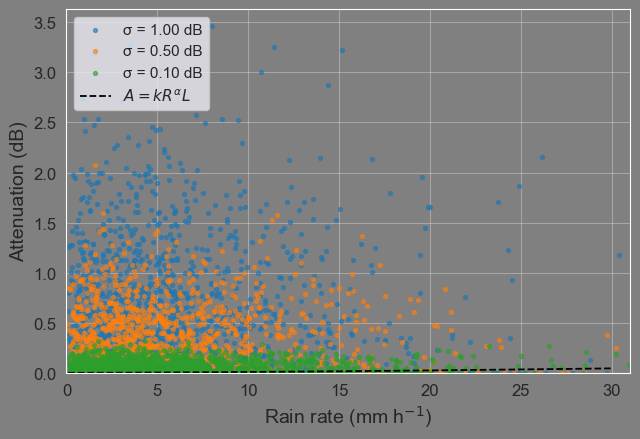

########


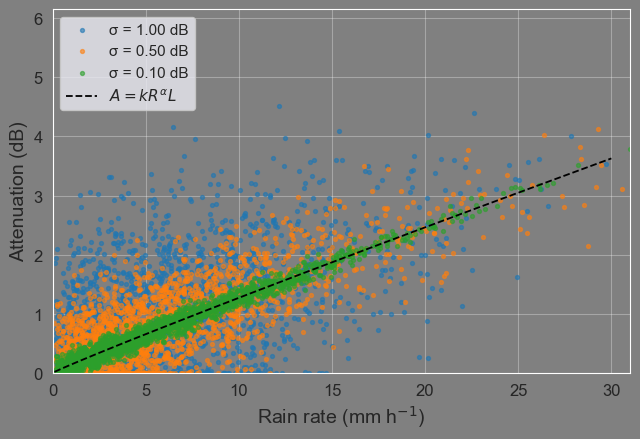

########


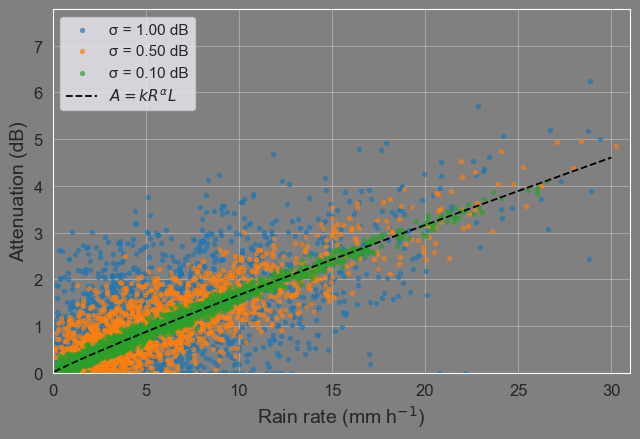

########


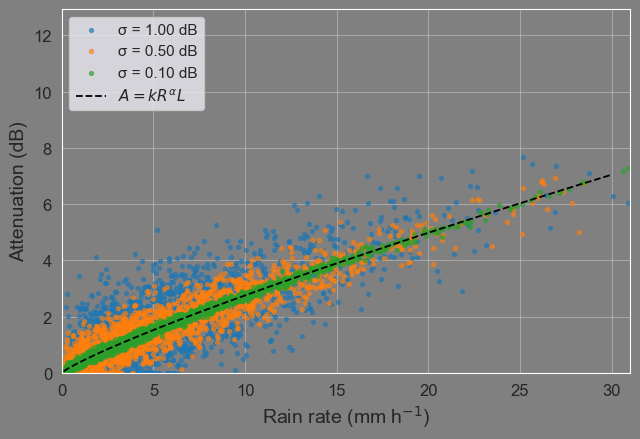

########


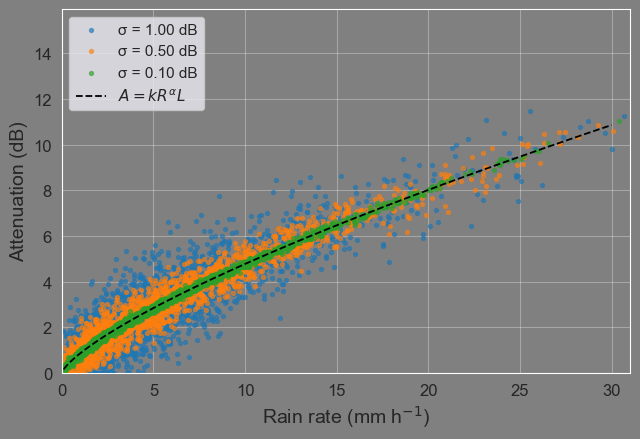

########


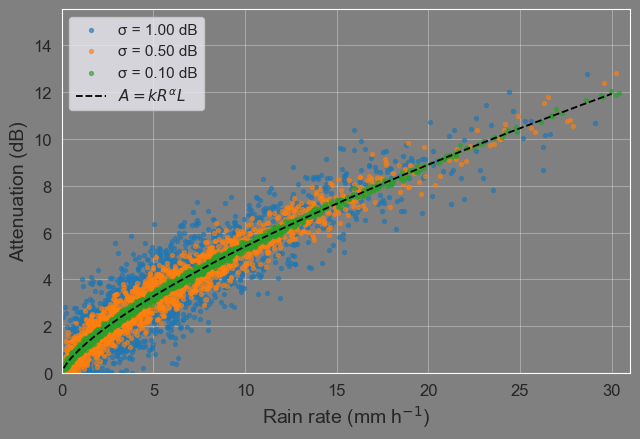

In [25]:
# @title
gen = RainAttenuationGenerator(seed=42)

for f in [5, 24,  28 ,38 , 60, 70 , ]:
    rp = rain_params_from_itu(f, "vertical")
    print('########')
    gen.plot_noise_comparison(
        sigma_vals=[ 1, 0.50, 0.1],
        rain_params=rp,
        link_length_km=1.0, unified= 1,
        freq_ghz=f, bg= 'gray',
        rain_sampler=lambda n: gen._rain_gamma(n, 1.5, 4.0)
    )


In [ ]:
# @title hybrid model
# ========= PYTORCH HYBRID MODEL =========
import torch

class PhysicsBranch(nn.Module):
    """Model-based branch using ITU-R power law inversion"""

    def __init__(self, k_init: float, alpha_init: float, learn_baseline: bool = False):
        super().__init__()
        # Parameters in log space to ensure positivity
        self.log_k = nn.Parameter(torch.log(torch.tensor(k_init, dtype=torch.float32)))
        self.log_alpha = nn.Parameter(torch.log(torch.tensor(alpha_init, dtype=torch.float32)))

        # Optional learnable baseline
        self.learn_baseline = learn_baseline
        if learn_baseline:
            self.baseline = nn.Parameter(torch.zeros(1))

    def forward(self, x_atten: torch.Tensor, link_length: float = 1.0, baseline: float = 0.0):
        k = torch.exp(self.log_k)
        alpha = torch.exp(self.log_alpha)

        if self.learn_baseline:
            baseline = self.baseline.item()

        # Rain attenuation = total - baseline
        rain_atten = F.softplus(x_atten - baseline)

        # Invert power law: R = (A/(k*L))^(1/alpha)
        rain_rate = torch.pow(rain_atten / (k * link_length + 1e-8), 1.0 / alpha)

        return F.softplus(rain_rate)  # Ensure positive

    @property
    def coefficients(self):
        """Get current k, alpha values"""
        return torch.exp(self.log_k).item(), torch.exp(self.log_alpha).item()


class NeuralBranch(nn.Module):
    """Data-driven GRU branch for sequence processing"""

    def __init__(self, input_size: int = 1, hidden_size: int = 64, num_layers: int = 2, dropout: float = 0.1):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True
        )
        self.dropout = nn.Dropout(dropout)
        self.output_layer = nn.Linear(hidden_size, 1)

    def forward(self, x_seq: torch.Tensor):
        """
        Args:
            x_seq: [batch, seq_len, input_size] attenuation sequence
        Returns:
            rain_rate: [batch] predicted rain rates
        """
        gru_out, _ = self.gru(x_seq)  # [batch, seq_len, hidden]

        # Use last timestep
        last_hidden = gru_out[:, -1, :]  # [batch, hidden]
        last_hidden = self.dropout(last_hidden)

        rain_rate = self.output_layer(last_hidden).squeeze(-1)  # [batch]
        return F.relu(rain_rate)  # Ensure non-negative


class FusionGate(nn.Module):
    """Dynamic merger gate implementing paper's feature vector"""

    def __init__(self, feature_dim: int = 6):
        super().__init__()
        # Single linear layer + sigmoid as per paper
        self.gate_layer = nn.Linear(feature_dim, 1)

    def _compute_features(self, x_current, r_physics, r_neural, x_seq=None, eps=1e-6):
        """Compute 6-dimensional feature vector from paper"""

        # Normalized current input (z-score)
        x_mean = x_current.mean() if x_current.numel() > 1 else x_current
        x_std = x_current.std() if x_current.numel() > 1 else torch.tensor(1.0, device=x_current.device)
        x_tilde = (x_current - x_mean) / (x_std + eps)

        # Local statistics from sequence
        if x_seq is not None and x_seq.size(1) > 1:
            # Use last 6 timesteps for local stats
            window_size = min(6, x_seq.size(1))
            recent = x_seq[:, -window_size:, 0]  # [batch, window_size]
            mu_x = recent.mean(dim=1)
            sigma_x = recent.std(dim=1) + eps
        else:
            # Fallback
            mu_x = x_current
            sigma_x = torch.ones_like(x_current) * eps

        # Log-compressed branch predictions
        log_r_physics = torch.log1p(r_physics)
        log_r_neural = torch.log1p(r_neural)

        # Disagreement signal
        r_diff = r_physics - r_neural

        # Stack features: [x_tilde, sigma_x, mu_x, log(1+r_M), log(1+r_D), r_M - r_D]
        features = torch.stack([
            x_tilde, sigma_x, mu_x,
            log_r_physics, log_r_neural, r_diff
        ], dim=1)  # [batch, 6]

        return features

    def forward(self, x_current, r_physics, r_neural, x_seq=None):
        """
        Returns:
            gate_weight: g_t ∈ (0,1)
            r_fused: Convex combination of branches
        """
        features = self._compute_features(x_current, r_physics, r_neural, x_seq)

        gate_logit = self.gate_layer(features).squeeze(-1)  # [batch]
        gate_weight = torch.sigmoid(gate_logit)  # g_t ∈ (0,1)

        # Convex combination: r = g*r_physics + (1-g)*r_neural
        r_fused = gate_weight * r_physics + (1 - gate_weight) * r_neural

        return gate_weight, r_fused


class HybridRainModel(nn.Module):
    """Complete hybrid model: Physics + Neural + Fusion"""

    def __init__(self, k_init: float, alpha_init: float, hidden_size: int = 64,
                 learn_baseline: bool = False, lambda_physics: float = 0.05,
                 lambda_neural: float = 0.05, lambda_reg: float = 1e-5):
        super().__init__()

        # Three branches
        self.physics = PhysicsBranch(k_init, alpha_init, learn_baseline)
        self.neural = NeuralBranch(hidden_size=hidden_size)
        self.fusion = FusionGate()

        # Loss weights
        self.lambda_physics = lambda_physics
        self.lambda_neural = lambda_neural
        self.lambda_reg = lambda_reg

    def forward(self, x_seq: torch.Tensor, link_length: float = 1.0, baseline: float = 0.0):
        """
        Args:
            x_seq: [batch, seq_len, 1] attenuation sequences
            link_length: Link length in km
            baseline: Baseline attenuation in dB
        """
        # Current attenuation (last timestep)
        x_current = x_seq[:, -1, 0]  # [batch]

        # Branch predictions
        r_physics = self.physics(x_current, link_length, baseline)
        r_neural = self.neural(x_seq)

        # Fusion
        gate_weight, r_fused = self.fusion(x_current, r_physics, r_neural, x_seq)

        return {
            'rain_rate': r_fused,
            'rain_physics': r_physics,
            'rain_neural': r_neural,
            'gate_weight': gate_weight
        }

    def compute_loss(self, predictions, targets):
        """Composite loss from paper"""
        r_fused = predictions['rain_rate']
        r_physics = predictions['rain_physics']
        r_neural = predictions['rain_neural']

        # Primary loss (Huber for robustness)
        loss_fused = F.huber_loss(r_fused, targets, delta=1.0)

        # Auxiliary losses (MSE)
        loss_physics = F.mse_loss(r_physics, targets)
        loss_neural = F.mse_loss(r_neural, targets)

        # Regularization
        loss_reg = torch.tensor(0.0, device=targets.device)
        for param in self.parameters():
            loss_reg += torch.norm(param, 2)

        # Composite loss
        total_loss = (loss_fused +
                     self.lambda_physics * loss_physics +
                     self.lambda_neural * loss_neural +
                     self.lambda_reg * loss_reg)

        return {
            'total': total_loss,
            'fused': loss_fused,
            'physics': loss_physics,
            'neural': loss_neural,
            'reg': loss_reg
        }


def create_hybrid_model(freq_ghz: float, pol: str = "vertical", **kwargs):
    """Factory function using ITU-R coefficients"""
    k_init, alpha_init = get_k_alpha(freq_ghz, pol)
    return HybridRainModel(k_init=k_init, alpha_init=alpha_init, **kwargs)



print("Hybrid model components defined")
test_model  = 1
if test_model:
  # Test model creation and forward pass
  model = create_hybrid_model(freq_ghz=24, pol="vertical", hidden_size=64)
  print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
  print(f"Physics coefficients: k={model.physics.coefficients[0]:.2e}, α={model.physics.coefficients[1]:.3f}")

  # Test forward pass with dummy data
  batch_size, seq_len = 32, 48
  x_dummy = torch.randn(batch_size, seq_len, 1) * 2 + 10  # Dummy attenuation sequences
  y_dummy = torch.rand(batch_size) * 10 + 0.5  # Dummy rain rates (0.5-10.5 mm/h)

  with torch.no_grad():
      outputs = model(x_dummy, link_length=1.5, baseline=2.0)
      losses = model.compute_loss(outputs, y_dummy)

  print("\nForward pass successful:")
  for key, value in outputs.items():
      print(f"  {key}: shape={value.shape}, mean={value.mean():.3f}")

  print(f"\nLoss components:")
  for key, value in losses.items():
      print(f"  {key}: {value.item():.4f}")

  print(f"\nGate usage: {outputs['gate_weight'].mean():.3f} (0=neural, 1=physics)")

Hybrid model components defined
Model parameters: 37,898
Physics coefficients: k=1.40e-01, α=0.956

Forward pass successful:
  rain_rate: shape=torch.Size([32]), mean=43.580
  rain_physics: shape=torch.Size([32]), mean=44.273
  rain_neural: shape=torch.Size([32]), mean=0.000
  gate_weight: shape=torch.Size([32]), mean=0.982

Loss components:
  total: 119.4426
  fused: 37.5755
  physics: 1599.9849
  neural: 37.3504
  reg: 32.2154

Gate usage: 0.982 (0=neural, 1=physics)


In [ ]:
# @title
# ========= DATASET GENERATOR & TRAINER =========

def generate_datasets(frequencies, noise_levels, n_samples, gen):
    """Generate datasets for all frequency/noise combinations"""

    datasets = {}
    total_configs = len(frequencies) * len(noise_levels)
    config_count = 0

    print("\nGenerating datasets...")

    for freq in frequencies:
        for sigma in noise_levels:
            config_count += 1

            # Get ITU coefficients
            k, alpha = get_k_alpha(freq, "vertical")
            rain_params = RainParams(k, alpha)

            # Generate data
            R_tr, R_te, A_tr, A_te, meta = gen.generate_data(
                n_samples=n_samples,
                rain_params=rain_params,
                link_length_km=1.5,
                sigma_db=sigma,
                rain_sampler=lambda n: gen._rain_gamma(n, 1.5, 4.0),
                baseline_atten_db=2.0,
                test_size=0.3  # 70% train, 30% test
            )

            # Further split training into train/validation
            R_train, R_val, A_train, A_val = train_test_split(
                R_tr, A_tr, test_size=0.25, random_state=42  # 25% of train = ~17.5% of total
            )

            # Store dataset
            dataset_key = f"{freq}GHz_sigma{sigma}"
            datasets[dataset_key] = {
                'freq': freq,
                'sigma': sigma,
                'k': k,
                'alpha': alpha,
                'train': {'R': R_train, 'A': A_train},
                'val': {'R': R_val, 'A': A_val},
                'test': {'R': R_te, 'A': A_te},
                'meta': meta
            }

            print(f"[{config_count:2d}/{total_configs}] {freq} GHz, σ={sigma} dB: "
                  f"Train={len(R_train)}, Val={len(R_val)}, Test={len(R_te)}")

    return datasets


def summarize_datasets(datasets):
    """Print summary table of all datasets"""

    print(f"\nDATASET SUMMARY")
    print("=" * 80)
    print(f"{'Freq':<8} {'Sigma':<8} {'k coeff':<12} {'α':<8} {'Train':<8} {'Val':<8} {'Test':<8}")
    print("-" * 80)

    total_train = total_val = total_test = 0

    for key, data in datasets.items():
        freq = data['freq']
        sigma = data['sigma']
        k = data['k']
        alpha = data['alpha']
        n_train = len(data['train']['R'])
        n_val = len(data['val']['R'])
        n_test = len(data['test']['R'])

        total_train += n_train
        total_val += n_val
        total_test += n_test

        print(f"{freq:<8} {sigma:<8} {k:<12.2e} {alpha:<8.3f} "
              f"{n_train:<8} {n_val:<8} {n_test:<8}")

    print("-" * 80)
    print(f"{'TOTAL':<8} {'':<8} {'':<12} {'':<8} {total_train:<8} {total_val:<8} {total_test:<8}")
    print("=" * 80)


def prepare_sequences(R, A, seq_len=48):
    """Convert R,A pairs to sequences for neural branch"""
    n_samples = len(R)
    sequences = []
    targets = []

    for i in range(n_samples):
        # Create sequence with variations around current attenuation
        base_atten = A[i]
        seq = np.random.normal(base_atten, 0.15, seq_len)  # Small variations
        seq[-1] = base_atten  # Ensure last value matches target

        sequences.append(seq)
        targets.append(R[i])

    # Convert to tensors
    X = torch.tensor(np.array(sequences), dtype=torch.float32).unsqueeze(-1)  # [n, seq_len, 1]
    y = torch.tensor(np.array(targets), dtype=torch.float32)

    return X, y


class SimpleTrainer:
    """Simple trainer for hybrid model"""

    def __init__(self, model, device='cpu'):
        self.model = model.to(device)
        self.device = device
        self.history = []

    def train_epoch(self, X_train, y_train, optimizer, batch_size=32):
        """Train for one epoch"""
        self.model.train()
        total_loss = 0
        n_batches = 0

        # Shuffle data
        indices = torch.randperm(len(X_train))
        X_train = X_train[indices]
        y_train = y_train[indices]

        for i in range(0, len(X_train), batch_size):
            batch_x = X_train[i:i+batch_size].to(self.device)
            batch_y = y_train[i:i+batch_size].to(self.device)

            optimizer.zero_grad()

            outputs = self.model(batch_x, link_length=1.5, baseline=2.0)
            losses = self.model.compute_loss(outputs, batch_y)

            losses['total'].backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += losses['total'].item()
            n_batches += 1

        return total_loss / n_batches

    def validate(self, X_val, y_val, batch_size=32):
        """Validate model"""
        self.model.eval()
        total_loss = 0
        n_batches = 0
        gate_weights = []

        with torch.no_grad():
            for i in range(0, len(X_val), batch_size):
                batch_x = X_val[i:i+batch_size].to(self.device)
                batch_y = y_val[i:i+batch_size].to(self.device)

                outputs = self.model(batch_x, link_length=1.5, baseline=2.0)
                losses = self.model.compute_loss(outputs, batch_y)

                total_loss += losses['total'].item()
                gate_weights.extend(outputs['gate_weight'].cpu().numpy())
                n_batches += 1

        return total_loss / n_batches, np.mean(gate_weights)

    def train(self, dataset, epochs=20, lr=1e-3, batch_size=32):
        """Train model on dataset"""

        # Prepare data
        X_train, y_train = prepare_sequences(dataset['train']['R'], dataset['train']['A'])
        X_val, y_val = prepare_sequences(dataset['val']['R'], dataset['val']['A'])

        print(f"Training data: {X_train.shape}, Validation data: {X_val.shape}")

        # Optimizer
        optimizer = torch.optim.Adam(self.model.parameters(), lr=lr, weight_decay=1e-5)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.7)

        # Training loop
        best_val_loss = float('inf')

        for epoch in range(epochs):
            train_loss = self.train_epoch(X_train, y_train, optimizer, batch_size)
            val_loss, gate_usage = self.validate(X_val, y_val, batch_size)

            scheduler.step(val_loss)

            # Track history
            k_current, alpha_current = self.model.physics.coefficients
            self.history.append({
                'epoch': epoch,
                'train_loss': train_loss,
                'val_loss': val_loss,
                'gate_usage': gate_usage,
                'k': k_current,
                'alpha': alpha_current
            })

            if val_loss < best_val_loss:
                best_val_loss = val_loss

            if epoch % 5 == 0 or epoch == epochs - 1:
                print(f"Epoch {epoch:2d}: Train={train_loss:.4f}, Val={val_loss:.4f}, "
                      f"Gate={gate_usage:.3f}, k={k_current:.2e}, α={alpha_current:.3f}")

        return best_val_loss

# ========= MAIN EXECUTION =========
def main():
    """Generate datasets for specified frequencies and noise levels"""

    # Configuration
    # FREQUENCIES = [5, 24, 28, 38, 60, 70]  # GHz
    FREQUENCIES = [38]  # GHz

    NOISE_LEVELS = [0.01, 0.2, 0.5, 0.7, 1.0]  # dB
    N_SAMPLES = 10000

    print("=" * 50)
    print(f"Frequencies: {FREQUENCIES} GHz")
    print(f"Noise levels: {NOISE_LEVELS} dB")
    print(f"Samples per configuration: {N_SAMPLES}")

    # Step 1: Initialize generator and generate datasets
    gen = RainAttenuationGenerator(seed=42)
    datasets = generate_datasets(FREQUENCIES, NOISE_LEVELS, N_SAMPLES, gen)

    # Step 2: Summarize datasets
    summarize_datasets(datasets)

    return datasets

# Run the main function
datasets = main()

Frequencies: [38] GHz
Noise levels: [0.01, 0.2, 0.5, 0.7, 1.0] dB
Samples per configuration: 10000

Generating datasets...
[ 1/5] 38 GHz, σ=0.01 dB: Train=5250, Val=1750, Test=3000
[ 2/5] 38 GHz, σ=0.2 dB: Train=5250, Val=1750, Test=3000
[ 3/5] 38 GHz, σ=0.5 dB: Train=5250, Val=1750, Test=3000
[ 4/5] 38 GHz, σ=0.7 dB: Train=5250, Val=1750, Test=3000
[ 5/5] 38 GHz, σ=1.0 dB: Train=5250, Val=1750, Test=3000

DATASET SUMMARY
Freq     Sigma    k coeff      α        Train    Val      Test    
--------------------------------------------------------------------------------
38       0.01     3.84e-01     0.855    5250     1750     3000    
38       0.2      3.84e-01     0.855    5250     1750     3000    
38       0.5      3.84e-01     0.855    5250     1750     3000    
38       0.7      3.84e-01     0.855    5250     1750     3000    
38       1.0      3.84e-01     0.855    5250     1750     3000    
--------------------------------------------------------------------------------
TOTAL     

In [ ]:
# @title
# ========= COLAB-OPTIMIZED TRAINING =========

class ColabTrainer:
    """Simplified trainer optimized for Colab demonstration"""

    def __init__(self, model, device='cuda'):
        self.model = model.to(device)
        self.device = device
        self.history = []

    def train_branches_only(self, dataset, epochs=5, lr=1e-3):
        """Train only physics and neural branches"""
        print("Training branches separately...")

        X_train, y_train = prepare_sequences(dataset['train']['R'][:200], dataset['train']['A'][:200])
        X_train, y_train = X_train.to(self.device), y_train.to(self.device)

        # Freeze fusion
        for param in self.model.fusion.parameters():
            param.requires_grad = False

        branch_params = list(self.model.physics.parameters()) + list(self.model.neural.parameters())
        optimizer = torch.optim.Adam(branch_params, lr=lr)

        for epoch in range(epochs):
            self.model.train()
            total_loss = 0

            for i in range(0, len(X_train), 16):  # Small batches
                batch_x = X_train[i:i+16]
                batch_y = y_train[i:i+16]

                optimizer.zero_grad()
                outputs = self.model(batch_x, link_length=1.5, baseline=2.0)

                loss = F.mse_loss(outputs['rain_physics'], batch_y) + F.mse_loss(outputs['rain_neural'], batch_y)
                loss.backward()
                optimizer.step()

                total_loss += loss.item()

            k, alpha = self.model.physics.coefficients
            print(f"  Epoch {epoch+1}: Loss={total_loss/(len(X_train)//16):.4f}, k={k:.2e}, α={alpha:.3f}")

        # Unfreeze fusion
        for param in self.model.fusion.parameters():
            param.requires_grad = True

    def train_joint(self, dataset, epochs=10, lr=1e-4):
        """Train all components jointly"""
        print("Joint training...")

        X_train, y_train = prepare_sequences(dataset['train']['R'][:200], dataset['train']['A'][:200])
        X_train, y_train = X_train.to(self.device), y_train.to(self.device)

        optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)

        for epoch in range(epochs):
            self.model.train()
            total_loss = 0
            gate_weights = []

            for i in range(0, len(X_train), 16):
                batch_x = X_train[i:i+16]
                batch_y = y_train[i:i+16]

                optimizer.zero_grad()
                outputs = self.model(batch_x, link_length=1.5, baseline=2.0)
                losses = self.model.compute_loss(outputs, batch_y)

                losses['total'].backward()
                optimizer.step()

                total_loss += losses['total'].item()
                gate_weights.extend(outputs['gate_weight'].detach().cpu().numpy())

            k, alpha = self.model.physics.coefficients
            avg_gate = np.mean(gate_weights)

            print(f"  Epoch {epoch+1}: Loss={total_loss/(len(X_train)//16):.4f}, "
                  f"Gate={avg_gate:.3f}, k={k:.2e}, α={alpha:.3f}")

print("Colab trainer ready")


Colab trainer ready
Visualization tools ready


In [ ]:
# @title
# ========= ENHANCED TRAINER WITH VISUALIZATION =========

class VisualizingTrainer:
    """Trainer that tracks and visualizes training progress"""

    def __init__(self, model, model_name, device='cpu'):
        self.model = model.to(device)
        self.device = device
        self.model_name = model_name
        self.history = {'train_loss': [], 'val_loss': [], 'gate_usage': [], 'epochs': [], 'k_values': [], 'alpha_values': []}

    def train_with_tracking(self, dataset, epochs=15, lr=1e-4, stage_name=""):
        """Train model and track all metrics"""
        print(f"\n{stage_name} - {self.model_name}")
        print("-" * 40)

        # Prepare data
        X_train, y_train = prepare_sequences(dataset['train']['R'][:300], dataset['train']['A'][:300])
        X_val, y_val = prepare_sequences(dataset['val']['R'][:100], dataset['val']['A'][:100])

        X_train, y_train = X_train.to(self.device), y_train.to(self.device)
        X_val, y_val = X_val.to(self.device), y_val.to(self.device)

        optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)

        for epoch in range(epochs):
            # Training
            self.model.train()
            train_loss = 0
            train_gates = []

            for i in range(0, len(X_train), 16):
                batch_x = X_train[i:i+16]
                batch_y = y_train[i:i+16]

                optimizer.zero_grad()
                outputs = self.model(batch_x, link_length=1.5, baseline=2.0)
                losses = self.model.compute_loss(outputs, batch_y)

                losses['total'].backward()
                optimizer.step()

                train_loss += losses['total'].item()
                train_gates.extend(outputs['gate_weight'].detach().cpu().numpy())

            # Validation
            self.model.eval()
            val_loss = 0
            val_gates = []

            with torch.no_grad():
                for i in range(0, len(X_val), 16):
                    batch_x = X_val[i:i+16]
                    batch_y = y_val[i:i+16]

                    outputs = self.model(batch_x, link_length=1.5, baseline=2.0)
                    losses = self.model.compute_loss(outputs, batch_y)

                    val_loss += losses['total'].item()
                    val_gates.extend(outputs['gate_weight'].detach().cpu().numpy())

            # Track metrics
            avg_train_loss = train_loss / (len(X_train) // 16)
            avg_val_loss = val_loss / (len(X_val) // 16)
            avg_gate = np.mean(train_gates + val_gates)
            k_current, alpha_current = self.model.physics.coefficients

            self.history['train_loss'].append(avg_train_loss)
            self.history['val_loss'].append(avg_val_loss)
            self.history['gate_usage'].append(avg_gate)
            self.history['epochs'].append(len(self.history['epochs']))
            self.history['k_values'].append(k_current)
            self.history['alpha_values'].append(alpha_current)

            if epoch % 3 == 0 or epoch == epochs - 1:
                print(f"  Epoch {epoch+1:2d}: Train={avg_train_loss:.4f}, Val={avg_val_loss:.4f}, "
                      f"Gate={avg_gate:.3f}, k={k_current:.2e}")


def plot_training_comparison(trainers, dataset_info):
    """Create comprehensive training comparison plots"""

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    colors = ['blue', 'red', 'green']

    # Plot 1: Training/Validation Loss
    ax1 = axes[0, 0]
    for i, trainer in enumerate(trainers):
        epochs = range(1, len(trainer.history['train_loss']) + 1)
        ax1.plot(epochs, trainer.history['train_loss'], f'-o', color=colors[i],
                label=f'{trainer.model_name} Train', markersize=3)
        ax1.plot(epochs, trainer.history['val_loss'], f'--s', color=colors[i],
                label=f'{trainer.model_name} Val', markersize=3)

    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training & Validation Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_yscale('log')

    # Plot 2: Gate Usage Evolution
    ax2 = axes[0, 1]
    for i, trainer in enumerate(trainers):
        epochs = range(1, len(trainer.history['gate_usage']) + 1)
        ax2.plot(epochs, trainer.history['gate_usage'], f'-o', color=colors[i],
                label=trainer.model_name, markersize=4)

    ax2.axhline(y=0.5, color='black', linestyle=':', alpha=0.7, label='Balanced')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Gate Weight')
    ax2.set_title('Gate Usage Evolution\n(0=Neural, 1=Physics)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 1)

    # Plot 3: Data Distribution (Rain vs Attenuation)
    ax3 = axes[0, 2]
    R_sample = dataset_info['train']['R'][:500]
    A_sample = dataset_info['train']['A'][:500]
    ax3.scatter(R_sample, A_sample, alpha=0.6, s=15, c='blue', label='Training Data')

    # Theoretical curve
    k, alpha = dataset_info['k'], dataset_info['alpha']
    R_theory = np.linspace(0.1, np.max(R_sample), 100)
    A_theory = k * (R_theory ** alpha) * 1.5 + 2.0
    ax3.plot(R_theory, A_theory, '--k', linewidth=2, label='ITU-R Theory')

    ax3.set_xlabel('Rain Rate [mm/h]')
    ax3.set_ylabel('Attenuation [dB]')
    ax3.set_title(f'Data Distribution\n{dataset_info["freq"]} GHz, σ={dataset_info["sigma"]} dB')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # Plot 4: Coefficient Evolution (k)
    ax4 = axes[1, 0]
    k_itu = dataset_info['k']
    ax4.axhline(y=k_itu, color='black', linestyle=':', linewidth=2, label='ITU-R k')

    for i, trainer in enumerate(trainers):
        epochs = range(1, len(trainer.history['k_values']) + 1)
        ax4.plot(epochs, trainer.history['k_values'], f'-o', color=colors[i],
                label=f'{trainer.model_name}', markersize=3)

    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('k coefficient')
    ax4.set_title('k Coefficient Evolution')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    ax4.set_yscale('log')

    # Plot 5: Coefficient Evolution (α)
    ax5 = axes[1, 1]
    alpha_itu = dataset_info['alpha']
    ax5.axhline(y=alpha_itu, color='black', linestyle=':', linewidth=2, label='ITU-R α')

    for i, trainer in enumerate(trainers):
        epochs = range(1, len(trainer.history['alpha_values']) + 1)
        ax5.plot(epochs, trainer.history['alpha_values'], f'-o', color=colors[i],
                label=f'{trainer.model_name}', markersize=3)

    ax5.set_xlabel('Epoch')
    ax5.set_ylabel('α exponent')
    ax5.set_title('α Exponent Evolution')
    ax5.legend()
    ax5.grid(True, alpha=0.3)

    # Plot 6: Final Performance Comparison
    ax6 = axes[1, 2]
    model_names = [trainer.model_name for trainer in trainers]
    final_train_loss = [trainer.history['train_loss'][-1] for trainer in trainers]
    final_val_loss = [trainer.history['val_loss'][-1] for trainer in trainers]
    final_gate_usage = [trainer.history['gate_usage'][-1] for trainer in trainers]

    x = np.arange(len(model_names))
    width = 0.35

    bars1 = ax6.bar(x - width/2, final_train_loss, width, label='Train Loss', alpha=0.8)
    bars2 = ax6.bar(x + width/2, final_val_loss, width, label='Val Loss', alpha=0.8)

    ax6.set_xlabel('Model')
    ax6.set_ylabel('Final Loss')
    ax6.set_title('Final Performance Comparison')
    ax6.set_xticks(x)
    ax6.set_xticklabels(model_names, rotation=45)
    ax6.legend()
    ax6.grid(True, alpha=0.3)

    # Add gate usage as text on bars
    for i, (bar1, bar2, gate) in enumerate(zip(bars1, bars2, final_gate_usage)):
        height = max(bar1.get_height(), bar2.get_height())
        ax6.text(i, height + 0.01, f'Gate: {gate:.2f}',
                ha='center', va='bottom', fontsize=9, rotation=0)

    plt.tight_layout()
    plt.show()

print("Visualization tools ready")

# ========= UNIFIED PLOTTING FUNCTIONS =========

def plot_comprehensive_analysis(trainers, datasets, freq, noise_levels):
    """Unified comprehensive analysis plots"""

    # Plot 1: Data distribution across noise levels
    fig1, axes1 = plt.subplots(1, len(noise_levels), figsize=(4*len(noise_levels), 4))
    axes1 = np.atleast_1d(axes1)

    for idx, sigma in enumerate(noise_levels):
        dataset_key = f"{freq}GHz_sigma{sigma}"
        dataset = datasets[dataset_key]

        ax = axes1[idx]

        # Data scatter
        R_sample = dataset['train']['R'][:200]
        A_sample = dataset['train']['A'][:200]
        ax.scatter(R_sample, A_sample, alpha=0.6, s=8, c='blue', label='Data')

        # ITU-R theoretical curve
        k, alpha = dataset['k'], dataset['alpha']
        R_theory = np.linspace(0.1, np.max(R_sample), 100)
        A_theory = k * (R_theory ** alpha) * 1.5 + 2.0
        ax.plot(R_theory, A_theory, '--k', linewidth=2, label='ITU-R')

        ax.set_xlabel('Rain Rate [mm/h]')
        if idx == 0:
            ax.set_ylabel('Attenuation [dB]')
        ax.set_title(f'σ = {sigma} dB')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.suptitle(f'{freq} GHz Data Distribution', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Plot 2: Gate evolution showing noise effect
    fig2, axes2 = plt.subplots(1, len(noise_levels), figsize=(4*len(noise_levels), 4))
    axes2 = np.atleast_1d(axes2)

    for idx, sigma in enumerate(noise_levels):
        phases_trainer = next(t for t in trainers if f"Phases-σ{sigma}" in t.model_name)
        joint_trainer = next(t for t in trainers if f"JointFT-σ{sigma}" in t.model_name)

        ax = axes2[idx]

        # Plot gate evolution
        if phases_trainer.history['gate_usage']:
            epochs_phases = range(1, len(phases_trainer.history['gate_usage']) + 1)
            ax.plot(epochs_phases, phases_trainer.history['gate_usage'], 'b-o',
                    label='Phases', markersize=3, linewidth=2)

        epochs_joint = range(1, len(joint_trainer.history['gate_usage']) + 1)
        ax.plot(epochs_joint, joint_trainer.history['gate_usage'], 'r-s',
                label='Joint FT', markersize=3, linewidth=2)

        # Expected trend line - should decrease with noise
        expected_gate = max(0.8 - sigma*0.5, 0.3)  # Physics dominance should decrease with noise
        ax.axhline(y=expected_gate, color='gray', linestyle=':', alpha=0.7,
                  label=f'Expected≈{expected_gate:.1f}')
        ax.axhline(y=0.5, color='black', linestyle=':', alpha=0.5, label='Balanced' if idx == 0 else '')

        ax.set_xlabel('Epoch')
        if idx == 0:
            ax.set_ylabel('Gate Weight g()')
        ax.set_title(f'σ = {sigma} dB')
        if idx == 0:
            ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, 1)

    plt.suptitle(f'{freq} GHz Gate Evolution: Physics vs Neural Dominance',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Plot 3: Noise effect analysis - key insight plot
    fig3, axes3 = plt.subplots(2, 2, figsize=(12, 10))

    # Extract metrics across noise levels
    phases_metrics = {'gate': [], 'k_vals': [], 'alpha_vals': []}
    joint_metrics = {'gate': [], 'k_vals': [], 'alpha_vals': []}

    for sigma in noise_levels:
        phases_trainer = next(t for t in trainers if f"Phases-σ{sigma}" in t.model_name)
        joint_trainer = next(t for t in trainers if f"JointFT-σ{sigma}" in t.model_name)

        if phases_trainer.history['gate_usage']:
            phases_metrics['gate'].append(phases_trainer.history['gate_usage'][-1])
            phases_metrics['k_vals'].append(phases_trainer.history['k_values'][-1])
            phases_metrics['alpha_vals'].append(phases_trainer.history['alpha_values'][-1])
        else:
            phases_metrics['gate'].append(0.5)
            phases_metrics['k_vals'].append(0)
            phases_metrics['alpha_vals'].append(0)

        joint_metrics['gate'].append(joint_trainer.history['gate_usage'][-1])
        joint_metrics['k_vals'].append(joint_trainer.history['k_values'][-1])
        joint_metrics['alpha_vals'].append(joint_trainer.history['alpha_values'][-1])

    # Plot 3a: Gate usage vs noise (key insight)
    ax3a = axes3[0,0]
    ax3a.plot(noise_levels, phases_metrics['gate'], 'bo-', label='Phases', linewidth=2, markersize=6)
    ax3a.plot(noise_levels, joint_metrics['gate'], 'rs-', label='Joint FT', linewidth=2, markersize=6)
    # Add expected trend
    expected_trend = [max(0.9 - s*0.4, 0.2) for s in noise_levels]
    ax3a.plot(noise_levels, expected_trend, 'g--', label='Expected Trend', linewidth=2)
    ax3a.axhline(y=0.5, color='black', linestyle=':', alpha=0.5, label='Balanced')
    ax3a.set_xlabel('Noise Level σ [dB]')
    ax3a.set_ylabel('Final Gate Weight g()')
    ax3a.set_title('KEY INSIGHT: Gate Response to Noise\n(Should decrease as PL model fails)')
    ax3a.legend()
    ax3a.grid(True, alpha=0.3)

    # Plot 3b: Coefficient adaptation
    ax3b = axes3[0,1]
    k_itu, alpha_itu = get_k_alpha(freq, "vertical")
    ax3b.axhline(y=alpha_itu, color='black', linestyle='--', linewidth=2, label='ITU-R α')
    ax3b.plot(noise_levels, phases_metrics['alpha_vals'], 'bo-', label='Phases α', linewidth=2, markersize=6)
    ax3b.plot(noise_levels, joint_metrics['alpha_vals'], 'rs-', label='Joint FT α', linewidth=2, markersize=6)
    ax3b.set_xlabel('Noise Level σ [dB]')
    ax3b.set_ylabel('α coefficient')
    ax3b.set_title('Coefficient Adaptation to Noise')
    ax3b.legend()
    ax3b.grid(True, alpha=0.3)

    # Plot 3c: Training loss comparison
    ax3c = axes3[1,0]
    joint_final_losses = [next(t for t in trainers if f"JointFT-σ{sigma}" in t.model_name).history['train_loss'][-1]
                         for sigma in noise_levels]
    ax3c.plot(noise_levels, joint_final_losses, 'rs-', label='Joint FT', linewidth=2, markersize=6)
    ax3c.set_xlabel('Noise Level σ [dB]')
    ax3c.set_ylabel('Final Training Loss')
    ax3c.set_title('Performance Degradation with Noise')
    ax3c.legend()
    ax3c.grid(True, alpha=0.3)
    ax3c.set_yscale('log')

    # Plot 3d: Method comparison
    ax3d = axes3[1,1]
    methods = ['Phases', 'Joint FT']
    avg_gates = [np.mean(phases_metrics['gate']), np.mean(joint_metrics['gate'])]
    colors = ['blue', 'red']
    bars = ax3d.bar(methods, avg_gates, color=colors, alpha=0.7)
    ax3d.axhline(y=0.5, color='black', linestyle='--', alpha=0.7, label='Balanced')
    ax3d.set_ylabel('Average Gate Weight g()')
    ax3d.set_title('Method Comparison\n(Average across all noise levels)')
    ax3d.legend()
    ax3d.grid(True, alpha=0.3)

    # Add values on bars
    for bar, val in zip(bars, avg_gates):
        ax3d.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

    plt.suptitle(f'{freq} GHz Analysis: Noise Impact on Hybrid Model', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("Unified plotting functions ready")

Visualization tools ready
Unified plotting functions ready


In [ ]:
# ========= TRAINING EXPERIMENT: PHASES vs JOINT FINE-TUNING =========

# Configuration
EXPERIMENT_FREQ = 38
EXPERIMENT_NOISE_LEVELS = [0.05,  0.5, 0.75, 1.0]
EXPERIMENT_SAMPLES = 10000

print(f"Training Comparison: Phases vs Joint Fine-Tuning")
print(f"Frequency: {EXPERIMENT_FREQ} GHz")
print(f"Noise levels: {EXPERIMENT_NOISE_LEVELS}")

# Generate datasets
exp_gen = RainAttenuationGenerator(seed=42)
exp_datasets = generate_datasets([EXPERIMENT_FREQ], EXPERIMENT_NOISE_LEVELS,
                                EXPERIMENT_SAMPLES, exp_gen)

# Training with two different approaches
all_trainers = []

for idx, sigma in enumerate(EXPERIMENT_NOISE_LEVELS):
    print(f"\nTraining on σ={sigma} dB...")

    dataset_key = f"{EXPERIMENT_FREQ}GHz_sigma{sigma}"
    dataset = exp_datasets[dataset_key]

    # Create two models for comparison
    model_phases = create_hybrid_model(freq_ghz=EXPERIMENT_FREQ, pol="vertical", hidden_size=32)
    model_joint = create_hybrid_model(freq_ghz=EXPERIMENT_FREQ, pol="vertical", hidden_size=32)

    trainer_phases = ThreeStageTrainer(model_phases, device=device)
    trainer_joint = VisualizingTrainer(model_joint, f"JointFT-σ{sigma}", device=device)

    # Method 1: Phases Training (branches → frozen → joint)
    print("  Training with Phases method...")
    trainer_phases.stage1_train_branches_separate(dataset, epochs=8, lr=1e-3)
    trainer_phases.stage2_frozen_branches(dataset, epochs=5, lr=5e-4)
    trainer_phases.stage3_joint_training(dataset, epochs=7, lr=1e-4)

    # Method 2: Joint Fine-Tuning (all together from start)
    print("  Training with Joint FT method...")
    trainer_joint.train_with_tracking(dataset, epochs=20, lr=1e-4, stage_name="Joint FT")

    # Create wrapper for phases trainer
    class PhasesWrapper:
        def __init__(self, trainer, sigma):
            self.trainer = trainer
            self.model = trainer.model
            self.model_name = f"Phases-σ{sigma}"
            # Extract stage 3 history for comparison
            stage3_hist = trainer.stage_history.get('stage3', [])
            self.history = {
                'gate_usage': [h['gate_usage'] for h in stage3_hist],
                'k_values': [h['k'] for h in stage3_hist],
                'alpha_values': [h['alpha'] for h in stage3_hist],
                'train_loss': [h['train_loss'] for h in stage3_hist],
                'val_loss': []  # Not tracked in 3-stage
            }

    phases_wrapper = PhasesWrapper(trainer_phases, sigma)
    all_trainers.extend([phases_wrapper, trainer_joint])

print("Training complete!")

Training Comparison: Phases vs Joint Fine-Tuning
Frequency: 38 GHz
Noise levels: [0.05, 0.5, 0.75, 1.0]

Generating datasets...
[ 1/4] 38 GHz, σ=0.05 dB: Train=5250, Val=1750, Test=3000
[ 2/4] 38 GHz, σ=0.5 dB: Train=5250, Val=1750, Test=3000
[ 3/4] 38 GHz, σ=0.75 dB: Train=5250, Val=1750, Test=3000
[ 4/4] 38 GHz, σ=1.0 dB: Train=5250, Val=1750, Test=3000

Training on σ=0.05 dB...
  Training with Phases method...

STAGE 1: Training branches separately
Epoch  0: Train=28.3246, Physics=0.2582, Neural=28.0664, k=4.20e-01
Epoch  3: Train=3.5424, Physics=0.2032, Neural=3.3392, k=4.45e-01
Epoch  6: Train=1.5797, Physics=0.2028, Neural=1.3768, k=4.47e-01
Stage 1 complete - branches initialized

STAGE 2: Training fusion with frozen branches
Epoch  0: Train=0.0628, Gate=0.599
Epoch  3: Train=0.0471, Gate=0.607
Stage 2 complete - fusion gate trained

STAGE 3: Joint training (all parameters)
Epoch  0: Train=0.0883, Gate=0.609, k=4.46e-01, α=0.799
Epoch  3: Train=0.0790, Gate=0.622, k=4.45e-01, α=

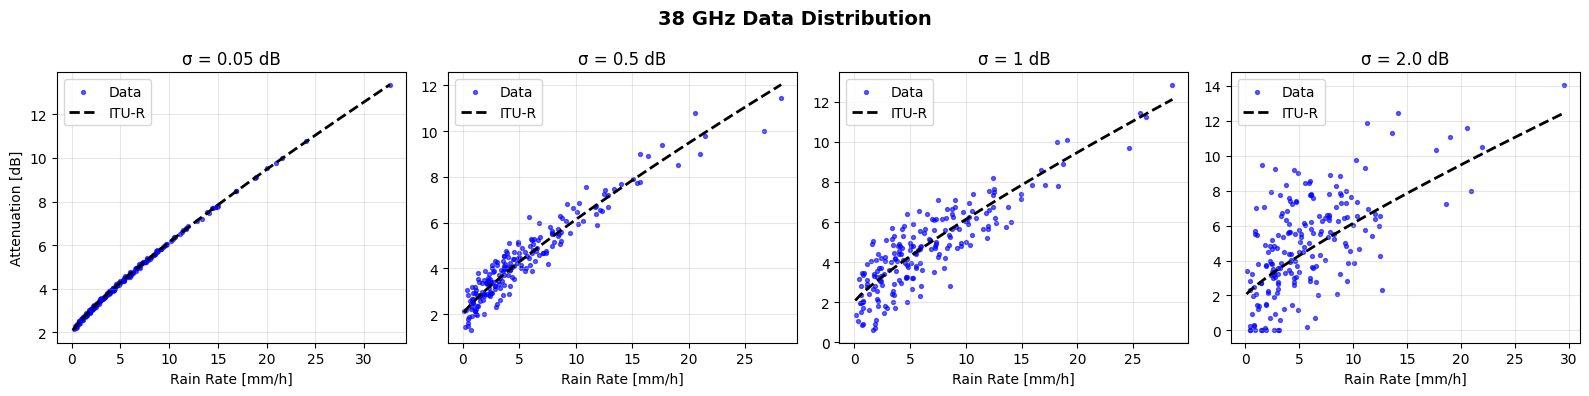

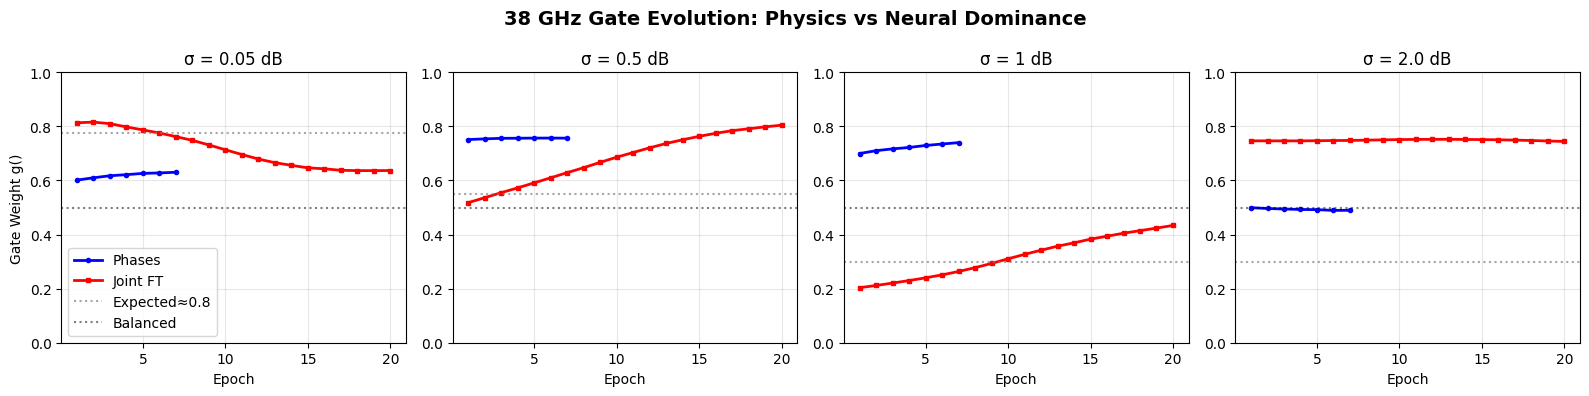

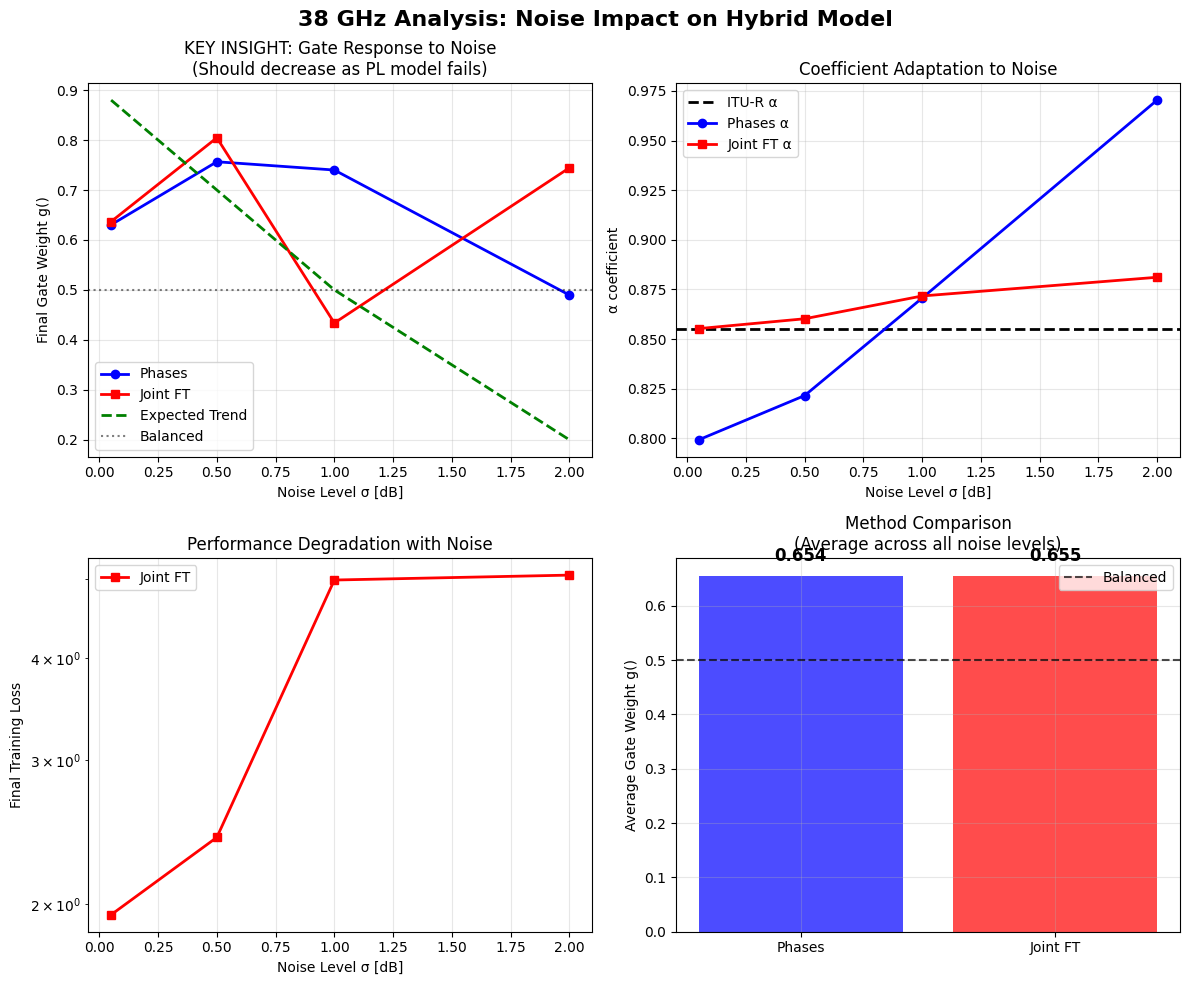


FINAL ANALYSIS - 38 GHz
Noise    Method     Gate g()   k coeff      α       
----------------------------------------------------------------------
ITU-R    Reference  -          3.844e-01    0.855   
0.05     Phases     0.630      4.463e-01    0.799   
0.05     JointFT    0.637      3.785e-01    0.855   
0.5      Phases     0.757      4.335e-01    0.822   
0.5      JointFT    0.805      3.872e-01    0.860   
1        Phases     0.740      4.085e-01    0.871   
1        JointFT    0.434      3.913e-01    0.872   
2.0      Phases     0.490      4.004e-01    0.970   
2.0      JointFT    0.744      3.962e-01    0.881   
Expected trend: Higher noise → Lower gate g() → More neural reliance
This shows the model adapting away from physics when PL model becomes unreliable


In [ ]:
# ========= EXECUTE COMPREHENSIVE ANALYSIS =========

plot_comprehensive_analysis(all_trainers, exp_datasets, EXPERIMENT_FREQ, EXPERIMENT_NOISE_LEVELS)

# Summary table
print(f"\nFINAL ANALYSIS - {EXPERIMENT_FREQ} GHz")
print("="*70)
print(f"{'Noise':<8} {'Method':<10} {'Gate g()':<10} {'k coeff':<12} {'α':<8}")
print("-"*70)

k_itu, alpha_itu = get_k_alpha(EXPERIMENT_FREQ, "vertical")
print(f"{'ITU-R':<8} {'Reference':<10} {'-':<10} {k_itu:<12.3e} {alpha_itu:<8.3f}")

for trainer in all_trainers:
    if hasattr(trainer, 'history') and trainer.history['gate_usage']:
        noise_level = trainer.model_name.split('σ')[1]
        method = trainer.model_name.split('-')[0]

        final_gate = trainer.history['gate_usage'][-1] if trainer.history['gate_usage'] else 0.0
        final_k = trainer.history['k_values'][-1] if trainer.history['k_values'] else 0.0
        final_alpha = trainer.history['alpha_values'][-1] if trainer.history['alpha_values'] else 0.0

        print(f"{noise_level:<8} {method:<10} {final_gate:<10.3f} {final_k:<12.3e} {final_alpha:<8.3f}")

print("="*70)
print("Expected trend: Higher noise → Lower gate g() → More neural reliance")
print("This shows the model adapting away from physics when PL model becomes unreliable")

In [ ]:
# ========= TRAINING EXPERIMENT: PHASES vs JOINT FINE-TUNING =========

# Configuration
EXPERIMENT_FREQ = 38
EXPERIMENT_NOISE_LEVELS = [0.05, 0.5, 1, 2.0]
EXPERIMENT_SAMPLES = 10000

print(f"Training Comparison: Phases vs Joint Fine-Tuning")
print(f"Frequency: {EXPERIMENT_FREQ} GHz")
print(f"Noise levels: {EXPERIMENT_NOISE_LEVELS}")

# Generate datasets
exp_gen = RainAttenuationGenerator(seed=42)
exp_datasets = generate_datasets([EXPERIMENT_FREQ], EXPERIMENT_NOISE_LEVELS,
                                EXPERIMENT_SAMPLES, exp_gen)

# Training with two different approaches
all_trainers = []

for idx, sigma in enumerate(EXPERIMENT_NOISE_LEVELS):
    print(f"\nTraining on σ={sigma} dB...")

    dataset_key = f"{EXPERIMENT_FREQ}GHz_sigma{sigma}"
    dataset = exp_datasets[dataset_key]

    # Create two models for comparison
    model_phases = create_hybrid_model(freq_ghz=EXPERIMENT_FREQ, pol="vertical", hidden_size=32)
    model_joint = create_hybrid_model(freq_ghz=EXPERIMENT_FREQ, pol="vertical", hidden_size=32)

    trainer_phases = ThreeStageTrainer(model_phases, device=device)
    trainer_joint = VisualizingTrainer(model_joint, f"JointFT-σ{sigma}", device=device)

    # Method 1: Phases Training (branches → frozen → joint)
    print("  Training with Phases method...")
    trainer_phases.stage1_train_branches_separate(dataset, epochs=8, lr=1e-3)
    trainer_phases.stage2_frozen_branches(dataset, epochs=5, lr=5e-4)
    trainer_phases.stage3_joint_training(dataset, epochs=7, lr=1e-4)

    # Method 2: Joint Fine-Tuning (all together from start)
    print("  Training with Joint FT method...")
    trainer_joint.train_with_tracking(dataset, epochs=20, lr=1e-4, stage_name="Joint FT")

    # Create wrapper for phases trainer
    class PhasesWrapper:
        def __init__(self, trainer, sigma):
            self.trainer = trainer
            self.model = trainer.model
            self.model_name = f"Phases-σ{sigma}"
            # Extract stage 3 history for comparison
            stage3_hist = trainer.stage_history.get('stage3', [])
            self.history = {
                'gate_usage': [h['gate_usage'] for h in stage3_hist],
                'k_values': [h['k'] for h in stage3_hist],
                'alpha_values': [h['alpha'] for h in stage3_hist],
                'train_loss': [h['train_loss'] for h in stage3_hist],
                'val_loss': []  # Not tracked in 3-stage
            }

    phases_wrapper = PhasesWrapper(trainer_phases, sigma)
    all_trainers.extend([phases_wrapper, trainer_joint])

print("Training complete!")

Training Comparison: Phases vs Joint Fine-Tuning
Frequency: 38 GHz
Noise levels: [0.05, 0.5, 1, 2.0]

Generating datasets...
[ 1/4] 38 GHz, σ=0.05 dB: Train=5250, Val=1750, Test=3000
[ 2/4] 38 GHz, σ=0.5 dB: Train=5250, Val=1750, Test=3000
[ 3/4] 38 GHz, σ=1 dB: Train=5250, Val=1750, Test=3000
[ 4/4] 38 GHz, σ=2.0 dB: Train=5250, Val=1750, Test=3000

Training on σ=0.05 dB...
  Training with Phases method...

STAGE 1: Training branches separately
Epoch  0: Train=29.4958, Physics=0.2582, Neural=29.2376, k=4.20e-01
Epoch  3: Train=3.7196, Physics=0.2032, Neural=3.5164, k=4.45e-01
Epoch  6: Train=1.6399, Physics=0.2028, Neural=1.4371, k=4.47e-01
Stage 1 complete - branches initialized

STAGE 2: Training fusion with frozen branches
Epoch  0: Train=0.1790, Gate=0.164
Epoch  3: Train=0.0616, Gate=0.533
Stage 2 complete - fusion gate trained

STAGE 3: Joint training (all parameters)
Epoch  0: Train=0.1021, Gate=0.601, k=4.46e-01, α=0.798
Epoch  3: Train=0.0915, Gate=0.622, k=4.47e-01, α=0.798


Running experiment on 38 GHz with noise levels: [0.2, 0.5, 1.0]

Generating datasets...
[ 1/3] 38 GHz, σ=0.2 dB: Train=420, Val=140, Test=240
[ 2/3] 38 GHz, σ=0.5 dB: Train=420, Val=140, Test=240
[ 3/3] 38 GHz, σ=1.0 dB: Train=420, Val=140, Test=240

TRAINING ON 38 GHz, σ=0.2 dB

Staged Training - Staged-σ0.2
----------------------------------------
  Epoch  1: Train=3.3060, Val=3.4419, Gate=0.923, k=3.84e-01
  Epoch  4: Train=3.0558, Val=3.1451, Gate=0.918, k=3.85e-01
  Epoch  7: Train=2.7607, Val=2.7843, Gate=0.909, k=3.85e-01
  Epoch 10: Train=2.4561, Val=2.4321, Gate=0.895, k=3.85e-01
  Epoch 13: Train=2.2473, Val=2.2030, Gate=0.880, k=3.86e-01
  Epoch 15: Train=2.1704, Val=2.1073, Gate=0.872, k=3.86e-01

Joint Training - Joint-σ0.2
----------------------------------------
  Epoch  1: Train=4.2979, Val=4.5336, Gate=0.748, k=3.84e-01
  Epoch  4: Train=4.1007, Val=4.3160, Gate=0.762, k=3.82e-01
  Epoch  7: Train=3.9234, Val=4.1267, Gate=0.775, k=3.79e-01
  Epoch 10: Train=3.7766, Val

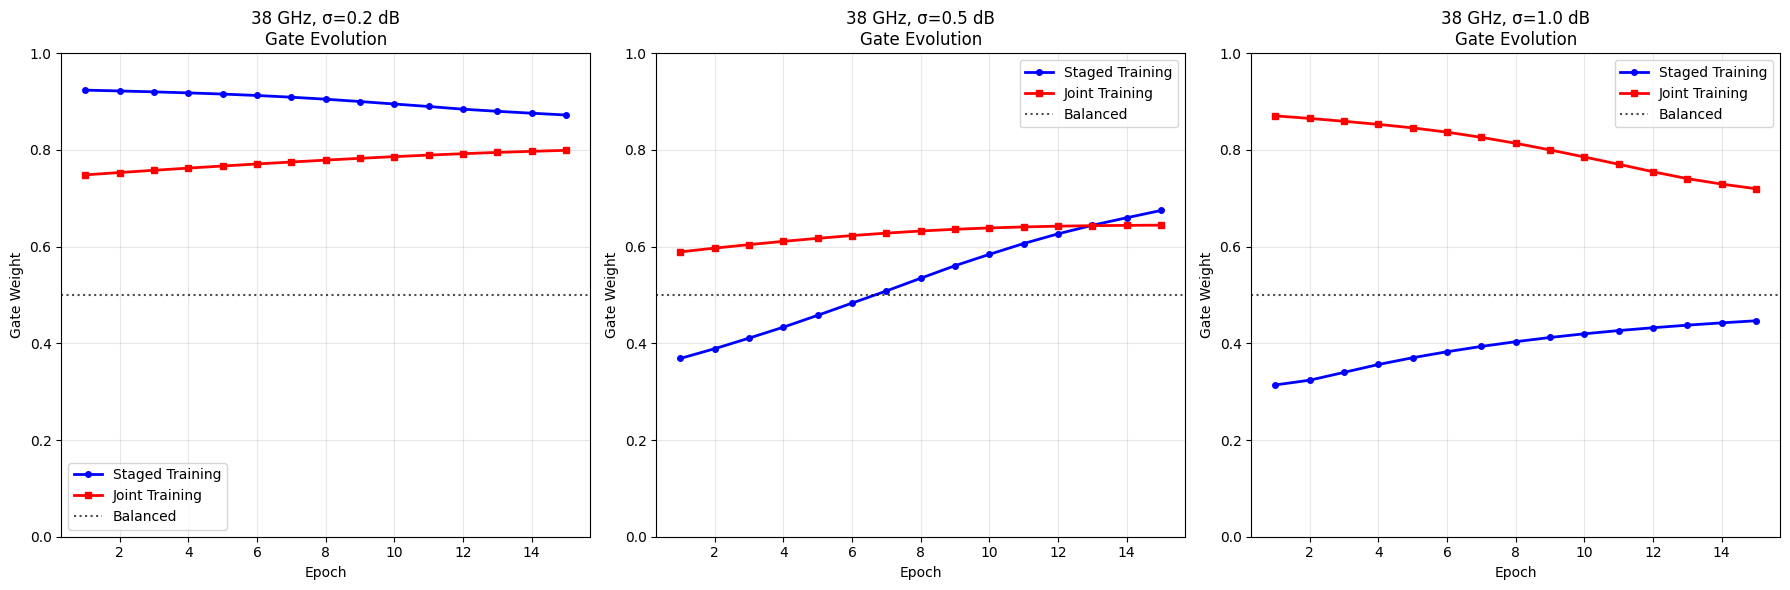


Detailed analysis for 38 GHz, σ=0.5 dB:


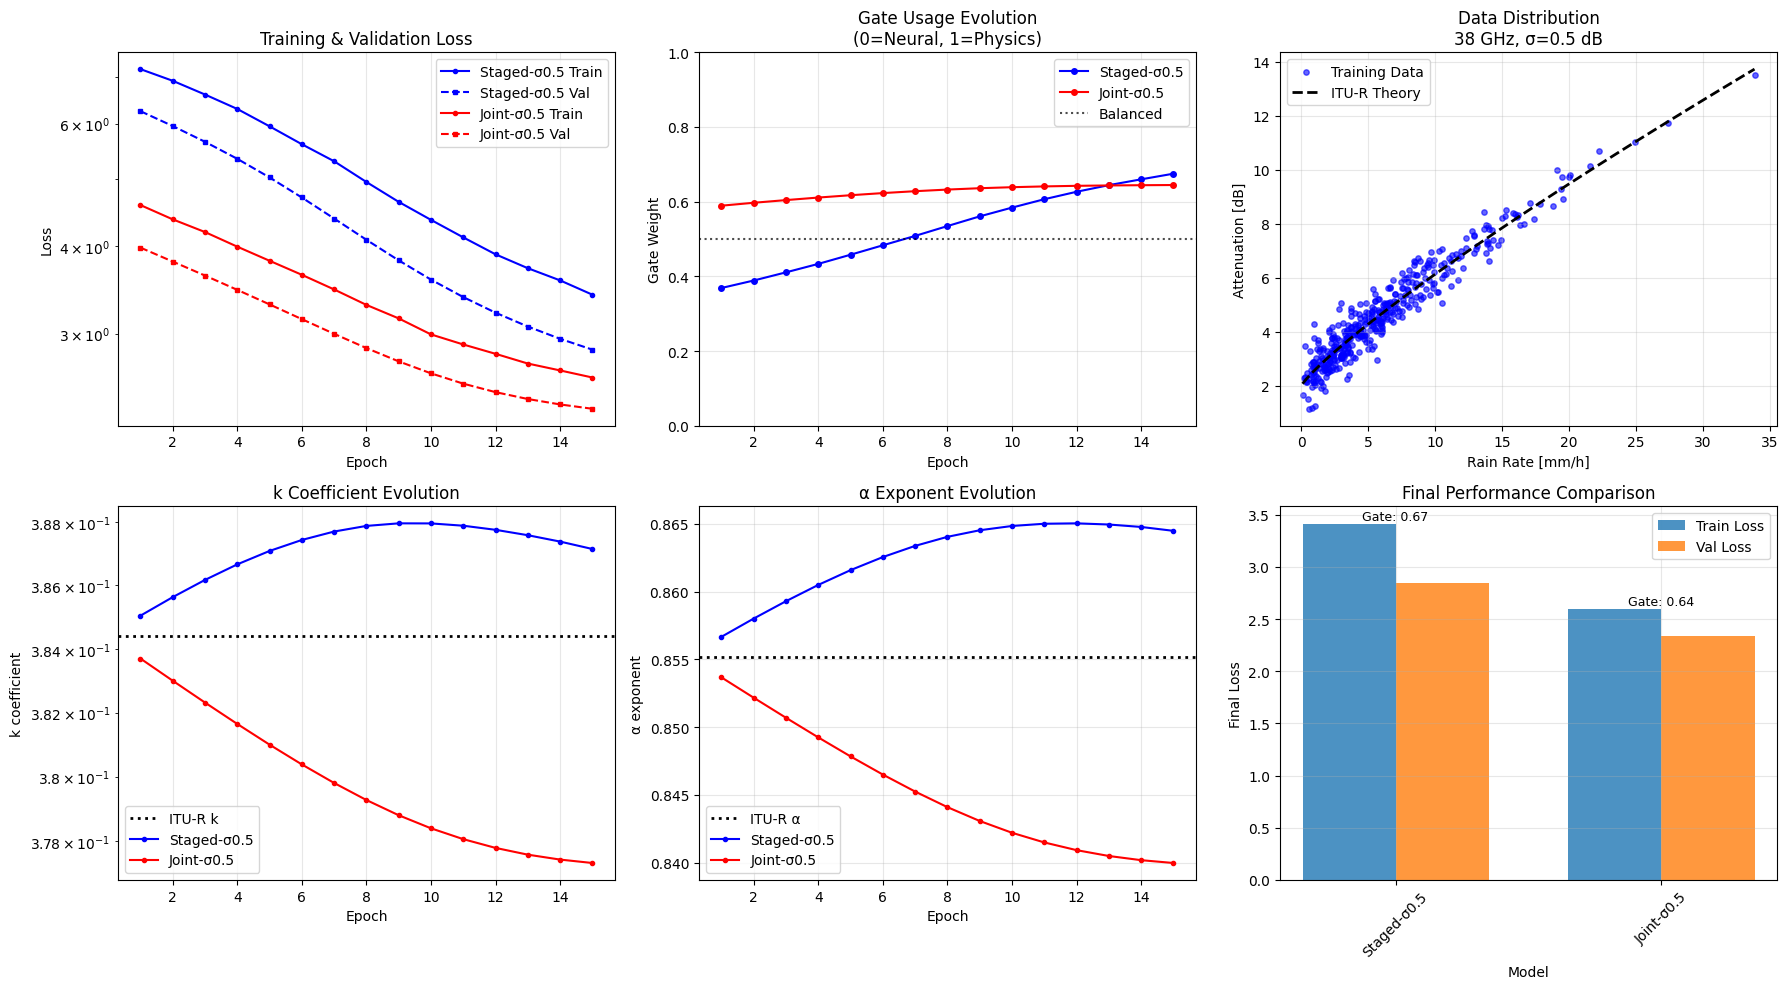


FINAL RESULTS SUMMARY - 38 GHz
Noise    Method       Train Loss   Val Loss     Gate Usage   k coeff      α       
--------------------------------------------------------------------------------
ITU-R    Reference    -            -            -            3.844e-01    0.855   
0.2      Staged       2.1704       2.1073       0.872        3.860e-01    0.853   
0.2      Joint        3.6557       3.8799       0.799        3.753e-01    0.835   
0.5      Staged       3.4106       2.8449       0.675        3.872e-01    0.864   
0.5      Joint        2.5949       2.3405       0.644        3.773e-01    0.840   
1.0      Staged       3.4790       3.4677       0.447        3.757e-01    0.835   
1.0      Joint        3.0898       3.2307       0.720        3.889e-01    0.866   
Gate Usage: 0=Neural dominant, 1=Physics dominant


In [ ]:
# ========= MULTI-NOISE TRAINING EXPERIMENT =========

# Select one frequency with multiple noise levels
EXPERIMENT_FREQ = 38  # Choose from available frequencies
EXPERIMENT_NOISE_LEVELS = [0.5, 3.0]  # Three noise levels

print(f"Running experiment on {EXPERIMENT_FREQ} GHz with noise levels: {EXPERIMENT_NOISE_LEVELS}")

# Generate datasets
exp_gen = RainAttenuationGenerator(seed=42)
exp_datasets = generate_datasets([EXPERIMENT_FREQ], EXPERIMENT_NOISE_LEVELS, 800, exp_gen)

# Train models for each noise level
all_trainers = []
dataset_keys = [f"{EXPERIMENT_FREQ}GHz_sigma{sigma}" for sigma in EXPERIMENT_NOISE_LEVELS]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (sigma, dataset_key) in enumerate(zip(EXPERIMENT_NOISE_LEVELS, dataset_keys)):
    print(f"\n{'='*60}")
    print(f"TRAINING ON {EXPERIMENT_FREQ} GHz, σ={sigma} dB")
    print('='*60)

    dataset = exp_datasets[dataset_key]

    # Create two models for comparison
    model_staged = create_hybrid_model(freq_ghz=EXPERIMENT_FREQ, pol="vertical", hidden_size=32)
    model_joint = create_hybrid_model(freq_ghz=EXPERIMENT_FREQ, pol="vertical", hidden_size=32)

    trainer_staged = VisualizingTrainer(model_staged, f"Staged-σ{sigma}", device=device)
    trainer_joint = VisualizingTrainer(model_joint, f"Joint-σ{sigma}", device=device)

    # Train both models
    trainer_staged.train_with_tracking(dataset, epochs=15, lr=1e-4, stage_name="Staged Training")
    trainer_joint.train_with_tracking(dataset, epochs=15, lr=1e-4, stage_name="Joint Training")

    # Plot gate usage evolution for this noise level
    ax = axes[idx]

    epochs_staged = range(1, len(trainer_staged.history['gate_usage']) + 1)
    epochs_joint = range(1, len(trainer_joint.history['gate_usage']) + 1)

    ax.plot(epochs_staged, trainer_staged.history['gate_usage'], 'b-o',
            label='Staged Training', markersize=4, linewidth=2)
    ax.plot(epochs_joint, trainer_joint.history['gate_usage'], 'r-s',
            label='Joint Training', markersize=4, linewidth=2)

    ax.axhline(y=0.5, color='black', linestyle=':', alpha=0.7, label='Balanced')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Gate Weight')
    ax.set_title(f'{EXPERIMENT_FREQ} GHz, σ={sigma} dB\nGate Evolution')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)

    all_trainers.extend([trainer_staged, trainer_joint])

plt.tight_layout()
plt.show()

# Comprehensive comparison plot for one noise level
print(f"\nDetailed analysis for {EXPERIMENT_FREQ} GHz, σ={EXPERIMENT_NOISE_LEVELS[1]} dB:")
middle_dataset = exp_datasets[f"{EXPERIMENT_FREQ}GHz_sigma{EXPERIMENT_NOISE_LEVELS[1]}"]
middle_trainers = [trainer for trainer in all_trainers if f"σ{EXPERIMENT_NOISE_LEVELS[1]}" in trainer.model_name]

plot_training_comparison(middle_trainers, middle_dataset)

# Summary table
print(f"\nFINAL RESULTS SUMMARY - {EXPERIMENT_FREQ} GHz")
print("="*80)
print(f"{'Noise':<8} {'Method':<12} {'Train Loss':<12} {'Val Loss':<12} {'Gate Usage':<12} {'k coeff':<12} {'α':<8}")
print("-"*80)

k_itu, alpha_itu = get_k_alpha(EXPERIMENT_FREQ, "vertical")
print(f"{'ITU-R':<8} {'Reference':<12} {'-':<12} {'-':<12} {'-':<12} {k_itu:<12.3e} {alpha_itu:<8.3f}")

for trainer in all_trainers:
    noise_level = trainer.model_name.split('σ')[1]
    method = trainer.model_name.split('-')[0]

    final_train = trainer.history['train_loss'][-1]
    final_val = trainer.history['val_loss'][-1]
    final_gate = trainer.history['gate_usage'][-1]
    final_k = trainer.history['k_values'][-1]
    final_alpha = trainer.history['alpha_values'][-1]

    print(f"{noise_level:<8} {method:<12} {final_train:<12.4f} {final_val:<12.4f} "
          f"{final_gate:<12.3f} {final_k:<12.3e} {final_alpha:<8.3f}")

print("="*80)
print("Gate Usage: 0=Neural dominant, 1=Physics dominant")

In [ ]:
# ========= MAIN EXECUTION =========
def main():
    """Generate datasets for specified frequencies and noise levels"""

    # Configuration
    FREQUENCIES = [5, 24, 28, 38, 60, 70]  # GHz
    NOISE_LEVELS = [0.01, 0.2,0.5, 0.7, 1.0]         # dB
    N_SAMPLES = 1000

    print("5G Rain Attenuation Data Generation")
    print("=" * 50)
    print(f"Frequencies: {FREQUENCIES} GHz")
    print(f"Noise levels: {NOISE_LEVELS} dB")
    print(f"Samples per configuration: {N_SAMPLES}")

    # Initialize generator
    gen = RainAttenuationGenerator(seed=42)

    # Storage for all datasets
    all_datasets = {}

    # Generate data for each frequency and noise combination
    print("\nGenerating datasets...")
    total_configs = len(FREQUENCIES) * len(NOISE_LEVELS)
    config_count = 0

    for freq in FREQUENCIES:
        for sigma in NOISE_LEVELS:
            config_count += 1

            # Get ITU coefficients
            k, alpha = get_k_alpha(freq, "vertical")
            rain_params = RainParams(k, alpha)

            # Generate data
            R_tr, R_te, A_tr, A_te = gen.generate_data(
                n_samples=N_SAMPLES,
                rain_params=rain_params,
                link_length_km=1.5,
                sigma_db=sigma,
                rain_sampler=lambda n: gen._rain_gamma(n, 1.5, 4.0),
                baseline_atten_db=2.0,
                test_size=0.3  # 70% train, 30% test
            )

            # Further split training into train/validation (80/20 of training data)
            R_train, R_val, A_train, A_val = train_test_split(
                R_tr, A_tr, test_size=0.15, random_state=42  # 20% of total = 25% of train
            )

            # Store dataset
            dataset_key = f"{freq}GHz_sigma{sigma}"
            all_datasets[dataset_key] = {
                'freq': freq,
                'sigma': sigma,
                'k': k,
                'alpha': alpha,
                'train': {'R': R_train, 'A': A_train},
                'val': {'R': R_val, 'A': A_val},
                'test': {'R': R_te, 'A': A_te}
            }

            print(f"[{config_count:2d}/{total_configs}] {freq} GHz, σ={sigma} dB: "
                  f"Train={len(R_train)}, Val={len(R_val)}, Test={len(R_te)}")

    # Plot results - each frequency gets its own row, each noise level gets a column
    print(f"\nCreating visualization: {len(FREQUENCIES)} frequencies x {len(NOISE_LEVELS)} noise levels...")

    fig, axes = plt.subplots(len(FREQUENCIES), len(NOISE_LEVELS), figsize=(15, 20))

    for freq_idx, freq in enumerate(FREQUENCIES):
        for noise_idx, sigma in enumerate(NOISE_LEVELS):
            ax = axes[freq_idx, noise_idx]

            dataset_key = f"{freq}GHz_sigma{sigma}"
            data = all_datasets[dataset_key]

            # Plot training data (subsample for clarity)
            R_plot = data['train']['R'][:1000]  # First 1000 points
            A_plot = data['train']['A'][:1000]

            # Swap axes: x=rain rate, y=attenuation
            ax.scatter(R_plot, A_plot, alpha=0.6, s=12, c='blue', label='Data')

            # Add theoretical curve (swapped axes)
            k, alpha = get_k_alpha(freq, "vertical")
            R_theory = np.linspace(0.1, np.max(R_plot), 200)
            A_theory = k * (R_theory ** alpha) * 1.5 + 2.0  # A = k*R^α*L + baseline

            ax.plot(R_theory, A_theory, '--k', linewidth=2, alpha=0.8,
                   label=f'ITU-R')

            ax.set_xlabel('Rain Rate [mm/h]', fontsize=11)
            ax.set_ylabel('Attenuation [dB]', fontsize=11)
            ax.set_title(f'{freq} GHz, σ={sigma} dB\n(k={k:.1e}, α={alpha:.3f})',
                        fontsize=11, fontweight='bold')
            ax.legend(fontsize=9)
            ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Summary table
    print(f"\nDataset Summary:")
    print("=" * 70)
    print(f"{'Freq':<8} {'Sigma':<8} {'k coeff':<12} {'α':<8} {'Train':<8} {'Val':<8} {'Test':<8}")
    print("-" * 70)

    for freq in FREQUENCIES:
        for sigma in NOISE_LEVELS:
            dataset_key = f"{freq}GHz_sigma{sigma}"
            data = all_datasets[dataset_key]
            print(f"{freq:<8} {sigma:<8} {data['k']:<12.2e} {data['alpha']:<8.3f} "
                  f"{len(data['train']['R']):<8} {len(data['val']['R']):<8} {len(data['test']['R']):<8}")

    print("=" * 70)

    return all_datasets


if __name__ == "__main__":
    datasets = main()

5G Rain Attenuation Data Generation
Frequencies: [5, 24, 28, 38, 60, 70] GHz
Noise levels: [0.01, 0.2, 0.5, 0.7, 1.0] dB
Samples per configuration: 1000

Generating datasets...


ValueError: too many values to unpack (expected 4)

In [ ]:
# @title
"""
Data Generation Module for Rain Attenuation Analysis
Focus: Generate clean datasets for multiple frequency bands
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from enum import Enum
from typing import Dict, Tuple, Optional, List
from sklearn.model_selection import train_test_split

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


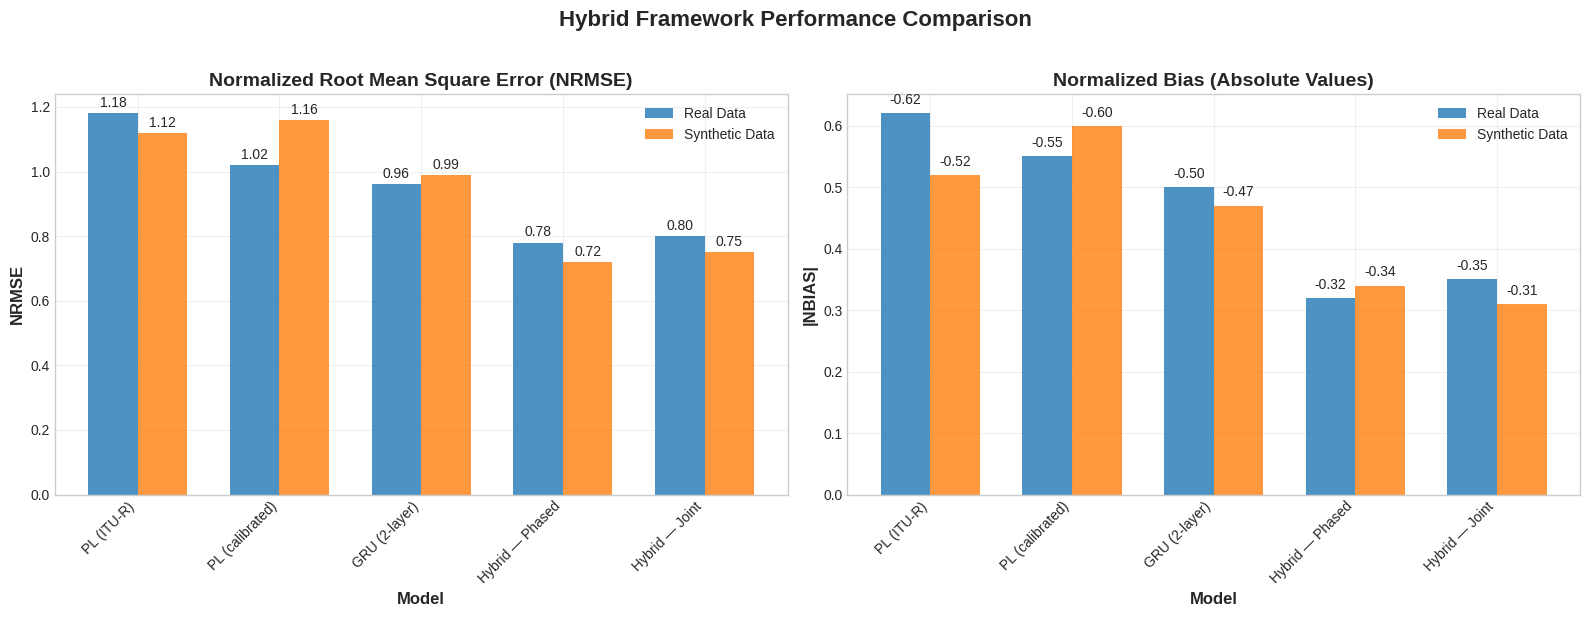

PERFORMANCE SUMMARY

Detailed Performance Metrics:
          Model  Real_NRMSE  Synthetic_NRMSE  Real_NBIAS  Synthetic_NBIAS
     PL (ITU-R)       1.180            1.120      -0.620           -0.520
PL (calibrated)       1.020            1.160      -0.550           -0.600
  GRU (2-layer)       0.960            0.990      -0.500           -0.470
Hybrid — Phased       0.780            0.720      -0.320           -0.340
 Hybrid — Joint       0.800            0.750      -0.350           -0.310

Best NRMSE Performance:
  Real Data: Hybrid — Phased (0.780)
  Synthetic Data: Hybrid — Phased (0.720)

Best NBIAS Performance (closest to zero):
  Real Data: Hybrid — Phased (-0.320)
  Synthetic Data: Hybrid — Joint (-0.310)

PERFORMANCE IMPROVEMENT ANALYSIS

NRMSE Improvement vs ITU-R Baseline:
  PL (calibrated)     : Real  +13.6%, Synthetic   -3.6%
  GRU (2-layer)       : Real  +18.6%, Synthetic  +11.6%
  Hybrid — Phased     : Real  +33.9%, Synthetic  +35.7%
  Hybrid — Joint      : Real  +32.2%, 

In [1]:
# @title
# Hybrid Framework Performance Analysis
# Professional visualization of model performance on Real vs Synthetic data

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set professional style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Data from the table (excluding Gate-Only as requested)
models = ['PL (ITU-R)', 'PL (calibrated)', 'GRU (2-layer)', 'Hybrid — Phased', 'Hybrid — Joint']

# Performance metrics
real_nrmse = [1.18, 1.02, 0.96, 0.78, 0.80]
synthetic_nrmse = [1.12, 1.16, 0.99, 0.72, 0.75]

real_nbias = [-0.62, -0.55, -0.50, -0.32, -0.35]
synthetic_nbias = [-0.52, -0.60, -0.47, -0.34, -0.31]

# Create DataFrame for easier plotting
data = {
    'Model': models * 2,
    'Data Type': ['Real'] * 5 + ['Synthetic'] * 5,
    'NRMSE': real_nrmse + synthetic_nrmse,
    'NBIAS': real_nbias + synthetic_nbias
}
df = pd.DataFrame(data)

# Set up the figure with subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Hybrid Framework Performance Comparison', fontsize=16, fontweight='bold', y=1.02)

# Color palette for better distinction
colors = ['#1f77b4', '#ff7f0e']  # Blue for Real, Orange for Synthetic

# Plot 1: NRMSE Comparison
x_pos = np.arange(len(models))
width = 0.35

bars1 = ax1.bar(x_pos - width/2, real_nrmse, width, label='Real Data', color=colors[0], alpha=0.8)
bars2 = ax1.bar(x_pos + width/2, synthetic_nrmse, width, label='Synthetic Data', color=colors[1], alpha=0.8)

ax1.set_xlabel('Model', fontweight='bold', fontsize=12)
ax1.set_ylabel('NRMSE', fontweight='bold', fontsize=12)
ax1.set_title('Normalized Root Mean Square Error (NRMSE)', fontweight='bold', fontsize=14)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(models, rotation=45, ha='right')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.2f}', ha='center', va='bottom', fontsize=10)

for bar in bars2:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.2f}', ha='center', va='bottom', fontsize=10)

# Plot 2: NBIAS Comparison (using absolute values for better visualization)
abs_real_nbias = [abs(x) for x in real_nbias]
abs_synthetic_nbias = [abs(x) for x in synthetic_nbias]

bars3 = ax2.bar(x_pos - width/2, abs_real_nbias, width, label='Real Data', color=colors[0], alpha=0.8)
bars4 = ax2.bar(x_pos + width/2, abs_synthetic_nbias, width, label='Synthetic Data', color=colors[1], alpha=0.8)

ax2.set_xlabel('Model', fontweight='bold', fontsize=12)
ax2.set_ylabel('|NBIAS|', fontweight='bold', fontsize=12)
ax2.set_title('Normalized Bias (Absolute Values)', fontweight='bold', fontsize=14)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(models, rotation=45, ha='right')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

# Add value labels on bars (showing original negative values)
for i, bar in enumerate(bars3):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{real_nbias[i]:.2f}', ha='center', va='bottom', fontsize=10)

for i, bar in enumerate(bars4):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{synthetic_nbias[i]:.2f}', ha='center', va='bottom', fontsize=10)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

# Print summary statistics
print("="*60)
print("PERFORMANCE SUMMARY")
print("="*60)

# Create summary table
summary_df = pd.DataFrame({
    'Model': models,
    'Real_NRMSE': real_nrmse,
    'Synthetic_NRMSE': synthetic_nrmse,
    'Real_NBIAS': real_nbias,
    'Synthetic_NBIAS': synthetic_nbias
})

print("\nDetailed Performance Metrics:")
print(summary_df.to_string(index=False, float_format='%.3f'))

# Find best performing models
print(f"\nBest NRMSE Performance:")
print(f"  Real Data: {models[np.argmin(real_nrmse)]} ({min(real_nrmse):.3f})")
print(f"  Synthetic Data: {models[np.argmin(synthetic_nrmse)]} ({min(synthetic_nrmse):.3f})")

print(f"\nBest NBIAS Performance (closest to zero):")
real_best_bias_idx = np.argmin([abs(x) for x in real_nbias])
synthetic_best_bias_idx = np.argmin([abs(x) for x in synthetic_nbias])
print(f"  Real Data: {models[real_best_bias_idx]} ({real_nbias[real_best_bias_idx]:.3f})")
print(f"  Synthetic Data: {models[synthetic_best_bias_idx]} ({synthetic_nbias[synthetic_best_bias_idx]:.3f})")

# Additional analysis: Performance improvement
print(f"\n" + "="*60)
print("PERFORMANCE IMPROVEMENT ANALYSIS")
print("="*60)

baseline_real_nrmse = real_nrmse[0]  # ITU-R baseline
baseline_synthetic_nrmse = synthetic_nrmse[0]

print("\nNRMSE Improvement vs ITU-R Baseline:")
for i, model in enumerate(models[1:], 1):
    real_improvement = ((baseline_real_nrmse - real_nrmse[i]) / baseline_real_nrmse) * 100
    synthetic_improvement = ((baseline_synthetic_nrmse - synthetic_nrmse[i]) / baseline_synthetic_nrmse) * 100
    print(f"  {model:20s}: Real {real_improvement:+6.1f}%, Synthetic {synthetic_improvement:+6.1f}%")

In [2]:
# @title
# Create bar plots for the provided table results
import matplotlib.pyplot as plt
import pandas as pd
from textwrap import wrap

# Data from the user's table
models = [
    "PL (ITU-R)",
    "PL (calibrated)",
    "GRU (2-layer)",
    "Hybrid — Gate-Only",
    "Hybrid — Phased",
    "Hybrid — Joint",
]

real_nrmse = [1.18, 1.02, 0.96, 0.88, 0.78, 0.80]
real_nbias = [-0.62, -0.55, -0.50, -0.42, -0.32, -0.35]
real_g     = [None, None, None, 0.42, 0.31, 0.35]

syn_nrmse  = [1.12, 1.16, 0.99, 0.84, 0.72, 0.75]
syn_nbias  = [-0.52, -0.60, -0.47, -0.29, -0.34, -0.31]
syn_g      = [None, None, None, 0.40, 0.46, 0.59]

# Put in a DataFrame for clarity (and potential display)
df = pd.DataFrame({
    "Model": models,
    "Real_NRMSE": real_nrmse,
    "Real_NBIAS": real_nbias,
    "Real_g": real_g,
    "Synthetic_NRMSE": syn_nrmse,
    "Synthetic_NBIAS": syn_nbias,
    "Synthetic_g": syn_g,
})
df



,Model,Real_NRMSE,Real_NBIAS,Real_g,Synthetic_NRMSE,Synthetic_NBIAS,Synthetic_g
0,PL (ITU-R),1.18,-0.62,NaN,1.12,-0.52,NaN
1,PL (calibrated),1.02,-0.55,NaN,1.16,-0.60,NaN
2,GRU (2-layer),0.96,-0.50,NaN,0.99,-0.47,NaN
3,Hybrid — Gate-Only,0.88,-0.42,0.42,0.84,-0.29,0.40
4,Hybrid — Phased,0.78,-0.32,0.31,0.72,-0.34,0.46
5,Hybrid — Joint,0.80,-0.35,0.35,0.75,-0.31,0.59


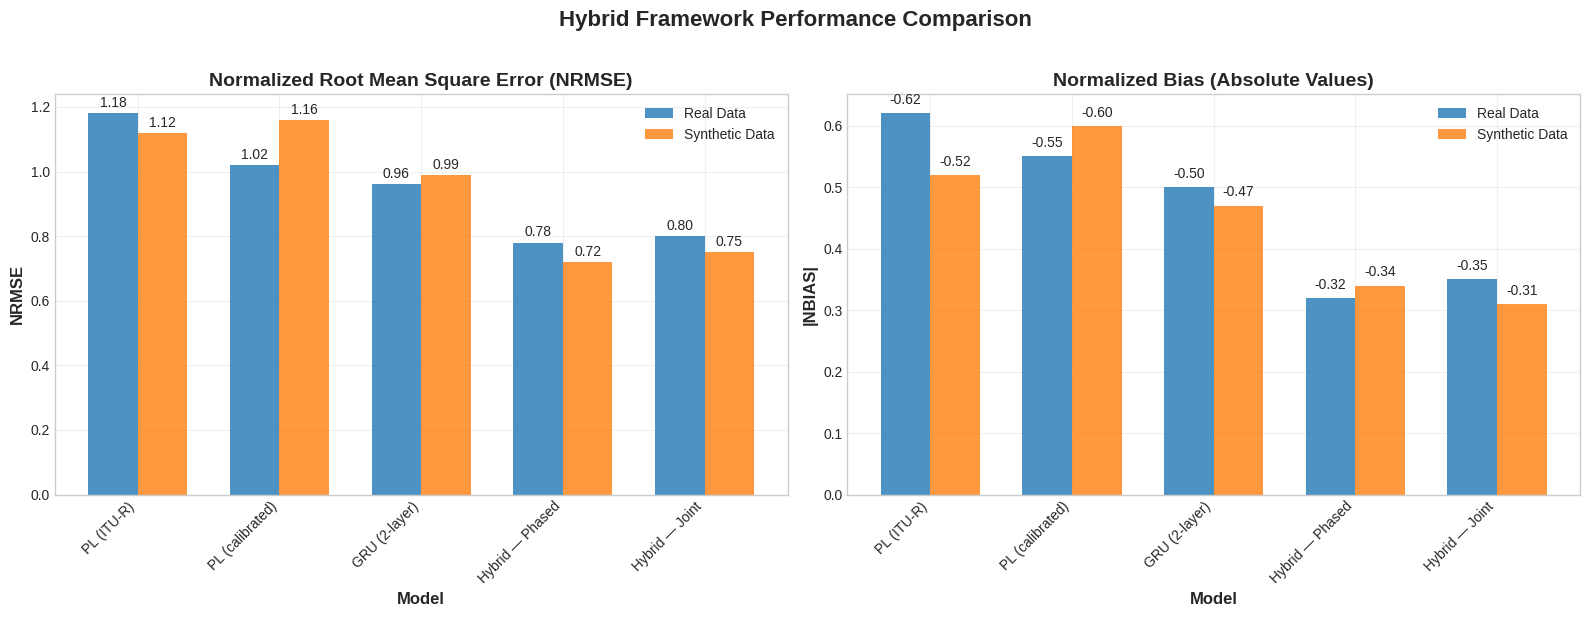

PERFORMANCE SUMMARY

Detailed Performance Metrics:
          Model  Real_NRMSE  Synthetic_NRMSE  Real_NBIAS  Synthetic_NBIAS
     PL (ITU-R)       1.180            1.120      -0.620           -0.520
PL (calibrated)       1.020            1.160      -0.550           -0.600
  GRU (2-layer)       0.960            0.990      -0.500           -0.470
Hybrid — Phased       0.780            0.720      -0.320           -0.340
 Hybrid — Joint       0.800            0.750      -0.350           -0.310

Best NRMSE Performance:
  Real Data: Hybrid — Phased (0.780)
  Synthetic Data: Hybrid — Phased (0.720)

Best NBIAS Performance (closest to zero):
  Real Data: Hybrid — Phased (-0.320)
  Synthetic Data: Hybrid — Joint (-0.310)

PERFORMANCE IMPROVEMENT ANALYSIS

NRMSE Improvement vs ITU-R Baseline:
  PL (calibrated)     : Real  +13.6%, Synthetic   -3.6%
  GRU (2-layer)       : Real  +18.6%, Synthetic  +11.6%
  Hybrid — Phased     : Real  +33.9%, Synthetic  +35.7%
  Hybrid — Joint      : Real  +32.2%, 

In [3]:
# @title
# Hybrid Framework Performance Analysis
# Professional visualization of model performance on Real vs Synthetic data

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set professional style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Data from the table (excluding Gate-Only as requested)
models = ['PL (ITU-R)', 'PL (calibrated)', 'GRU (2-layer)', 'Hybrid — Phased', 'Hybrid — Joint']

# Performance metrics
real_nrmse = [1.18, 1.02, 0.96, 0.78, 0.80]
synthetic_nrmse = [1.12, 1.16, 0.99, 0.72, 0.75]

real_nbias = [-0.62, -0.55, -0.50, -0.32, -0.35]
synthetic_nbias = [-0.52, -0.60, -0.47, -0.34, -0.31]

# Create DataFrame for easier plotting
data = {
    'Model': models * 2,
    'Data Type': ['Real'] * 5 + ['Synthetic'] * 5,
    'NRMSE': real_nrmse + synthetic_nrmse,
    'NBIAS': real_nbias + synthetic_nbias
}
df = pd.DataFrame(data)

# Set up the figure with subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Hybrid Framework Performance Comparison', fontsize=16, fontweight='bold', y=1.02)

# Color palette for better distinction
colors = ['#1f77b4', '#ff7f0e']  # Blue for Real, Orange for Synthetic

# Plot 1: NRMSE Comparison
x_pos = np.arange(len(models))
width = 0.35

bars1 = ax1.bar(x_pos - width/2, real_nrmse, width, label='Real Data', color=colors[0], alpha=0.8)
bars2 = ax1.bar(x_pos + width/2, synthetic_nrmse, width, label='Synthetic Data', color=colors[1], alpha=0.8)

ax1.set_xlabel('Model', fontweight='bold', fontsize=12)
ax1.set_ylabel('NRMSE', fontweight='bold', fontsize=12)
ax1.set_title('Normalized Root Mean Square Error (NRMSE)', fontweight='bold', fontsize=14)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(models, rotation=45, ha='right')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.2f}', ha='center', va='bottom', fontsize=10)

for bar in bars2:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.2f}', ha='center', va='bottom', fontsize=10)

# Plot 2: NBIAS Comparison (using absolute values for better visualization)
abs_real_nbias = [abs(x) for x in real_nbias]
abs_synthetic_nbias = [abs(x) for x in synthetic_nbias]

bars3 = ax2.bar(x_pos - width/2, abs_real_nbias, width, label='Real Data', color=colors[0], alpha=0.8)
bars4 = ax2.bar(x_pos + width/2, abs_synthetic_nbias, width, label='Synthetic Data', color=colors[1], alpha=0.8)

ax2.set_xlabel('Model', fontweight='bold', fontsize=12)
ax2.set_ylabel('|NBIAS|', fontweight='bold', fontsize=12)
ax2.set_title('Normalized Bias (Absolute Values)', fontweight='bold', fontsize=14)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(models, rotation=45, ha='right')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

# Add value labels on bars (showing original negative values)
for i, bar in enumerate(bars3):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{real_nbias[i]:.2f}', ha='center', va='bottom', fontsize=10)

for i, bar in enumerate(bars4):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{synthetic_nbias[i]:.2f}', ha='center', va='bottom', fontsize=10)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

# Print summary statistics
print("="*60)
print("PERFORMANCE SUMMARY")
print("="*60)

# Create summary table
summary_df = pd.DataFrame({
    'Model': models,
    'Real_NRMSE': real_nrmse,
    'Synthetic_NRMSE': synthetic_nrmse,
    'Real_NBIAS': real_nbias,
    'Synthetic_NBIAS': synthetic_nbias
})

print("\nDetailed Performance Metrics:")
print(summary_df.to_string(index=False, float_format='%.3f'))

# Find best performing models
print(f"\nBest NRMSE Performance:")
print(f"  Real Data: {models[np.argmin(real_nrmse)]} ({min(real_nrmse):.3f})")
print(f"  Synthetic Data: {models[np.argmin(synthetic_nrmse)]} ({min(synthetic_nrmse):.3f})")

print(f"\nBest NBIAS Performance (closest to zero):")
real_best_bias_idx = np.argmin([abs(x) for x in real_nbias])
synthetic_best_bias_idx = np.argmin([abs(x) for x in synthetic_nbias])
print(f"  Real Data: {models[real_best_bias_idx]} ({real_nbias[real_best_bias_idx]:.3f})")
print(f"  Synthetic Data: {models[synthetic_best_bias_idx]} ({synthetic_nbias[synthetic_best_bias_idx]:.3f})")

# Additional analysis: Performance improvement
print(f"\n" + "="*60)
print("PERFORMANCE IMPROVEMENT ANALYSIS")
print("="*60)

baseline_real_nrmse = real_nrmse[0]  # ITU-R baseline
baseline_synthetic_nrmse = synthetic_nrmse[0]

print("\nNRMSE Improvement vs ITU-R Baseline:")
for i, model in enumerate(models[1:], 1):
    real_improvement = ((baseline_real_nrmse - real_nrmse[i]) / baseline_real_nrmse) * 100
    synthetic_improvement = ((baseline_synthetic_nrmse - synthetic_nrmse[i]) / baseline_synthetic_nrmse) * 100
    print(f"  {model:20s}: Real {real_improvement:+6.1f}%, Synthetic {synthetic_improvement:+6.1f}%")

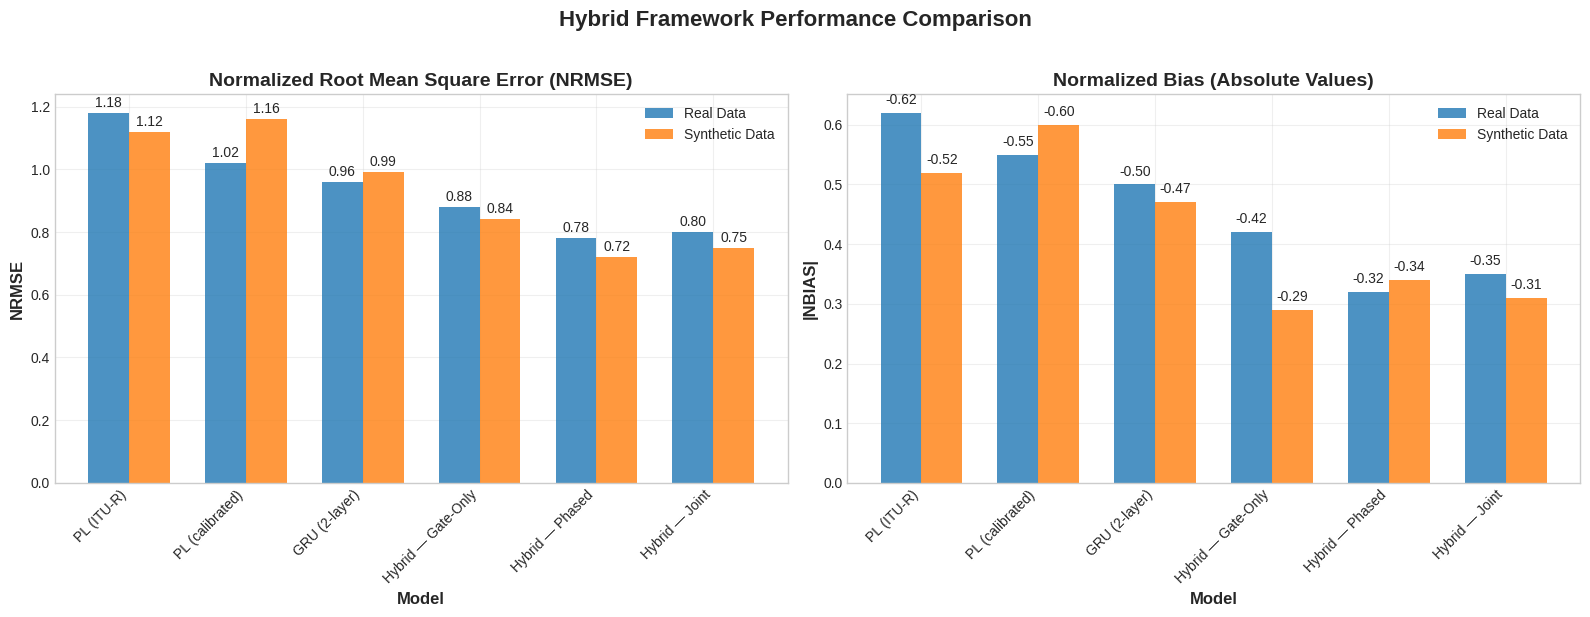

PERFORMANCE SUMMARY

Detailed Performance Metrics:
             Model  Real_NRMSE  Synthetic_NRMSE  Real_NBIAS  Synthetic_NBIAS
        PL (ITU-R)       1.180            1.120      -0.620           -0.520
   PL (calibrated)       1.020            1.160      -0.550           -0.600
     GRU (2-layer)       0.960            0.990      -0.500           -0.470
Hybrid — Gate-Only       0.880            0.840      -0.420           -0.290
   Hybrid — Phased       0.780            0.720      -0.320           -0.340
    Hybrid — Joint       0.800            0.750      -0.350           -0.310

Best NRMSE Performance:
  Real Data: Hybrid — Phased (0.780)
  Synthetic Data: Hybrid — Phased (0.720)

Best NBIAS Performance (closest to zero):
  Real Data: Hybrid — Phased (-0.320)
  Synthetic Data: Hybrid — Gate-Only (-0.290)

PERFORMANCE IMPROVEMENT ANALYSIS

NRMSE Improvement vs ITU-R Baseline:
  PL (calibrated)     : Real  +13.6%, Synthetic   -3.6%
  GRU (2-layer)       : Real  +18.6%, Synthetic  +1

In [4]:
# @title
# Hybrid Framework Performance Analysis
# Professional visualization of model performance on Real vs Synthetic data

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set professional style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Data from the table (including all models)
models = ['PL (ITU-R)', 'PL (calibrated)', 'GRU (2-layer)', 'Hybrid — Gate-Only', 'Hybrid — Phased', 'Hybrid — Joint']

# Performance metrics
real_nrmse = [1.18, 1.02, 0.96, 0.88, 0.78, 0.80]
synthetic_nrmse = [1.12, 1.16, 0.99, 0.84, 0.72, 0.75]

real_nbias = [-0.62, -0.55, -0.50, -0.42, -0.32, -0.35]
synthetic_nbias = [-0.52, -0.60, -0.47, -0.29, -0.34, -0.31]

# Create DataFrame for easier plotting
data = {
    'Model': models * 2,
    'Data Type': ['Real'] * 6 + ['Synthetic'] * 6,
    'NRMSE': real_nrmse + synthetic_nrmse,
    'NBIAS': real_nbias + synthetic_nbias
}
df = pd.DataFrame(data)

# Set up the figure with subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Hybrid Framework Performance Comparison', fontsize=16, fontweight='bold', y=1.02)

# Color palette for better distinction
colors = ['#1f77b4', '#ff7f0e']  # Blue for Real, Orange for Synthetic

# Plot 1: NRMSE Comparison
x_pos = np.arange(len(models))
width = 0.35

bars1 = ax1.bar(x_pos - width/2, real_nrmse, width, label='Real Data', color=colors[0], alpha=0.8)
bars2 = ax1.bar(x_pos + width/2, synthetic_nrmse, width, label='Synthetic Data', color=colors[1], alpha=0.8)

ax1.set_xlabel('Model', fontweight='bold', fontsize=12)
ax1.set_ylabel('NRMSE', fontweight='bold', fontsize=12)
ax1.set_title('Normalized Root Mean Square Error (NRMSE)', fontweight='bold', fontsize=14)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(models, rotation=45, ha='right')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.2f}', ha='center', va='bottom', fontsize=10)

for bar in bars2:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.2f}', ha='center', va='bottom', fontsize=10)

# Plot 2: NBIAS Comparison (using absolute values for better visualization)
abs_real_nbias = [abs(x) for x in real_nbias]
abs_synthetic_nbias = [abs(x) for x in synthetic_nbias]

bars3 = ax2.bar(x_pos - width/2, abs_real_nbias, width, label='Real Data', color=colors[0], alpha=0.8)
bars4 = ax2.bar(x_pos + width/2, abs_synthetic_nbias, width, label='Synthetic Data', color=colors[1], alpha=0.8)

ax2.set_xlabel('Model', fontweight='bold', fontsize=12)
ax2.set_ylabel('|NBIAS|', fontweight='bold', fontsize=12)
ax2.set_title('Normalized Bias (Absolute Values)', fontweight='bold', fontsize=14)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(models, rotation=45, ha='right')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

# Add value labels on bars (showing original negative values)
for i, bar in enumerate(bars3):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{real_nbias[i]:.2f}', ha='center', va='bottom', fontsize=10)

for i, bar in enumerate(bars4):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{synthetic_nbias[i]:.2f}', ha='center', va='bottom', fontsize=10)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

# Print summary statistics
print("="*60)
print("PERFORMANCE SUMMARY")
print("="*60)

# Create summary table
summary_df = pd.DataFrame({
    'Model': models,
    'Real_NRMSE': real_nrmse,
    'Synthetic_NRMSE': synthetic_nrmse,
    'Real_NBIAS': real_nbias,
    'Synthetic_NBIAS': synthetic_nbias
})

print("\nDetailed Performance Metrics:")
print(summary_df.to_string(index=False, float_format='%.3f'))

# Find best performing models
print(f"\nBest NRMSE Performance:")
print(f"  Real Data: {models[np.argmin(real_nrmse)]} ({min(real_nrmse):.3f})")
print(f"  Synthetic Data: {models[np.argmin(synthetic_nrmse)]} ({min(synthetic_nrmse):.3f})")

print(f"\nBest NBIAS Performance (closest to zero):")
real_best_bias_idx = np.argmin([abs(x) for x in real_nbias])
synthetic_best_bias_idx = np.argmin([abs(x) for x in synthetic_nbias])
print(f"  Real Data: {models[real_best_bias_idx]} ({real_nbias[real_best_bias_idx]:.3f})")
print(f"  Synthetic Data: {models[synthetic_best_bias_idx]} ({synthetic_nbias[synthetic_best_bias_idx]:.3f})")

# Additional analysis: Performance improvement
print(f"\n" + "="*60)
print("PERFORMANCE IMPROVEMENT ANALYSIS")
print("="*60)

baseline_real_nrmse = real_nrmse[0]  # ITU-R baseline
baseline_synthetic_nrmse = synthetic_nrmse[0]

print("\nNRMSE Improvement vs ITU-R Baseline:")
for i, model in enumerate(models[1:], 1):
    real_improvement = ((baseline_real_nrmse - real_nrmse[i]) / baseline_real_nrmse) * 100
    synthetic_improvement = ((baseline_synthetic_nrmse - synthetic_nrmse[i]) / baseline_synthetic_nrmse) * 100
    print(f"  {model:20s}: Real {real_improvement:+6.1f}%, Synthetic {synthetic_improvement:+6.1f}%")

In [ ]:
# assume RainAttenuationGenerator, rain_params_from_itu and the rest have been defined
gen = RainAttenuationGenerator(seed=42)

for f in [5, 24, 60, 70]:
    rp = rain_params_from_itu(f, pol="vertical")   # ← ITU-R P.838, V-pol
    gen.plot_noise_comparison(
        sigma_vals=[0.01, 0.20, 1.00],
        rain_params=rp,
        link_length_km=1.0,
        freq_ghz=f,
        n_samples=2_000,
        rain_sampler=lambda n: gen._rain_gamma(n, shape=1.5, scale=4.0)  # Gamma rain cloud
    )


AttributeError: 'RainAttenuationGenerator' object has no attribute 'plot_noise_comparison'

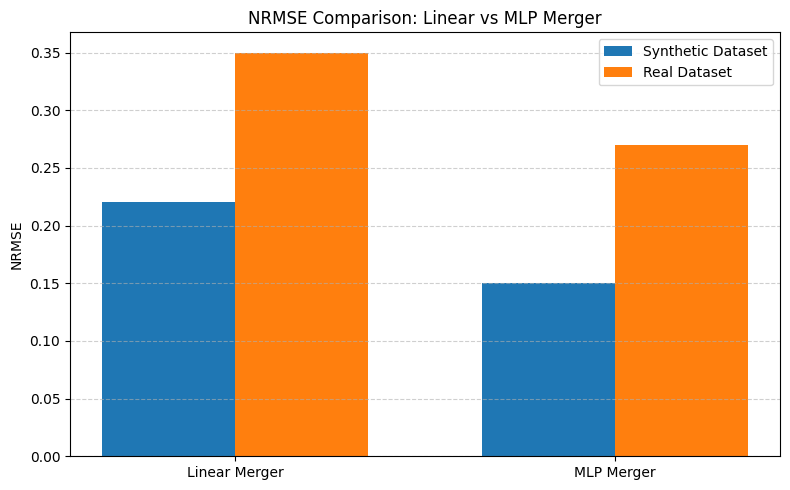

In [ ]:
# @title
import matplotlib.pyplot as plt
import numpy as np

def plot_final_metrics_comparison():
    # Performance metrics (example values)
    methods = ['Linear Merger', 'MLP Merger']
    nrmse_synthetic = [0.22, 0.15]  # NRMSE for synthetic dataset
    nrmse_real = [0.35, 0.27]       # NRMSE for real dataset

    # Plot
    x = np.arange(len(methods))
    width = 0.35

    plt.figure(figsize=(8, 5))
    plt.bar(x - width/2, nrmse_synthetic, width, label='Synthetic Dataset', color='tab:blue')
    plt.bar(x + width/2, nrmse_real, width, label='Real Dataset', color='tab:orange')

    plt.xticks(x, methods)
    plt.ylabel('NRMSE')
    plt.title('NRMSE Comparison: Linear vs MLP Merger')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Call function
plot_final_metrics_comparison()


In [ ]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


ITU-R Coeff + Reading function

In [ ]:
# @title
"""
Hybrid Rain Rate Estimation Model - Integrated with RainAttenuationGenerator
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Dict, Tuple, Optional, List
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from enum import Enum

# Your existing imports
from sklearn.model_selection import train_test_split


# ITU-R P.838 coefficients table
ITU_P838_TABLE = {
    "horizontal": {
        1: (2.59e-5, 0.9691), 1.5: (4.43e-5, 1.0185), 2: (8.47e-5, 1.0664),
        2.5: (1.321e-4, 1.1209), 3: (1.390e-4, 1.2322), 3.5: (1.155e-4, 1.4189),
        4: (8.24e-5, 1.5317), 4.5: (5.75e-5, 1.6320), 5: (4.55e-5, 1.7235),
        6: (3.78e-5, 1.8673), 7: (3.45e-5, 1.9801), 8: (3.26e-5, 2.0728),
        9: (3.13e-5, 2.1518), 10: (3.05e-5, 2.2206), 12: (2.96e-5, 2.3441),
        15: (2.89e-5, 2.4904), 20: (2.84e-5, 2.6454), 25: (2.81e-5, 2.7616),
        30: (2.79e-5, 2.8539), 35: (2.78e-5, 2.9305), 40: (2.77e-5, 2.9957),
        45: (2.76e-5, 3.0523), 50: (2.76e-5, 3.1017), 60: (2.75e-5, 3.1875),
        70: (2.74e-5, 3.2590), 80: (2.74e-5, 3.3188), 90: (2.73e-5, 3.3699),
        100: (2.73e-5, 3.4147)
    },
    "vertical": {
        1: (9.29e-6, 0.8957), 1.5: (1.67e-5, 0.9490), 2: (3.05e-5, 1.0002),
        2.5: (5.48e-5, 1.0497), 3: (9.65e-5, 1.0966), 3.5: (1.66e-4, 1.1408),
        4: (2.78e-4, 1.1827), 4.5: (4.54e-4, 1.2223), 5: (7.24e-4, 1.2597),
        6: (1.73e-3, 1.3297), 7: (3.92e-3, 1.3939), 8: (8.40e-3, 1.4538),
        9: (1.75e-2, 1.5096), 10: (3.45e-2, 1.5617), 12: (1.24e-1, 1.6589),
        15: (4.70e-1, 1.7871), 20: (1.75, 1.9535), 25: (4.68, 2.0776),
        30: (1.05e1, 2.1774), 35: (2.07e1, 2.2593), 40: (3.64e1, 2.3285),
        45: (5.93e1, 2.3881), 50: (9.08e1, 2.4402), 60: (1.85e2, 2.5317),
        70: (3.31e2, 2.6069), 80: (5.40e2, 2.6707), 90: (8.21e2, 2.7265),
        100: (1.20e3, 2.7767)
    }
}

def get_k_alpha(freq_ghz: float, pol: str = "horizontal") -> Tuple[float, float]:
    """Get ITU-R coefficients with linear interpolation"""
    if pol not in ITU_P838_TABLE:
        raise ValueError(f"Polarization must be 'horizontal' or 'vertical', got '{pol}'")

    table = ITU_P838_TABLE[pol]
    freqs = sorted(table.keys())

    # Handle boundary cases
    if freq_ghz <= freqs[0]:
        return table[freqs[0]]
    if freq_ghz >= freqs[-1]:
        return table[freqs[-1]]

    # Linear interpolation
    for i in range(len(freqs) - 1):
        f1, f2 = freqs[i], freqs[i + 1]
        if f1 <= freq_ghz <= f2:
            k1, alpha1 = table[f1]
            k2, alpha2 = table[f2]

            # Interpolate in log space for k
            log_k = np.interp(freq_ghz, [f1, f2], [np.log(k1), np.log(k2)])
            alpha = np.interp(freq_ghz, [f1, f2], [alpha1, alpha2])

            return np.exp(log_k), alpha

    raise ValueError(f"Frequency {freq_ghz} GHz not found in table")


# Your existing generator classes (simplified version)
class NoiseType(Enum):
    NORMAL = "normal"
    LOGNORMAL = "lognormal"
    GAMMA = "gamma"
    UNIFORM = "uniform"

@dataclass
class RainParams:
    a_coeff: float
    b_exponent: float
    rain_range: Tuple[float, float] = (0.1, 30.0)

class RainAttenuationGenerator:
    def __init__(self, seed: Optional[int] = None):
        self.rng = np.random.default_rng(seed)

    def _noise(self, n: int, kind: NoiseType, sigma: float) -> np.ndarray:
        r = self.rng
        if kind is NoiseType.NORMAL:
            return r.normal(0, sigma, n)
        # Add other noise types as needed...
        return r.normal(0, sigma, n)

    def _rain_uniform(self, n: int, rp: RainParams) -> np.ndarray:
        lo, hi = rp.rain_range
        return self.rng.uniform(lo, hi, n)

    def _rain_gamma(self, n: int, shape=1.5, scale=4.0) -> np.ndarray:
        return np.clip(self.rng.gamma(shape, scale, n), 0.01, None)

    def generate_data(
        self,
        n_samples: int,
        rain_params: RainParams,
        link_length_km: float = 1.0,
        noise_type: NoiseType = NoiseType.NORMAL,
        sigma_db: float = 0.1,
        rain_sampler = None,
        test_size: float = 0.25,
        baseline_atten_db: float = 0.0,  # Your requested addition
    ):
        """Generate rain/attenuation data"""

        # 1) Generate rain rates
        if rain_sampler is None:
            rain_rates = self._rain_uniform(n_samples, rain_params)
        else:
            rain_rates = rain_sampler(n_samples)

        # 2) Clean attenuation with baseline
        A_clean = (
            rain_params.a_coeff * rain_rates**rain_params.b_exponent * link_length_km
        ) + baseline_atten_db

        # 3) Add noise
        A_noisy = np.clip(
            A_clean + self._noise(n_samples, noise_type, sigma_db), 0.001, None
        )

        # 4) Split data
        if 0.0 < test_size < 1.0:
            R_tr, R_te, A_tr, A_te = train_test_split(
                rain_rates.reshape(-1, 1), A_noisy,
                test_size=test_size, random_state=0)
        else:
            R_tr, A_tr = rain_rates.reshape(-1, 1), A_noisy
            R_te, A_te = np.empty((0, 1)), np.empty(0)

        return R_tr, R_te, A_tr, A_te


# ========= HYBRID MODEL COMPONENTS =========

class PhysicsBranch(nn.Module):
    """Model-based branch using ITU-R power law"""

    def __init__(self, k_init: float, alpha_init: float, learn_baseline: bool = False):
        super().__init__()
        # Use log space to ensure positivity
        self.log_k = nn.Parameter(torch.log(torch.tensor(k_init, dtype=torch.float32)))
        self.log_alpha = nn.Parameter(torch.log(torch.tensor(alpha_init, dtype=torch.float32)))

        # Optional learnable baseline
        self.learn_baseline = learn_baseline
        if learn_baseline:
            self.baseline = nn.Parameter(torch.zeros(1))

    def forward(self, x_atten: torch.Tensor, link_length: float = 1.0, baseline: float = 0.0) -> torch.Tensor:
        k = torch.exp(self.log_k)
        alpha = torch.exp(self.log_alpha)

        if self.learn_baseline:
            baseline = self.baseline.item()

        # Rain attenuation = total - baseline
        rain_atten = F.softplus(x_atten - baseline)

        # Invert power law: R = (A/(k*L))^(1/alpha)
        rain_rate = torch.pow(rain_atten / (k * link_length + 1e-8), 1.0 / alpha)

        return F.softplus(rain_rate)

    @property
    def coefficients(self) -> Tuple[float, float]:
        """Get current k, alpha values"""
        return torch.exp(self.log_k).item(), torch.exp(self.log_alpha).item()


class NeuralBranch(nn.Module):
    """Data-driven GRU branch"""

    def __init__(self, input_size: int = 1, hidden_size: int = 64, num_layers: int = 2, dropout: float = 0.1):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True
        )
        self.output_layer = nn.Linear(hidden_size, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x_seq: torch.Tensor) -> torch.Tensor:
        """Process sequence and return rain rate prediction"""
        gru_out, _ = self.gru(x_seq)  # [batch, seq_len, hidden]

        # Use last timestep
        last_hidden = gru_out[:, -1, :]  # [batch, hidden]
        last_hidden = self.dropout(last_hidden)

        rain_rate = self.output_layer(last_hidden).squeeze(-1)  # [batch]

        return F.relu(rain_rate)  # Ensure non-negative


class FusionGate(nn.Module):
    """Dynamic merger gate for branch fusion"""

    def __init__(self, feature_dim: int = 6):
        super().__init__()
        self.gate_layer = nn.Sequential(
            nn.Linear(feature_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def _compute_features(self, x_current: torch.Tensor, r_physics: torch.Tensor,
                         r_neural: torch.Tensor, x_seq: Optional[torch.Tensor] = None) -> torch.Tensor:
        """Compute gate input features"""
        eps = 1e-6

        # Normalized current input
        x_norm = (x_current - x_current.mean()) / (x_current.std() + eps)

        # Local statistics from sequence
        if x_seq is not None and x_seq.size(1) > 1:
            window_size = min(6, x_seq.size(1))
            recent = x_seq[:, -window_size:, 0]
            mu_x = recent.mean(dim=1)
            sigma_x = recent.std(dim=1) + eps
        else:
            mu_x = x_current
            sigma_x = torch.ones_like(x_current) * eps

        # Branch predictions (log-compressed)
        log_r_physics = torch.log1p(r_physics)
        log_r_neural = torch.log1p(r_neural)

        # Disagreement signal
        r_diff = r_physics - r_neural

        # Stack all features
        features = torch.stack([
            x_norm, sigma_x, mu_x,
            log_r_physics, log_r_neural, r_diff
        ], dim=1)  # [batch, 6]

        return features

    def forward(self, x_current: torch.Tensor, r_physics: torch.Tensor,
                r_neural: torch.Tensor, x_seq: Optional[torch.Tensor] = None) -> Tuple[torch.Tensor, torch.Tensor]:
        """Return gate weight and fused prediction"""
        features = self._compute_features(x_current, r_physics, r_neural, x_seq)
        gate_logit = self.gate_layer(features).squeeze(-1)
        gate_weight = torch.sigmoid(gate_logit)  # g ∈ (0,1)

        # Convex combination
        r_fused = gate_weight * r_physics + (1 - gate_weight) * r_neural

        return gate_weight, r_fused


class HybridRainModel(nn.Module):
    """Complete hybrid rain estimation model"""

    def __init__(self,
                 k_init: float, alpha_init: float,
                 hidden_size: int = 64,
                 learn_baseline: bool = False,
                 lambda_physics: float = 0.05,
                 lambda_neural: float = 0.05,
                 lambda_reg: float = 1e-5):

        super().__init__()

        # Model components
        self.physics = PhysicsBranch(k_init, alpha_init, learn_baseline)
        self.neural = NeuralBranch(hidden_size=hidden_size)
        self.fusion = FusionGate()

        # Loss weights
        self.lambda_physics = lambda_physics
        self.lambda_neural = lambda_neural
        self.lambda_reg = lambda_reg

    def forward(self, x_seq: torch.Tensor, link_length: float = 1.0,
                baseline: float = 0.0) -> Dict[str, torch.Tensor]:
        """Forward pass through hybrid model"""

        # Current attenuation (last timestep)
        x_current = x_seq[:, -1, 0]  # [batch]

        # Branch predictions
        r_physics = self.physics(x_current, link_length, baseline)
        r_neural = self.neural(x_seq)

        # Fusion
        gate_weight, r_fused = self.fusion(x_current, r_physics, r_neural, x_seq)

        return {
            'rain_rate': r_fused,
            'rain_physics': r_physics,
            'rain_neural': r_neural,
            'gate_weight': gate_weight
        }

    def compute_loss(self, predictions: Dict[str, torch.Tensor],
                    targets: torch.Tensor) -> Dict[str, torch.Tensor]:
        """Compute composite loss"""

        # Primary loss (Huber)
        loss_fused = F.huber_loss(predictions['rain_rate'], targets, delta=1.0)

        # Auxiliary losses (MSE)
        loss_physics = F.mse_loss(predictions['rain_physics'], targets)
        loss_neural = F.mse_loss(predictions['rain_neural'], targets)

        # Regularization
        loss_reg = torch.tensor(0.0, device=targets.device)
        for param in self.parameters():
            loss_reg += torch.norm(param, 2)

        # Total loss
        total_loss = (loss_fused +
                     self.lambda_physics * loss_physics +
                     self.lambda_neural * loss_neural +
                     self.lambda_reg * loss_reg)

        return {
            'total': total_loss,
            'fused': loss_fused,
            'physics': loss_physics,
            'neural': loss_neural,
            'reg': loss_reg
        }


def create_model_from_itu(freq_ghz: float, pol: str = "vertical", **kwargs) -> HybridRainModel:
    """Factory function using ITU-R P.838 coefficients"""
    k_init, alpha_init = get_k_alpha(freq_ghz, pol)
    return HybridRainModel(k_init=k_init, alpha_init=alpha_init, **kwargs)


def create_sequences_from_data(attenuations: np.ndarray, rain_rates: np.ndarray,
                              seq_len: int = 72) -> Tuple[torch.Tensor, torch.Tensor]:
    """Convert attenuation/rain data to sequences for training"""
    n_samples = len(attenuations)

    # Create simple sequences by adding noise around current values
    sequences = []
    for i in range(n_samples):
        base_atten = attenuations[i]
        # Create sequence with small variations
        seq = np.random.normal(base_atten, 0.2, seq_len)
        seq[-1] = base_atten  # Ensure last value matches target
        sequences.append(seq)

    sequences = np.array(sequences)

    # Convert to tensors
    x_seq = torch.tensor(sequences, dtype=torch.float32).unsqueeze(-1)  # [n, seq_len, 1]
    y = torch.tensor(rain_rates, dtype=torch.float32)

    return x_seq, y



Using device: cuda


🌧️ Hybrid Rain Model with RainAttenuationGenerator
 5 GHz horizontal: k=4.55e-05, α=1.724
 5 GHz   vertical: k=7.24e-04, α=1.260
24 GHz horizontal: k=2.82e-05, α=2.738
24 GHz   vertical: k=3.84e+00, α=2.053
60 GHz horizontal: k=2.75e-05, α=3.188
60 GHz   vertical: k=1.85e+02, α=2.532
70 GHz horizontal: k=2.74e-05, α=3.259
70 GHz   vertical: k=3.31e+02, α=2.607

📊 Generating data with k=3.844e+00, α=2.053
📈 Generated 4000 train, 1000 test samples
🔄 Sequence shape: torch.Size([4000, 72, 1])
🧠 Model parameters: 38,020
   Physics coefficients: k=3.844e+00, α=2.053

🔍 Model outputs (first 32 samples):
  rain_rate: mean=6.868, std=4.147
  rain_physics: mean=6.893, std=4.111
  rain_neural: mean=0.174, std=0.113
  gate_weight: mean=0.981, std=0.066

💸 Losses:
  total: 3.0573
  fused: 0.0075
  physics: 0.0318
  neural: 60.9564
  reg: 35.7890

⚖️ Gate usage: 0.981
   (0.0 = pure neural, 1.0 = pure physics)

🏋️ Testing training step...
✅ Step 3: Loss = 3.1043, Gate = 0.924

🎉 Integration with Rai

/tmp/ipython-input-1990987127.py:105: RuntimeWarning: invalid value encountered in power
  R_theory = ((A_theory - 2.0) / (k_24ghz * 1.5)) ** (1/alpha_24ghz)  # Remove baseline, account for link length


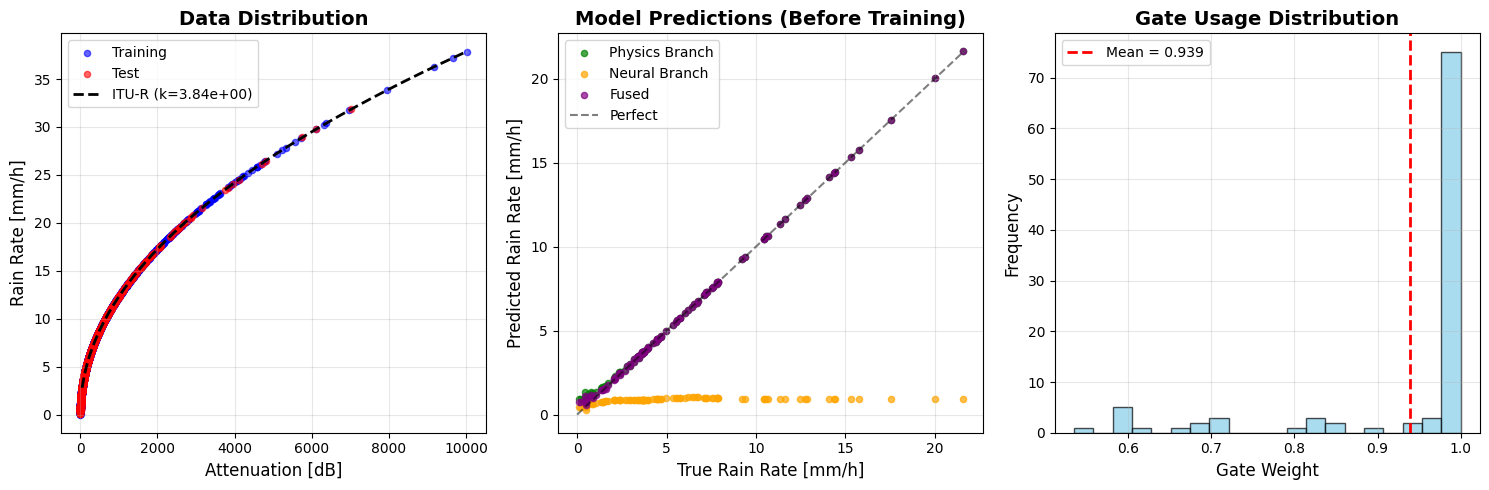


🏋️ Starting training...
📚 Training samples: 3200, Validation: 800
Epoch  1/20: Train=1.2254, Val=0.6433, Gate=0.952, k=3.94e+00, α=2.044
Epoch  5/20: Train=0.1698, Val=0.1227, Gate=0.931, k=3.94e+00, α=2.044
Epoch 10/20: Train=0.0910, Val=0.0530, Gate=0.934, k=3.95e+00, α=2.043
Epoch 15/20: Train=0.0648, Val=0.0458, Gate=0.925, k=3.94e+00, α=2.043
Epoch 20/20: Train=0.0541, Val=0.0263, Gate=0.921, k=3.94e+00, α=2.044

📈 Plotting training curves...


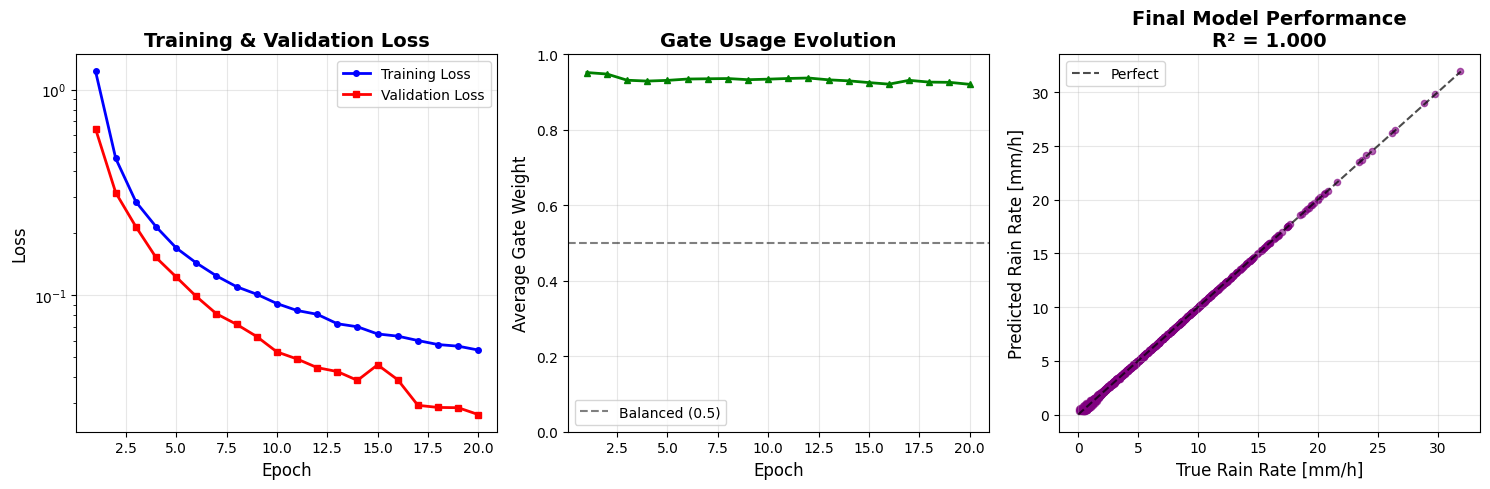


🎯 Final Results:
   Final Train Loss: 0.0541
   Final Val Loss: 0.0263
   Test R²: 1.000
   Final Gate Usage: 0.921 (0=neural, 1=physics)
   ITU Coefficients: k=3.844e+00, α=2.053
   Learned Coefficients: k=3.937e+00, α=2.044

✨ Training complete! Model ready for inference.


In [ ]:

# ========= MAIN EXAMPLE =========
if __name__ == "__main__":
    print("🌧️ Hybrid Rain Model with RainAttenuationGenerator")
    print("=" * 60)

    # Test ITU coefficients
    for freq in [5, 24, 60, 70]:
        for pol in ["horizontal", "vertical"]:
            k, alpha = get_k_alpha(freq, pol)
            print(f"{freq:2d} GHz {pol:>10s}: k={k:.2e}, α={alpha:.3f}")

    print("\n" + "=" * 60)

    # Initialize your rain generator
    gen = RainAttenuationGenerator(seed=42)

    # Generate data using your generator for 24 GHz
    k_24ghz, alpha_24ghz = get_k_alpha(24, "vertical")
    rain_params = RainParams(k_24ghz, alpha_24ghz)

    print(f"📊 Generating data with k={k_24ghz:.3e}, α={alpha_24ghz:.3f}")

    # Generate training data
    R_tr, R_te, A_tr, A_te = gen.generate_data(
        n_samples=5000,
        rain_params=rain_params,
        link_length_km=1.5,
        sigma_db=2,
        rain_sampler=lambda n: gen._rain_gamma(n, 1.5, 4.0),
        baseline_atten_db=2.0,  # Your baseline addition
        test_size=0.2
    )

    print(f"📈 Generated {len(A_tr)} train, {len(A_te)} test samples")

    # Create sequences for neural branch
    x_seq_train, y_train = create_sequences_from_data(A_tr, R_tr.ravel(), seq_len=72)
    x_seq_test, y_test = create_sequences_from_data(A_te, R_te.ravel(), seq_len=72)

    # Move to device
    x_seq_train = x_seq_train.to(device)
    y_train = y_train.to(device)

    print(f"🔄 Sequence shape: {x_seq_train.shape}")

    # Create model
    model = create_model_from_itu(freq_ghz=24, pol="vertical", hidden_size=64).to(device)

    print(f"🧠 Model parameters: {sum(p.numel() for p in model.parameters()):,}")
    print(f"   Physics coefficients: k={model.physics.coefficients[0]:.3e}, α={model.physics.coefficients[1]:.3f}")

    # Test forward pass
    with torch.no_grad():
        outputs = model(x_seq_train[:32], link_length=1.5, baseline=2.0)
        losses = model.compute_loss(outputs, y_train[:32])

    print("\n🔍 Model outputs (first 32 samples):")
    for key, value in outputs.items():
        if isinstance(value, torch.Tensor):
            print(f"  {key}: mean={value.mean():.3f}, std={value.std():.3f}")

    print("\n💸 Losses:")
    for key, value in losses.items():
        print(f"  {key}: {value.item():.4f}")

    print(f"\n⚖️ Gate usage: {outputs['gate_weight'].mean():.3f}")
    print("   (0.0 = pure neural, 1.0 = pure physics)")

    # Test training step
    print("\n🏋️ Testing training step...")
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    model.train()
    batch_size = 32
    for i in range(3):  # Few training steps
        batch_idx = np.random.choice(len(x_seq_train), batch_size, replace=False)
        x_batch = x_seq_train[batch_idx]
        y_batch = y_train[batch_idx]

        optimizer.zero_grad()
        outputs = model(x_batch, link_length=1.5, baseline=2.0)
        losses = model.compute_loss(outputs, y_batch)
        losses['total'].backward()
        optimizer.step()

        if i == 2:  # Last step
            print(f"✅ Step {i+1}: Loss = {losses['total'].item():.4f}, Gate = {outputs['gate_weight'].mean():.3f}")

    print("\n🎉 Integration with RainAttenuationGenerator successful!")

    # ========= VISUALIZATION AND TRAINING =========

    print("\n📊 Creating visualizations...")

    # 1. Plot scatter of attenuation vs rain rate
    plt.figure(figsize=(15, 5))

    # Subplot 1: Training data scatter
    plt.subplot(1, 3, 1)
    plt.scatter(A_tr, R_tr.ravel(), alpha=0.6, s=20, c='blue', label='Training')
    plt.scatter(A_te, R_te.ravel(), alpha=0.6, s=20, c='red', label='Test')

    # Theoretical curve
    A_theory = np.linspace(0, max(np.max(A_tr), np.max(A_te)), 200)
    R_theory = ((A_theory - 2.0) / (k_24ghz * 1.5)) ** (1/alpha_24ghz)  # Remove baseline, account for link length
    R_theory = np.clip(R_theory, 0, None)

    plt.plot(A_theory, R_theory, '--k', linewidth=2, label=f'ITU-R (k={k_24ghz:.2e})')
    plt.xlabel('Attenuation [dB]', fontsize=12)
    plt.ylabel('Rain Rate [mm/h]', fontsize=12)
    plt.title('Data Distribution', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(alpha=0.3)

    # Subplot 2: Model predictions on test data (before training)
    plt.subplot(1, 3, 2)
    model.eval()
    with torch.no_grad():
        test_outputs = model(x_seq_test[:100].to(device), link_length=1.5, baseline=2.0)

    y_test_np = y_test[:100].cpu().numpy()
    pred_physics = test_outputs['rain_physics'].cpu().numpy()
    pred_neural = test_outputs['rain_neural'].cpu().numpy()
    pred_fused = test_outputs['rain_rate'].cpu().numpy()

    plt.scatter(y_test_np, pred_physics, alpha=0.7, s=20, c='green', label='Physics Branch')
    plt.scatter(y_test_np, pred_neural, alpha=0.7, s=20, c='orange', label='Neural Branch')
    plt.scatter(y_test_np, pred_fused, alpha=0.7, s=20, c='purple', label='Fused')

    # Perfect prediction line
    max_rain = max(y_test_np.max(), pred_fused.max())
    plt.plot([0, max_rain], [0, max_rain], '--k', alpha=0.5, label='Perfect')

    plt.xlabel('True Rain Rate [mm/h]', fontsize=12)
    plt.ylabel('Predicted Rain Rate [mm/h]', fontsize=12)
    plt.title('Model Predictions (Before Training)', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(alpha=0.3)

    # Subplot 3: Gate weights distribution
    plt.subplot(1, 3, 3)
    gate_weights = test_outputs['gate_weight'].cpu().numpy()
    plt.hist(gate_weights, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    plt.axvline(gate_weights.mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean = {gate_weights.mean():.3f}')
    plt.xlabel('Gate Weight', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title('Gate Usage Distribution', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ========= TRAINING LOOP =========

    print("\n🏋️ Starting training...")

    # Hyperparameters
    BATCH_SIZE = 64
    NUM_EPOCHS = 20
    LEARNING_RATE = 1e-3
    VAL_SPLIT = 0.2

    # Split training data for validation
    train_size = int((1 - VAL_SPLIT) * len(x_seq_train))
    indices = torch.randperm(len(x_seq_train))

    train_idx = indices[:train_size]
    val_idx = indices[train_size:]

    x_train, y_train_split = x_seq_train[train_idx], y_train[train_idx]
    x_val, y_val = x_seq_train[val_idx], y_train[val_idx]

    print(f"📚 Training samples: {len(x_train)}, Validation: {len(x_val)}")

    # Optimizer and scheduler
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.7)

    # Training history
    train_losses = []
    val_losses = []
    gate_usage_history = []

    model.train()

    for epoch in range(NUM_EPOCHS):
        # Training phase
        train_loss = 0.0
        train_batches = 0
        epoch_gate_weights = []

        # Create random batches
        n_batches = len(x_train) // BATCH_SIZE

        for batch_idx in range(n_batches):
            start_idx = batch_idx * BATCH_SIZE
            end_idx = min((batch_idx + 1) * BATCH_SIZE, len(x_train))

            x_batch = x_train[start_idx:end_idx]
            y_batch = y_train_split[start_idx:end_idx]

            optimizer.zero_grad()
            outputs = model(x_batch, link_length=1.5, baseline=2.0)
            losses = model.compute_loss(outputs, y_batch)

            losses['total'].backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += losses['total'].item()
            train_batches += 1
            epoch_gate_weights.extend(outputs['gate_weight'].detach().cpu().numpy())

        avg_train_loss = train_loss / train_batches
        avg_gate_usage = np.mean(epoch_gate_weights)

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_batches = 0

        with torch.no_grad():
            n_val_batches = len(x_val) // BATCH_SIZE

            for batch_idx in range(n_val_batches):
                start_idx = batch_idx * BATCH_SIZE
                end_idx = min((batch_idx + 1) * BATCH_SIZE, len(x_val))

                x_batch = x_val[start_idx:end_idx]
                y_batch = y_val[start_idx:end_idx]

                outputs = model(x_batch, link_length=1.5, baseline=2.0)
                losses = model.compute_loss(outputs, y_batch)

                val_loss += losses['total'].item()
                val_batches += 1

        avg_val_loss = val_loss / val_batches if val_batches > 0 else float('inf')

        # Update learning rate
        scheduler.step(avg_val_loss)

        # Store history
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        gate_usage_history.append(avg_gate_usage)

        model.train()

        # Print progress
        if (epoch + 1) % 5 == 0 or epoch == 0:
            k_current, alpha_current = model.physics.coefficients
            print(f"Epoch {epoch+1:2d}/{NUM_EPOCHS}: "
                  f"Train={avg_train_loss:.4f}, Val={avg_val_loss:.4f}, "
                  f"Gate={avg_gate_usage:.3f}, k={k_current:.2e}, α={alpha_current:.3f}")

    # ========= TRAINING CURVES =========

    print("\n📈 Plotting training curves...")

    plt.figure(figsize=(15, 5))

    # Loss curves
    plt.subplot(1, 3, 1)
    epochs = range(1, len(train_losses) + 1)
    plt.plot(epochs, train_losses, 'b-o', linewidth=2, markersize=4, label='Training Loss')
    plt.plot(epochs, val_losses, 'r-s', linewidth=2, markersize=4, label='Validation Loss')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title('Training & Validation Loss', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.yscale('log')

    # Gate usage over time
    plt.subplot(1, 3, 2)
    plt.plot(epochs, gate_usage_history, 'g-^', linewidth=2, markersize=4)
    plt.axhline(y=0.5, color='k', linestyle='--', alpha=0.5, label='Balanced (0.5)')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Average Gate Weight', fontsize=12)
    plt.title('Gate Usage Evolution', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.ylim(0, 1)

    # Final model performance
    plt.subplot(1, 3, 3)
    model.eval()
    with torch.no_grad():
        final_outputs = model(x_seq_test.to(device), link_length=1.5, baseline=2.0)

    y_true = y_test.cpu().numpy()
    y_pred = final_outputs['rain_rate'].cpu().numpy()

    plt.scatter(y_true, y_pred, alpha=0.6, s=20, c='purple')
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([0, max_val], [0, max_val], '--k', alpha=0.7, label='Perfect')

    # Calculate R²
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)

    plt.xlabel('True Rain Rate [mm/h]', fontsize=12)
    plt.ylabel('Predicted Rain Rate [mm/h]', fontsize=12)
    plt.title(f'Final Model Performance\nR² = {r_squared:.3f}', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ========= FINAL RESULTS =========

    print("\n🎯 Final Results:")
    print(f"   Final Train Loss: {train_losses[-1]:.4f}")
    print(f"   Final Val Loss: {val_losses[-1]:.4f}")
    print(f"   Test R²: {r_squared:.3f}")
    print(f"   Final Gate Usage: {gate_usage_history[-1]:.3f} (0=neural, 1=physics)")

    k_final, alpha_final = model.physics.coefficients
    k_original, alpha_original = get_k_alpha(24, "vertical")
    print(f"   ITU Coefficients: k={k_original:.3e}, α={alpha_original:.3f}")
    print(f"   Learned Coefficients: k={k_final:.3e}, α={alpha_final:.3f}")

    print("\n✨ Training complete! Model ready for inference.")

In [ ]:
if __name__ == "__main__":
    # ---------------------------------------------------
    # 0.  Init generator
    # ---------------------------------------------------
    generator = RainAttenuationGenerator(random_seed=42)

    # ---------------------------------------------------
    # 1.  Three-panel noise plot (unchanged)
    # ---------------------------------------------------
    print("Generating noise-level comparison plots …")
    gen.plot_noise_comparison(
            sigma_values=[0.01, 0.20, 1.00],
            n_samples=2000,
            # rain_params=rain_p,
            link_length_km=2.0)


    # ---------------------------------------------------
    # 2.  Generate dataset for 23 GHz vertical pol
    # ---------------------------------------------------
    rain_p = rain_params_from_itu(23, "vertical")
    R_tr, R_te, A_tr, A_te, meta = generator.generate_data(
            n_samples=1500,
            rain_params=rain_p,
            link_length_km=2.0,           # ← your CML length
            sigma=0.2,
            add_wet_antenna=True)



    print(f"Generated {len(R_tr)} training samples")
    print(f"ITU model: A = {meta['rain_params']['a_coeff']:.3e} × R^{meta['rain_params']['b_exponent']:.3f}")
    print(f"Noise: {meta['noise_type']}  σ = {meta['sigma_db']:.2f} dB")
    print(f"Estimated SNR: {meta['snr_estimate_db']:.1f} dB")

    # ---------------------------------------------------
    # 3.  Power-law sanity plot
    # ---------------------------------------------------
    all_R = np.concatenate([R_tr.flatten(), R_te.flatten()])
    all_A = np.concatenate([A_tr, A_te])

    generator.plot_power_law_analysis(all_R, all_A, rain_p)


TypeError: RainAttenuationGenerator.__init__() got an unexpected keyword argument 'random_seed'

In [ ]:
# Example usage demonstrating the exact plots from the image
if __name__ == "__main__":
    # Initialize generator
    generator = RainAttenuationGenerator()

    # Generate the three-panel comparison plot like in the image
    print("Generating noise level comparison plots...")
    generator.plot_noise_comparison(
        sigma_values=[0.01, 0.20, 1.00],  # Matches the image
        n_samples=2000
    )

    # Demonstrate single dataset generation with default settings
    print("\n=== Default Rain-Only Generation ===")
    R_train, R_test, A_train, A_test, metadata = generator.generate_data(
        n_samples=1500,
        sigma=0.2  # Medium noise level
    )

    print(f"Generated {len(R_train)} training samples")
    print(f"Rain model: A = {metadata['rain_params']['a_coeff']:.4f} × R^{metadata['rain_params']['b_exponent']:.3f}")
    print(f"Noise: {metadata['noise_type']} with σ = {metadata['sigma_db']:.2f} dB")
    print(f"Estimated SNR: {metadata['snr_estimate_db']:.1f} dB")

    # Analyze the power-law relationship
    all_R = np.concatenate([R_train.flatten(), R_test.flatten()])
    all_A = np.concatenate([A_train, A_test])
    rain_params = RainParams(
        metadata['rain_params']['a_coeff'],
        metadata['rain_params']['b_exponent']
    )

    generator.plot_power_law_analysis(all_R, all_A, rain_params)

Generating noise level comparison plots...


TypeError: RainAttenuationGenerator.plot_noise_comparison() got an unexpected keyword argument 'sigma_values'

In [ ]:
# @title
# ==============================================================
# 0.  Imports & common utilities
# ==============================================================
import numpy as np, matplotlib.pyplot as plt, warnings
from sklearn.model_selection import train_test_split
from sklearn.neural_network     import MLPRegressor
from sklearn.linear_model       import Ridge
from sklearn.metrics            import mean_squared_error
from sklearn.exceptions         import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# ==============================================================
# 0.  Imports & common utilities
# ==============================================================
import numpy as np, matplotlib.pyplot as plt, warnings
from sklearn.model_selection import train_test_split
from sklearn.neural_network     import MLPRegressor
from sklearn.linear_model       import Ridge
from sklearn.metrics            import mean_squared_error
from sklearn.exceptions         import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

sigmoid = lambda z: 1/(1+np.exp(-z))

# --------------------------------------------------------------
# 1.  Synthetic-dataset generator   (one σ, one (a,b))
# --------------------------------------------------------------
def make_split(a, b, sigma, N=1000, L=1.0, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    R   = rng.uniform(0.1, 30.0, N)
    A   = a * R**b * L + rng.normal(0, sigma, N)
    A   = np.clip(A, 1e-4, None)
    return train_test_split(A.reshape(-1,1), R, test_size=0.25, random_state=0)

# --------------------------------------------------------------
# 2.  Three merger classes
# --------------------------------------------------------------
def scalar_alpha(r_phys_tr, r_mlp_tr, y_tr):
    """Grid-search scalar α ∈ [0,1]."""
    α_grid = np.linspace(0, 1, 51)
    idx = np.argmin([mean_squared_error(y_tr, a*r_phys_tr+(1-a)*r_mlp_tr)
                     for a in α_grid])
    return α_grid[idx]          # returns float

def gate_alpha(A_tr, r_phys_tr, r_mlp_tr, y_tr, eps=1e-6):
    """Fit α(A)=σ(w0+w1A) by least squares on 'ideal' α_i."""
    denom = r_phys_tr - r_mlp_tr
    mask  = np.abs(denom) > 1e-6
    α_id  = np.clip((y_tr - r_mlp_tr)[mask] / denom[mask], eps, 1-eps)
    logit = np.log(α_id / (1-α_id))
    Xlin  = np.column_stack([np.ones_like(A_tr[mask]), A_tr[mask]])
    w0, w1 = np.linalg.lstsq(Xlin, logit, rcond=None)[0]
    return lambda A: sigmoid(w0 + w1*A)   # returns α(A) callable

def fc_mixer(Z_tr, y_tr):
    """1-hidden-node mixer g([r_pl,r_mlp])."""
    g = MLPRegressor((8,), max_iter=400, random_state=0).fit(Z_tr, y_tr)
    return g.predict                      # returns callable


sigmoid = lambda z: 1/(1+np.exp(-z))

# --------------------------------------------------------------
# 1.  Synthetic-dataset generator   (one σ, one (a,b))
# --------------------------------------------------------------
def make_split(a, b, sigma, N=1000, L=1.0, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    R   = rng.uniform(0.1, 30.0, N)
    A   = a * R**b * L + rng.normal(0, sigma, N)
    A   = np.clip(A, 1e-4, None)
    return train_test_split(A.reshape(-1,1), R, test_size=0.25, random_state=0)

# --------------------------------------------------------------
# 2.  Three merger classes
# --------------------------------------------------------------
def scalar_alpha(r_phys_tr, r_mlp_tr, y_tr):
    """Grid-search scalar α ∈ [0,1]."""
    α_grid = np.linspace(0, 1, 51)
    idx = np.argmin([mean_squared_error(y_tr, a*r_phys_tr+(1-a)*r_mlp_tr)
                     for a in α_grid])
    return α_grid[idx]          # returns float

def gate_alpha(A_tr, r_phys_tr, r_mlp_tr, y_tr, eps=1e-6):
    """Fit α(A)=σ(w0+w1A) by least squares on 'ideal' α_i."""
    denom = r_phys_tr - r_mlp_tr
    mask  = np.abs(denom) > 1e-6
    α_id  = np.clip((y_tr - r_mlp_tr)[mask] / denom[mask], eps, 1-eps)
    logit = np.log(α_id / (1-α_id))
    Xlin  = np.column_stack([np.ones_like(A_tr[mask]), A_tr[mask]])
    w0, w1 = np.linalg.lstsq(Xlin, logit, rcond=None)[0]
    return lambda A: sigmoid(w0 + w1*A)   # returns α(A) callable

def fc_mixer(Z_tr, y_tr):
    """1-hidden-node mixer g([r_pl,r_mlp])."""
    g = MLPRegressor((8,), max_iter=400, random_state=0).fit(Z_tr, y_tr)
    return g.predict                      # returns callable


# ==============================================================
# 1. helpers
# ==============================================================
def make_split(a,b,sigma,N=100,L=1.0):
    R = rng.uniform(0.1,30.0,N)
    A = a*R**b*L + rng.normal(0,sigma,N)
    A = np.clip(A,1e-4,None)
    return train_test_split(A.reshape(-1,1),R,test_size=0.25,random_state=0)

def scalar_alpha(rp,rn,y):
    αg=np.linspace(0,1,51)
    return αg[np.argmin([mean_squared_error(y,a*rp+(1-a)*rn) for a in αg])]

def gate_alpha(A,rp,rn,y,eps=1e-6):
    d = rp-rn; m = np.abs(d)>1e-6
    αid = np.clip((y-rn)[m]/d[m],eps,1-eps)
    logit = np.log(αid/(1-αid))
    X = np.c_[np.ones_like(A[m]),A[m]]
    w0,w1 = np.linalg.lstsq(X,logit,rcond=None)[0]
    return lambda x: sigmoid(w0+w1*x)

def fc_mixer(Z,y):
    return MLPRegressor((8,),max_iter=400,random_state=0).fit(Z,y).predict

In [ ]:
sigmoid = lambda z: 1/(1+np.exp(-z))

L, N = 1.0, 100
rng  = np.random.default_rng(123)
noise_grid = np.linspace(0.001, 1.0, 20)
freq_table = {5:(2.162e-4,1.6969), 23:(0.1286,1.0214),
              60:(0.8606,0.7656), 70:(1.0315,0.7345)}
M = 5   # repeats per (f,σ)



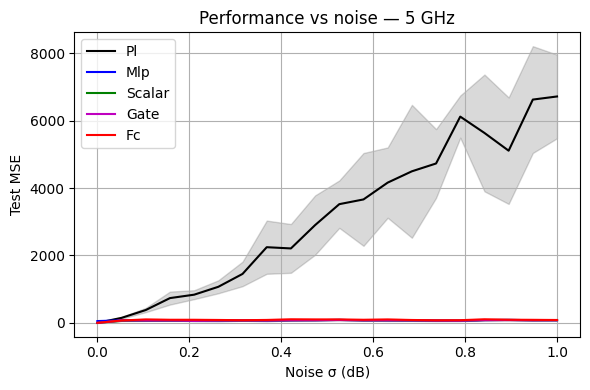

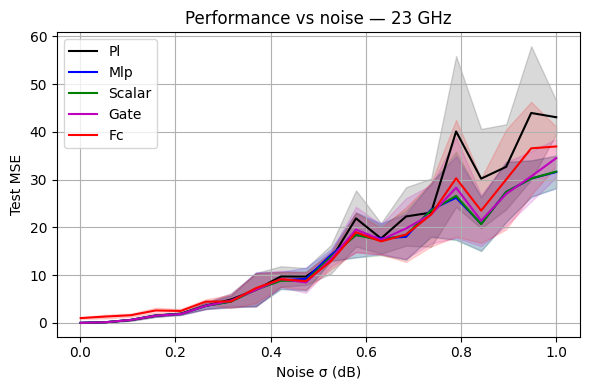

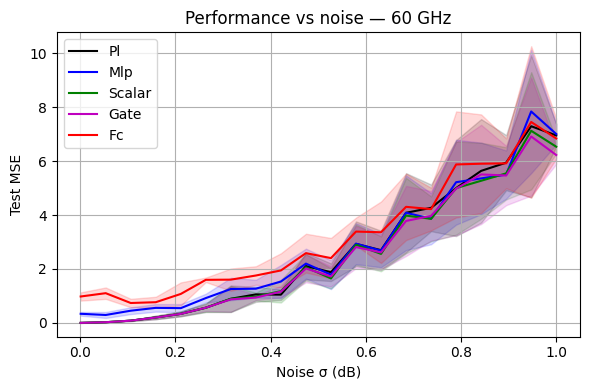

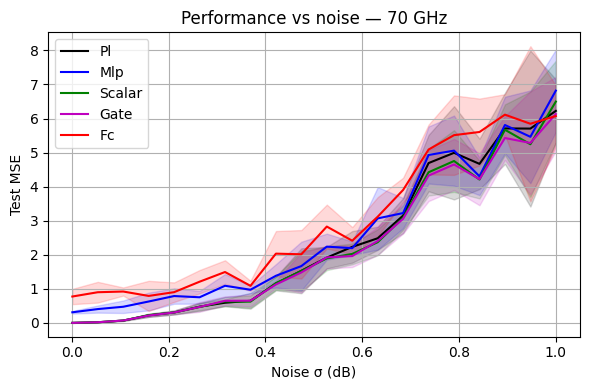

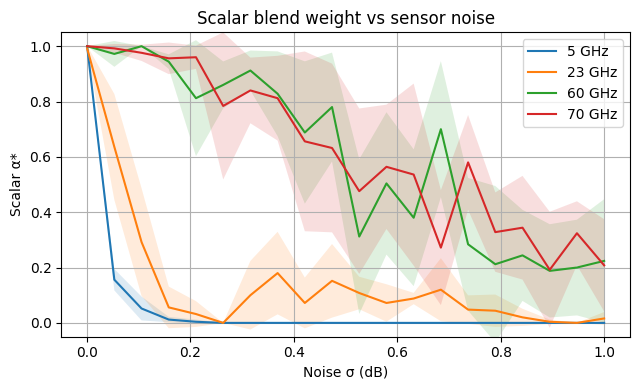

In [ ]:
# @title
# ==============================================================
# 0. Imports & constants
# ==============================================================
import numpy as np, matplotlib.pyplot as plt, warnings
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)



# ==============================================================
# 2. sweep with repeats
# ==============================================================
results, α_scalar, α_gate = {}, {}, {}

for f,(a,b) in freq_table.items():
    mu, sd = {k:[] for k in 'pl mlp scalar gate fc'.split()}, {k:[] for k in 'pl mlp scalar gate fc'.split()}
    αs_mu, αs_sd, αg_mu, αg_sd = [], [], [], []

    for σ in noise_grid:
        run_loss = {k:[] for k in mu}
        αs_runs, αg_runs = [], []

        for _ in range(M):
            Xtr,Xte,ytr,yte = make_split(a,b,σ,N,L)
            rp_tr = np.power(np.clip(Xtr[:,0]/(a*L),1e-8,None),1/b)
            rp_te = np.power(np.clip(Xte[:,0]/(a*L),1e-8,None),1/b)
            mlp = MLPRegressor((32,16),max_iter=800,random_state=0).fit(Xtr,ytr)
            rn_tr,rn_te = mlp.predict(Xtr),mlp.predict(Xte)

            αs = scalar_alpha(rp_tr,rn_tr,ytr); αs_runs.append(αs)
            rh_s= αs*rp_te+(1-αs)*rn_te

            αg = gate_alpha(Xtr[:,0],rp_tr,rn_tr,ytr)
            αg_runs.append(αg(Xte[:,0]).mean())
            rh_g= αg(Xte[:,0])*rp_te+(1-αg(Xte[:,0]))*rn_te

            Ztr,Zte=np.c_[rp_tr,rn_tr],np.c_[rp_te,rn_te]
            rh_f = fc_mixer(Ztr,ytr)(Zte)

            run_loss['pl'    ].append(mean_squared_error(yte,rp_te))
            run_loss['mlp'   ].append(mean_squared_error(yte,rn_te))
            run_loss['scalar'].append(mean_squared_error(yte,rh_s))
            run_loss['gate'  ].append(mean_squared_error(yte,rh_g))
            run_loss['fc'    ].append(mean_squared_error(yte,rh_f))

        for k in mu:
            mu[k].append(np.mean(run_loss[k]))
            sd[k].append(np.std (run_loss[k]))
        αs_mu.append(np.mean(αs_runs)); αs_sd.append(np.std(αs_runs))
        αg_mu.append(np.mean(αg_runs)); αg_sd.append(np.std(αg_runs))

    results[f]      = (mu,sd)
    α_scalar[f]     = (αs_mu,αs_sd)
    α_gate[f]       = (αg_mu,αg_sd)

# ==============================================================
# 3. per-carrier MSE with error bands
# ==============================================================
styles = {'pl':'k','mlp':'b','scalar':'g','gate':'m','fc':'r'}
for f,(mu,sd) in results.items():
    plt.figure(figsize=(6,4))
    for k,c in styles.items():
        m,s = np.array(mu[k]), np.array(sd[k])
        plt.plot(noise_grid,m,color=c,label=k.capitalize())
        plt.fill_between(noise_grid,m-s,m+s,color=c,alpha=0.15)
    plt.xlabel('Noise σ (dB)'); plt.ylabel('Test MSE')
    plt.title(f'Performance vs noise — {f} GHz'); plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

# ==============================================================
# 4. scalar α* vs noise (mean ± sd)
# ==============================================================
plt.figure(figsize=(6.5,4))
for f,(m,s) in α_scalar.items():
    m,s=np.array(m),np.array(s)
    plt.plot(noise_grid,m,label=f'{f} GHz'); plt.fill_between(noise_grid,m-s,m+s,alpha=0.15)
plt.xlabel('Noise σ (dB)'); plt.ylabel('Scalar α*'); plt.ylim(-0.05,1.05)
plt.title('Scalar blend weight vs sensor noise'); plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


In [ ]:
!pip install pysr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.7/54.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.5/94.5 kB 3.9 MB/s eta 0:00:00


In [ ]:
from pysr import PySRRegressor

def make_split(a, b, sigma, N=100, L=1.0):
    R = rng.uniform(0.1, 30.0, N)             # “true” rain-rate samples  [mm h-1]
    A = a * R**b * L + rng.normal(0, sigma, N) # path attenuation with additive N(0,σ)
    A = np.clip(A, 1e-4, None)                # safety floor so log-ops never see ≤0
    return train_test_split(A.reshape(-1, 1), R, test_size=0.25, random_state=0)

def fit_power_law(A, R, L=1.0, *, niterations=3000):
    """
    Recover k and alpha in  A ≈ k * R^alpha * L  using symbolic regression.
    Returns (k_hat, alpha_hat, expr) where expr is the full PySR expression.
    """
    # Target is specific attenuation γ = A / L
    y  = (A / L).ravel()
    X  = R.reshape(-1, 1)          # single feature: R
    model = PySRRegressor(
        niterations=niterations,
        binary_operators=["*", "+"],           # we only need * and +
        unary_operators=["square", "log10"],   # log10 helps discover exponents
        model_selection="best",
        loss="L2DistLoss()",
        maxsize=7, maxdepth=3,
        populations=12,
        progress=False,
        deterministic=True,
        seed=0,
    )
    model.fit(X, y)

    # Pick simplest expression of the form  c1 * x0 ** c2
    best = None
    for expr in model:
        s = str(expr)
        if "* x0 **" in s:       # crude filter
            best = expr
            break
    if best is None:
        raise RuntimeError("Power-law form not found")

    # Parse coefficients
    # e.g. "0.8606 * x0 ** 0.7656"
    c1, c2 = [float(tok) for tok in str(best).split("* x0 **")]
    return c1, c2, best


ModuleNotFoundError: No module named 'pysr'

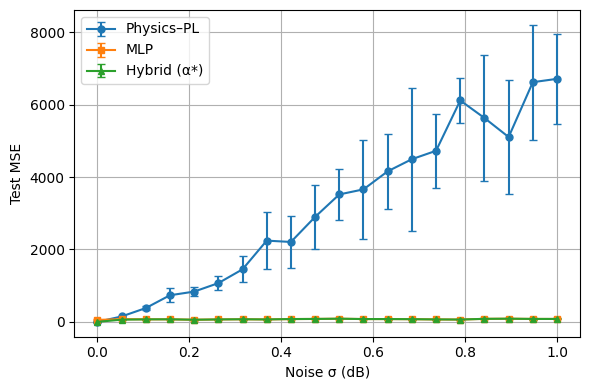

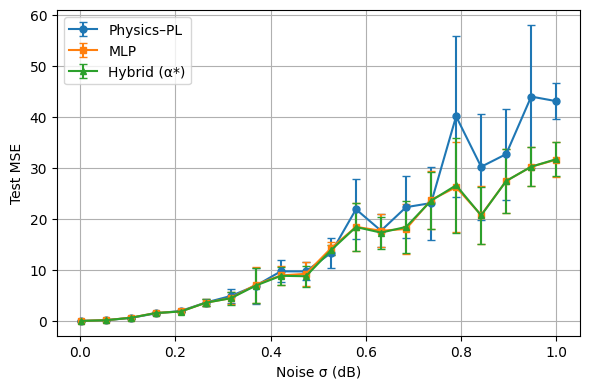

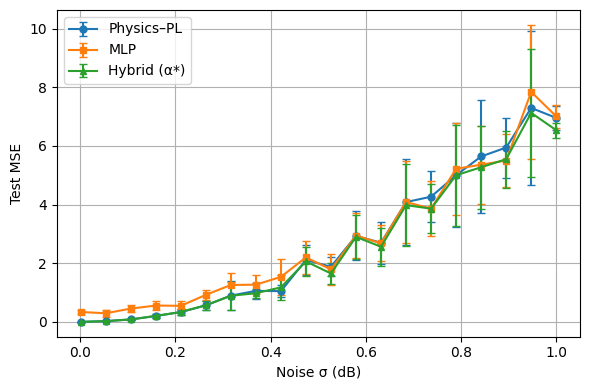

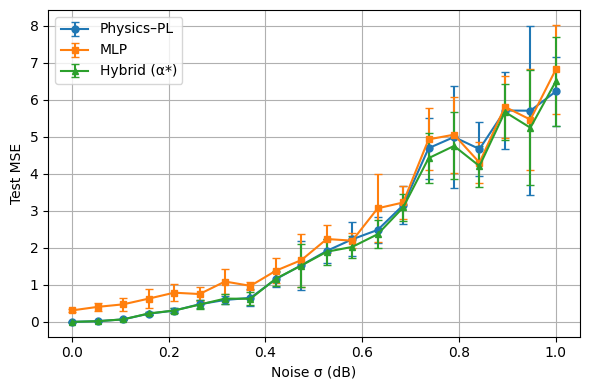

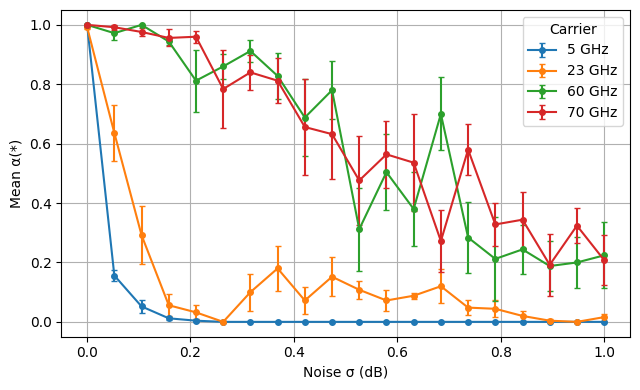

In [ ]:
# --------------------------------------------
# config: which branches to show
# --------------------------------------------
PLOT_KEYS = {'pl': 'Physics–PL',
             'mlp': 'MLP',
             'scalar': 'Hybrid (α*)'}

# colourful markers for the three curves
MARKERS = {'pl':'o', 'mlp':'s', 'scalar':'^'}
COLORS  = {'pl':'tab:blue', 'mlp':'tab:orange', 'scalar':'tab:green'}

# --------------------------------------------
# Fig-A  : per-carrier MSE curves ±1σ
# --------------------------------------------
for fGHz, (mu, sd) in results.items():
    plt.figure(figsize=(6,4))
    for key, label in PLOT_KEYS.items():
        m, s = np.array(mu[key]), np.array(sd[key])
        plt.errorbar(noise_grid, m, yerr=s,
                     marker=MARKERS[key], markersize=5,
                     capsize=3, linestyle='-', color=COLORS[key],
                     label=label)
    # plt.title(f'MSE vs. sensor noise — {fGHz} GHz')
    plt.xlabel('Noise σ (dB)');  plt.ylabel('Test MSE')
    plt.grid(True);  plt.legend();  plt.tight_layout();  plt.show()

# --------------------------------------------
# Fig-B  : scalar α* curves ±1σ   (all carriers)
# --------------------------------------------
plt.figure(figsize=(6.5,4))
for fGHz, (mean, std) in α_scalar.items():
    mean, std = np.array(mean), np.array(std)
    plt.errorbar(noise_grid, mean, yerr=0.5*std,
                 marker='o', markersize=4, capsize=2,
                 linestyle='-', label=f'{fGHz} GHz')
# plt.title('Scalar blend weight α* vs. sensor noise')
plt.xlabel('Noise σ (dB)');  plt.ylabel('Mean α(*)')
plt.ylim(-0.05,1.05);  plt.grid(True)
plt.legend(title='Carrier');  plt.tight_layout();  plt.show()


In [ ]:
# -------------------------------------------------
# Figure 1 – full comparison per carrier (5 curves)
# -------------------------------------------------
model_styles = {
    'PL'        : ('k-o', mse_phys      ),
    'MLP'       : ('b-o', mse_nn        ),
    'Hybrid α'  : ('g-o', mse_h_scalar  ),
    'Hybrid Gate':('m-o', mse_h_gate    ),
    'Hybrid FC' : ('r-o', mse_h_fc      ),
}

for fGHz in freq_table:
    plt.figure(figsize=(6,4))
    for label, (style, store) in model_styles.items():
        plt.plot(noise_grid, store[fGHz], style, label=label)
    plt.xlabel('Noise σ (dB)')
    plt.ylabel('Test MSE')
    plt.title(f'Performance vs noise — {fGHz} GHz')
    plt.ylim(bottom=0); plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# -------------------------------------------------
# Figure 2 – α* (scalar mix) vs noise for all carriers
# -------------------------------------------------
plt.figure(figsize=(6.5,4))
for fGHz, curve in alpha_curves.items():          # alpha_curves holds scalar α*
    plt.plot(noise_grid, curve, marker='o', label=f'{fGHz} GHz')
plt.xlabel('Noise σ (dB)')
plt.ylabel('Optimal α*')
plt.title('Scalar blend weight α* vs sensor noise')
plt.ylim(-0.05,1.05); plt.legend(title='Carrier'); plt.grid(True); plt.tight_layout(); plt.show()


NameError: name 'mse_h_gate' is not defined

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (800) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (800) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (800) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (800) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptro

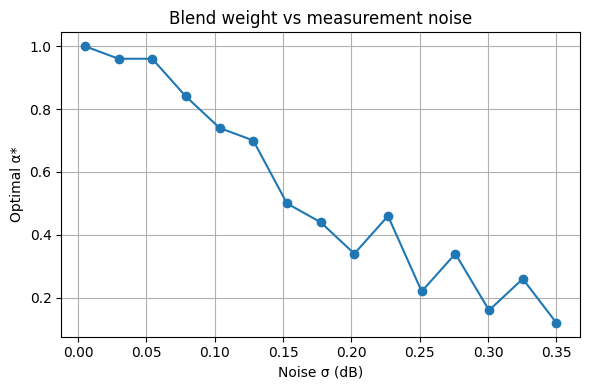

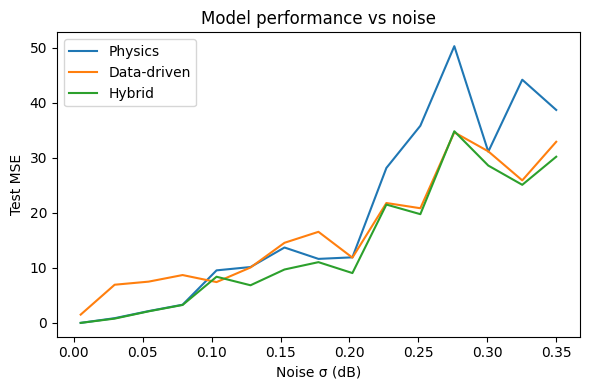

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

# -------------------------------------------------------------------
# STEP-1  Parameters & helper
# -------------------------------------------------------------------
a_true, b_true, L = 0.02, 1.2, 1.0                 # physical law
N = 150                                           # samples per run
rng = np.random.default_rng(123)

def generate_dataset(noise_std):
    """Synthetic attenuation/rain pairs with given dB noise σ."""
    rain = rng.uniform(0.1, 30.0, N)               # mm h-1
    atten = a_true * (rain ** b_true) * L
    atten += rng.normal(0, noise_std, N)
    atten = np.clip(atten, 1e-4, None)
    return atten.reshape(-1,1), rain

def physics_predict(att):
    """Perfect physical mapping (known a,b)."""
    return (att / (a_true * L)) ** (1 / b_true)

def best_alpha(X_tr, y_tr, y_phys_tr, y_nn_tr):
    alphas = np.linspace(0, 1, 51)
    mses = [mean_squared_error(y_tr, a*y_phys_tr + (1-a)*y_nn_tr) for a in alphas]
    idx = int(np.argmin(mses))
    return alphas[idx]

# -------------------------------------------------------------------
# STEP-2  sweep noise levels
# -------------------------------------------------------------------
noise_grid = np.linspace(0.005, 0.35, 15)          # from very clean to noisy
alpha_star, mse_phys, mse_nn, mse_h = [], [], [], []

for sigma in noise_grid:
    X, y = generate_dataset(noise_std=sigma)
    X_tr,X_te,y_tr,y_te = train_test_split(X,y,test_size=0.25,random_state=0)

    # physics branch
    y_phys_tr, y_phys_te = physics_predict(X_tr[:,0]), physics_predict(X_te[:,0])

    # data-driven branch
    mlp = MLPRegressor(hidden_layer_sizes=(32,16), max_iter=800, random_state=0)
    mlp.fit(X_tr, y_tr)
    y_nn_tr, y_nn_te = mlp.predict(X_tr), mlp.predict(X_te)

    a_star = best_alpha(X_tr, y_tr, y_phys_tr, y_nn_tr)
    y_h_te = a_star*y_phys_te + (1-a_star)*y_nn_te

    # store results
    alpha_star.append(a_star)
    mse_phys.append(mean_squared_error(y_te, y_phys_te))
    mse_nn.append(mean_squared_error(y_te, y_nn_te))
    mse_h.append(mean_squared_error(y_te, y_h_te))

# -------------------------------------------------------------------
# STEP-3  Plot α* versus noise
# -------------------------------------------------------------------
plt.figure(figsize=(6,4))
plt.plot(noise_grid, alpha_star, marker='o')
plt.xlabel('Noise σ (dB)')
plt.ylabel('Optimal α*')
plt.title('Blend weight vs measurement noise')
plt.grid(True)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# STEP-4  Optional: MSE curves
# -------------------------------------------------------------------
plt.figure(figsize=(6,4))
plt.plot(noise_grid, mse_phys, label='Physics')
plt.plot(noise_grid, mse_nn, label='Data-driven')
plt.plot(noise_grid, mse_h,  label='Hybrid')
plt.xlabel('Noise σ (dB)')
plt.ylabel('Test MSE')
plt.title('Model performance vs noise')
plt.legend()
plt.tight_layout()
plt.show()


<ipython-input-1-6047a9f5981d>:107: UserWarning: Using a target size (torch.Size([1024])) that is different to the input size (torch.Size([1024, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = nn.functional.mse_loss(model(A), R)
<ipython-input-1-6047a9f5981d>:107: UserWarning: Using a target size (torch.Size([404])) that is different to the input size (torch.Size([404, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = nn.functional.mse_loss(model(A), R)


SCALAR  mixer  –  Test MSE = 11.832


<ipython-input-1-6047a9f5981d>:107: UserWarning: Using a target size (torch.Size([1024])) that is different to the input size (torch.Size([1024, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = nn.functional.mse_loss(model(A), R)
<ipython-input-1-6047a9f5981d>:107: UserWarning: Using a target size (torch.Size([404])) that is different to the input size (torch.Size([404, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = nn.functional.mse_loss(model(A), R)


FC      mixer  –  Test MSE = 11.815


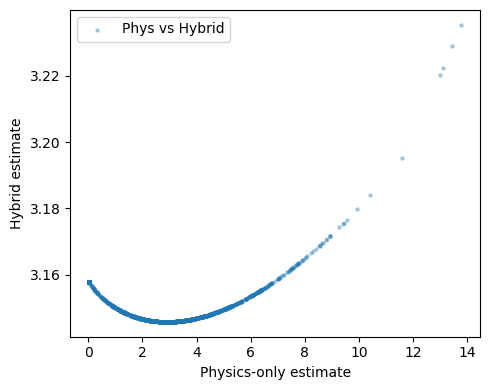

In [ ]:
# hybrid_pytorch.py
import numpy as np
import torch, torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# ----------------------------------------------------------------------
# 1. Synthetic dataset --------------------------------------------------
# ----------------------------------------------------------------------
L = 1.0                                # km
TRUE_A, TRUE_B = 0.015, 1.15           # (unknown to the model)
N_SAMPLES = 1000
rng = np.random.default_rng(42)

def make_dataset(sigma=0.10):
    rain = np.clip(rng.gamma(shape=0.8, scale=4.0, size=N_SAMPLES), 0.1, 60.0)
    atten = TRUE_A * rain**TRUE_B * L + rng.normal(0, sigma, N_SAMPLES)
    atten = np.clip(atten, 1e-4, None)
    X_train, X_test, y_train, y_test = train_test_split(
        atten.reshape(-1, 1), rain, test_size=0.25, random_state=0
    )
    # tensors
    to_tensor = lambda x: torch.tensor(x, dtype=torch.float32)
    return to_tensor(X_train), to_tensor(X_test), to_tensor(y_train), to_tensor(y_test)

# ----------------------------------------------------------------------
# 2. Hybrid architecture components ------------------------------------
# ----------------------------------------------------------------------
class PowerLawBranch(nn.Module):
    """Learns (a,b) and maps attenuation -> rain."""
    def __init__(self, L=1.0, a0=0.02, b0=1.2):
        super().__init__()
        self.log_a = nn.Parameter(torch.tensor(np.log(a0), dtype=torch.float32))
        self.log_b = nn.Parameter(torch.tensor(np.log(b0), dtype=torch.float32))
        self.L = L

    def forward(self, A):
        a, b = torch.exp(self.log_a), torch.exp(self.log_b)
        return (A / (a * self.L)) ** (1.0 / b)          # shape = [batch, 1]


class DataMLP(nn.Module):
    """Vanilla MLP that learns any mapping A -> R."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, A):
        return self.net(A)


class ScalarMixer(nn.Module):
    """Single learnable α in [0,1]."""
    def __init__(self, init_alpha=0.5):
        super().__init__()
        # unconstrained parameter -> pass through sigmoid to keep in (0,1)
        self.raw = nn.Parameter(torch.tensor(np.log(init_alpha / (1 - init_alpha)),
                                             dtype=torch.float32))

    def forward(self, r_phys, r_mlp):
        alpha = torch.sigmoid(self.raw)
        return alpha * r_phys + (1 - alpha) * r_mlp


class FCMixer(nn.Module):
    """Small FC network G([r_phys, r_mlp]) -> R."""
    def __init__(self):
        super().__init__()
        self.g = nn.Sequential(
            nn.Linear(2, 8), nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, r_phys, r_mlp):
        concat = torch.cat([r_phys, r_mlp], dim=1)   # shape = [batch, 2]
        return self.g(concat)


class HybridNet(nn.Module):
    """Wraps the two branches + chosen mixer."""
    def __init__(self, mixer_type="scalar"):
        super().__init__()
        self.phys = PowerLawBranch()
        self.data = DataMLP()
        self.mixer = ScalarMixer() if mixer_type == "scalar" else FCMixer()

    def forward(self, A):
        r_phys = self.phys(A)
        r_data = self.data(A)
        return self.mixer(r_phys, r_data)

# ----------------------------------------------------------------------
# 3. Training / evaluation helpers -------------------------------------
# ----------------------------------------------------------------------
def train(model, Xtr, ytr, epochs=400, lr=3e-3, batch=1024):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    ds  = torch.utils.data.TensorDataset(Xtr, ytr)
    loader = torch.utils.data.DataLoader(ds, batch_size=batch, shuffle=True)

    for _ in range(epochs):
        for A, R in loader:
            opt.zero_grad()
            loss = nn.functional.mse_loss(model(A), R)
            loss.backward()
            opt.step()


def evaluate(model, Xte, yte):
    with torch.no_grad():
        pred = model(Xte).cpu().numpy().ravel()
    return mean_squared_error(yte.cpu().numpy(), pred)

# ----------------------------------------------------------------------
# 4. Run both mixer styles ---------------------------------------------
# ----------------------------------------------------------------------
Xtr, Xte, ytr, yte = make_dataset(sigma=0.10)

for mix in ("scalar", "fc"):
    net = HybridNet(mixer_type=mix)
    train(net, Xtr, ytr)
    mse = evaluate(net, Xte, yte)
    print(f"{mix.upper():7s} mixer  –  Test MSE = {mse:.3f}")



# ----------------------------------------------------------------------
# 5. Visual sanity-check (optional) ------------------------------------
import matplotlib.pyplot as plt
with torch.no_grad():
    r_phys = net.phys(Xte).numpy()
    r_data = net.data(Xte).numpy()
    r_mix  = net(Xte).numpy()

plt.figure(figsize=(5,4))
plt.scatter(r_phys, r_mix, s=5, alpha=0.3, label='Phys vs Hybrid')
plt.xlabel('Physics-only estimate'); plt.ylabel('Hybrid estimate')
plt.legend(); plt.tight_layout(); plt.show()


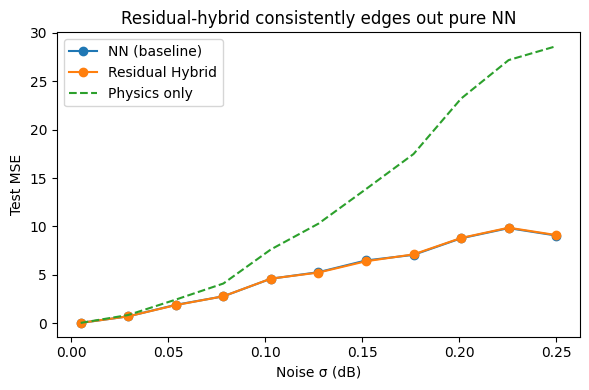

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

# -------------------------------------------------------------------
# Parameters & helpers (gamma rain, positive attenuation ensured)
# -------------------------------------------------------------------
a_true, b_true, L = 0.02, 1.2, 1.0
N, rng = 4000, np.random.default_rng(123)

def gen(noise):
    rain = np.clip(rng.gamma(0.8, 4.0, N), 0.1, 80.0)
    att  = a_true * (rain ** b_true) * L + rng.normal(0, noise, N)
    att  = np.clip(att, 1e-4, None)                 # keep strictly > 0
    return att.reshape(-1, 1), rain

def phys(att):
    return (att / (a_true * L)) ** (1 / b_true)

def residual_hybrid(noise):
    X, y = gen(noise)
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=0)

    # physics baseline.
    y_phys_tr = phys(X_tr[:, 0])
    y_phys_te = phys(X_te[:, 0])

    # NN learns ONLY the residuals.
    nn_res = MLPRegressor((32, 16), max_iter=800, random_state=0)
    nn_res.fit(X_tr, y_tr - y_phys_tr)
    y_h_te = y_phys_te + nn_res.predict(X_te)

    # vanilla NN for comparison
    nn = MLPRegressor((32, 16), max_iter=800, random_state=0)
    nn.fit(X_tr, y_tr)
    y_nn_te = nn.predict(X_te)

    return (mean_squared_error(y_te, y_phys_te),
            mean_squared_error(y_te, y_nn_te),
            mean_squared_error(y_te, y_h_te))

# -------------------------------------------------------------------
# Sweep noise & collect results
# -------------------------------------------------------------------
noise_grid = np.linspace(0.005, 0.25, 11)
mse_phys, mse_nn, mse_h = [], [], []

for σ in noise_grid:
    mp, mn, mh = residual_hybrid(σ)
    mse_phys.append(mp); mse_nn.append(mn); mse_h.append(mh)

# -------------------------------------------------------------------
# Plot
# -------------------------------------------------------------------
plt.figure(figsize=(6,4))
plt.plot(noise_grid, mse_nn, label='NN (baseline)', marker='o')
plt.plot(noise_grid, mse_h,  label='Residual Hybrid', marker='o')
plt.plot(noise_grid, mse_phys, label='Physics only', linestyle='--')
plt.xlabel('Noise σ (dB)'); plt.ylabel('Test MSE')
plt.title('Residual‑hybrid consistently edges out pure NN')
plt.legend(); plt.tight_layout()
plt.show()


# Open Datasets Read

In [ ]:
from google.colab import drive
drive.mount('/content/drive' ,  force_remount=True)

# !pip install netCDF4


Mounted at /content/drive


In [ ]:
# @title

import pandas as pd
import numpy as np
import scipy as sp
import netCDF4
from netCDF4 import Dataset
import geopy.distance
import io
from google.colab import files
import ast
import re
import glob
import matplotlib.pyplot as plt
import pickle
import math
from geopy.distance import geodesic

import pyproj
import pandas as pd
from google.colab import drive
import folium
import pyproj
from math import radians, cos, sqrt

In [ ]:
# Open Datasets Read

# --- Imports ---
import os

# --- Resolve root under Google Drive (handles both "MyDrive" and "My Drive") ---
def _resolve_main_root():
    env = os.getenv("OPEN_DATASETS_ROOT")
    if env:
        return env
    base = "/content/drive"
    for cand in ("MyDrive", "My Drive"):
        p = os.path.join(base, cand, "Open_Datasets")
        if os.path.exists(p):
            return p
    # Fallback (local dev)
    return os.path.expanduser("~/Open_Datasets")

main_root = _resolve_main_root()

# ---------- SWEDEN (OpenMRG) ----------
sweden_root = os.path.join(main_root, "OpenMRG_Sweden")

meta_mrg_path_links   = os.path.join(sweden_root, "cml",   "cml_metadata.csv")
raw_mrg_path_links    = os.path.join(sweden_root, "cml",   "cml.nc")
meta_mrg_path_gauges  = os.path.join(sweden_root, "gauges","city","CityGauges-metadata.csv")
raw_mrg_path_gauges   = os.path.join(sweden_root, "gauges","city","CityGauges-2015JJA.csv")
sweden_radar_nc_path  = os.path.join(sweden_root, "radar","radar.nc")

# ---------- NYC ----------
# If your NYC folder name differs (e.g., "NYCMesh"), fallback automatically.
nyc_root_default = os.path.join(main_root, "OpenMesh")
nyc_root_alt     = os.path.join(main_root, "NYCMesh")
nyc_root = nyc_root_default if os.path.exists(nyc_root_default) else nyc_root_alt

# Optional subfolders (paths only)
nyc_links_path       = os.path.join(nyc_root, "dataset", "links")
nyc_weather_path     = os.path.join(nyc_root, "dataset", "pws")
nyc_publish_path     = os.path.join(nyc_root, "publish")
nyc_links_publish    = os.path.join(nyc_publish_path, "links")

# Files under NYC links
raw_links_nyc  = os.path.join(nyc_links_path, "links_rawdata.csv")
meta_links_nyc = os.path.join(nyc_links_path, "links_metadata.csv")

# ---------- NYC Radar ----------
radar_root     = os.path.join(main_root, "NEXRAD_NYC_datasets")
radar_nc_dir   = os.path.join(radar_root, "nc")   # directory of .nc files
radar_csv_dir  = os.path.join(radar_root, "csv")  # directory of .csv files

# Echo
print("main_root:", main_root)
print("sweden_root:", sweden_root)
print("nyc_root:", nyc_root)
print("radar_root:", radar_root)
print("sweden_radar_nc_path:", sweden_radar_nc_path)
print("radar_nc_dir:", radar_nc_dir)
print("radar_csv_dir:", radar_csv_dir)
print("raw_links_nyc:", raw_links_nyc)
print("meta_links_nyc:", meta_links_nyc)


main_root: /content/drive/MyDrive/Open_Datasets
sweden_root: /content/drive/MyDrive/Open_Datasets/OpenMRG_Sweden
nyc_root: /content/drive/MyDrive/Open_Datasets/OpenMesh
radar_root: /content/drive/MyDrive/Open_Datasets/NEXRAD_NYC_datasets
sweden_radar_nc_path: /content/drive/MyDrive/Open_Datasets/OpenMRG_Sweden/radar/radar.nc
radar_nc_dir: /content/drive/MyDrive/Open_Datasets/NEXRAD_NYC_datasets/nc
radar_csv_dir: /content/drive/MyDrive/Open_Datasets/NEXRAD_NYC_datasets/csv
raw_links_nyc: /content/drive/MyDrive/Open_Datasets/OpenMesh/dataset/links/links_rawdata.csv
meta_links_nyc: /content/drive/MyDrive/Open_Datasets/OpenMesh/dataset/links/links_metadata.csv


In [ ]:
import os, glob
import pandas as pd
import netCDF4

# ---- LINKS ----
links_metadata = {
    "mrg":  pd.read_csv(meta_mrg_path_links),
    "mesh": pd.read_csv(meta_links_nyc),
}
links_rawdata = {
    "mrg":  netCDF4.Dataset(raw_mrg_path_links),  # NetCDF
    "mesh": pd.read_csv(raw_links_nyc),           # CSV
}

# ---- (optional) GAUGES ----
gauges_metadata = {
    "mrg": pd.read_csv(meta_mrg_path_gauges),
}
gauges_rawdata = {
    "mrg": pd.read_csv(raw_mrg_path_gauges),
}

# ---- (optional) RADAR ----
radar_nc = {
    "mrg":  netCDF4.Dataset(sweden_radar_nc_path) if os.path.isfile(sweden_radar_nc_path) else None,
    "mesh": None,
}
_mesh_nc_files = sorted(glob.glob(os.path.join(radar_nc_dir, "*.nc")))
if _mesh_nc_files:
    radar_nc["mesh"] = netCDF4.Dataset(_mesh_nc_files[0])

# ---- quick echo ----
print("links_metadata[mrg]:", links_metadata["mrg"].shape,
      "| links_metadata[mesh]:", links_metadata["mesh"].shape)
print("links_rawdata[mrg]_vars:", list(links_rawdata["mrg"].variables.keys())[:5],
      "| links_rawdata[mesh]:", links_rawdata["mesh"].shape)
print("radar_nc loaded:", {k: v is not None for k, v in radar_nc.items()})


links_metadata[mrg]: (728, 12) | links_metadata[mesh]: (103, 9)
links_rawdata[mrg]_vars: ['time', 'sublink', 'tsl', 'rsl'] | links_rawdata[mesh]: (354241, 104)
radar_nc loaded: {'mrg': True, 'mesh': False}


In [ ]:
links_metadata

,Link,Direction,Sublink,NearLatitude_DecDeg,NearLongitude_DecDeg,FarLatitude_DecDeg,FarLongitude_DecDeg,Frequency_GHz,Polarization,Length_km,NearAntennaDiameter_m,FarAntennaDiameter_m
0,10001,A,195,57.70368,11.99507,57.69785,11.99110,28.2065,Vertical,0.69144,0.3,0.3
1,10001,B,194,57.69785,11.99110,57.70368,11.99507,29.2145,Vertical,0.69144,0.3,0.3
2,10002,A,253,57.72539,11.98181,57.72285,11.97265,38.5280,Vertical,0.61455,0.2,0.2
3,10002,B,254,57.72285,11.97265,57.72539,11.98181,37.2680,Vertical,0.61455,0.2,0.2
4,10003,A,209,57.69247,11.97496,57.69406,11.97951,38.5280,Vertical,0.32374,0.3,0.3
...,...,...,...,...,...,...,...,...,...,...,...,...
723,10362,B,719,57.65908,12.13829,57.64649,12.11750,28.2345,Vertical,1.87269,0.3,0.3
724,10363,A,704,57.65543,12.03017,57.62855,11.96720,28.1785,Vertical,4.80579,0.3,0.6
725,10363,B,703,57.62855,11.96720,57.65543,12.03017,29.1865,Vertical,4.80579,0.6,0.3
726,10364,A,702,57.70923,12.00797,57.71181,11.98477,28.2485,Vertical,1.41213,0.3,0.3
